# Notebook - Find best Drug compound for `Ebola virus`

### Train an ML model by combining `PubChem + chEMBL` data 

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [150]:
# warnings/logs
import os
import sys
import warnings
import glob

sys.stderr = open(os.devnull, "w")      # suppress stderr
warnings.filterwarnings("ignore")       # suppress warnings

# Standard library
import csv
import gc
import io
import json
import math
import pickle
import cloudpickle
from copy import deepcopy
from itertools import combinations

# data science library
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde, percentileofscore

# ML library
from joblib import Parallel, delayed, load
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from transformers.onnx import OnnxConfig


# chemistry library
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole  

import pubchempy as pcp
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank


# plotting library
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["figure.dpi"] = 96
matplotlib.rcParams["savefig.dpi"] = 600


# display library
from PIL import Image
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage


# local modules
sys.path.append("../")

import macaw
print(macaw.__version__)
from macaw import *  # if possible, replace with explicit imports

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations

# notebook management
%run "./plotting.py"
%config InlineBackend.figure_format = "retina"


# functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

1.0.1


## Job configuration

In [151]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

## 1. Training data preparation

### 1.1 Read potency data for Ebola virus from `ChEMBL`

In [152]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')
cols_to_drop = [c for c in allVirusData_chEMBL_wMACAW.columns if 'macaw_' in c]
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.drop(columns=cols_to_drop)

EbolavirusData_chEMBL = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Ebola']
EbolavirusData_chEMBL = EbolavirusData_chEMBL.rename(columns={'Virus': 'strain'})

EbolavirusData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,strain,value_uM,pPotency,pPotencyMid,invalidSmiles
13073,41083,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.2700,Small molecule,100000.0000,nM,...,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,100.0000,NaN,4.0000,False
13074,41086,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.2700,Small molecule,320.0000,nM,...,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,0.3200,NaN,6.4949,False
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,nM,...,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,1.8800,5.7258,5.7258,False
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,nM,...,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,2.4900,5.6038,5.6038,False
13077,41089,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.0000,Unknown,50000.0000,nM,...,3.0000,3.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,50.0000,NaN,4.3010,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13794,42032,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,C20H36N2O2,NUMKCFVODGNSTL-XKGZKEIXSA-N,InChI=1S/C20H36N2O2/c1-5-21-11-13-22(14-12-21)...,336.5200,NaN,5300.0000,nM,...,0.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,5.3000,5.2757,5.2757,False
13795,42033,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,C17H30N2O2,BGOGHLRTERBUFT-LXTVHRRPSA-N,"InChI=1S/C17H30N2O2/c1-12-14-9-13(17(14,2)3)10...",294.4400,NaN,34000.0000,nM,...,0.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,34.0000,NaN,4.4685,False
13796,42034,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,61880.0000,nM,...,1.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,61.8800,4.2084,4.2084,False
13797,42035,CHEMBL5595942,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,C17H29NO3,MBWOXPVSSAKRDX-JLJPHGGASA-N,"InChI=1S/C17H29NO3/c1-16(2)13-4-6-17(3,12-13)1...",295.4200,NaN,34000.0000,nM,...,0.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,34.0000,NaN,4.4685,False


### Read data for Zaire Ebola

In [153]:
EbolavirusAllStrainData_chEMBL = pd.read_csv(modelBuildingDataDir + 'EbolaAllStrainsData_chEMBL_uM.csv')
EbolavirusAllStrainData_chEMBL

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
0,2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.2700,Small molecule,100000.0000,...,0.7000,19.0000,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,100.0000,NaN,4.0000
1,5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.2700,Small molecule,320.0000,...,0.5600,19.0000,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,0.3200,NaN,6.4949
2,6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,...,0.1200,46.0000,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,1.8800,5.7258,5.7258
3,7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,...,0.1200,50.0000,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,2.4900,5.6038,5.6038
4,8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.0000,Unknown,50000.0000,...,0.0400,59.0000,3.0000,3.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,50.0000,NaN,4.3010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212


### Filter columns and keeping only data for Ebola virus (Ebola + Zaire)

In [154]:
EbolaVirusData_chEMBL = pd.concat([EbolavirusData_chEMBL, EbolavirusAllStrainData_chEMBL], axis=0)
# Drop rows where any potency column is NaN
potency_cols = [c for c in EbolaVirusData_chEMBL.columns if 'potency' in c.lower()]
EbolaVirusData_chEMBL = EbolaVirusData_chEMBL.dropna(subset=potency_cols)

EbolaVirusData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,strain,value_uM,pPotency,pPotencyMid,invalidSmiles
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,nM,...,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,1.8800,5.7258,5.7258,False
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,nM,...,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,2.4900,5.6038,5.6038,False
13080,41092,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,C39H56N9O9P,MPBWXQGVIJRXSW-DTMJIXHDSA-N,InChI=1S/C39H56N9O9P/c1-4-29(5-2)24-53-38(51)2...,825.9000,Unknown,830.0000,nM,...,3.0000,3.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,0.8300,6.0809,6.0809,False
13081,41093,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,C26H34N4O2,WBJINYWRUWVQDS-UHFFFAOYSA-N,InChI=1S/C26H34N4O2/c27-16-19-1-3-20(4-2-19)18...,434.5800,Small molecule,8000.0000,nM,...,1.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,8.0000,5.0969,5.0969,False
13082,41094,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,C26H37N3O3,OLEBDHFJFRHPFI-UHFFFAOYSA-N,InChI=1S/C26H37N3O3/c1-32-23-4-2-19(3-5-23)18-...,439.6000,Small molecule,5400.0000,nM,...,1.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,5.4000,5.2676,5.2676,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,nM,...,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,ZaireEbola,0.5200,6.2840,6.2840,NaN
1108,1421,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,nM,...,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,ZaireEbola,0.5200,6.2840,6.2840,NaN
1109,1422,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,nM,...,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,ZaireEbola,1.9000,5.7212,5.7212,NaN
1110,1423,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,nM,...,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,ZaireEbola,1.9000,5.7212,5.7212,NaN


### Rename columns

In [155]:
EbolaVirusData_chEMBL = EbolaVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "strain" : "StrainClassifier",
})
EbolaVirusData_chEMBL = EbolaVirusData_chEMBL.filter(
    items=["compound_id", "Smiles", "pPotency", "StrainClassifier"])
EbolaVirusData_chEMBL

,compound_id,Smiles,pPotency,StrainClassifier
13075,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258,Ebola
13076,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038,Ebola
13080,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,6.0809,Ebola
13081,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,5.0969,Ebola
13082,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,5.2676,Ebola
...,...,...,...,...
1107,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
1108,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
1109,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola
1110,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola


### 1.2 Read `Pubchem` bioassay data for Ebola virus

In [156]:
EbolaVirusData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allVirus_Pubchem.csv"))
# Keep only data for ebola virus
EbolaVirusData_Pubchem = EbolaVirusData_Pubchem[EbolaVirusData_Pubchem['Virus'] == 'Ebola']
EbolaVirusData_Pubchem = EbolaVirusData_Pubchem.rename(
    columns={'Virus': 'StrainClassifier'})

# Drop rows with NaN potency (any potency-related column)
potency_cols = [c for c in EbolaVirusData_Pubchem.columns if 'potency' in c.lower()]
EbolaVirusData_Pubchem = EbolaVirusData_Pubchem.dropna(subset=potency_cols)

EbolaVirusData_Pubchem = EbolaVirusData_Pubchem.filter(
    items=["compound_id", "Smiles", "pPotency", "StrainClassifier"])

EbolaVirusData_Pubchem

,compound_id,Smiles,pPotency,StrainClassifier
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
...,...,...,...,...
1113,7601500,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(C(=O)c2...,5.5229,Ebola
1114,71262814,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.4685,Ebola
1115,71528728,CN(CC(=O)N1CCN(Cc2ccccc2)CC1)C(=O)CC12CC3CC(CC...,5.1739,Ebola
1116,71528730,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.6990,Ebola


### Combine `Pubchem + chEMBL` data

In [157]:
EbolaVirusData_allDB = pd.concat(
    [EbolaVirusData_Pubchem, EbolaVirusData_chEMBL],
    ignore_index=True
)

EbolaVirusData_allDB

,compound_id,Smiles,pPotency,StrainClassifier
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola


### Canonicalize the `Smiles`

In [158]:
EbolaVirusData_allDB['Smiles'] = (
    EbolaVirusData_allDB['Smiles']
    .astype(str)
    .apply(canonicalizeSmiles)
)

EbolaVirusData_allDB = EbolaVirusData_allDB.rename(
    columns={'Smiles': 'Canonical_SMILES'})

EbolaVirusData_allDB

,compound_id,Canonical_SMILES,pPotency,StrainClassifier
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola


### 1.3 Remove `Remdesivir + Others` from training set

In [159]:
querySmilesDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir": r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

In [160]:
# Canonical SMILES set for all query drugs
queryCanonicalSet = {
    Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
    for smi in querySmilesDict.values()
    if Chem.MolFromSmiles(smi) is not None
}

# Canonicalize all SMILES in your dataframe
df = EbolaVirusData_allDB.copy()
df["canonical_smiles"] = df["Canonical_SMILES"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    if Chem.MolFromSmiles(s) is not None else None
)

# Remove rows whose canonical SMILES appear in querySmilesDict
df_clean = df[~df["canonical_smiles"].isin(queryCanonicalSet)].copy()

print(f"Original shape: {len(df)}")
print(f"Removed (matches any query drug): {len(df) - len(df_clean)}")
print(f"Remaining shape: {len(df_clean)}")

EbolaVirusData_allDB = df_clean.copy()
EbolaVirusData_allDB = EbolaVirusData_allDB.drop(columns='canonical_smiles')
EbolaVirusData_allDB

Original shape: 2782
Removed (matches any query drug): 78
Remaining shape: 2704


,compound_id,Canonical_SMILES,pPotency,StrainClassifier
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola


### Plot Potency distribution in `training data`

In [161]:
# bins for non-negative values: 0-3, 3-4, ..., 11-12, >12
bins = [0] + list(range(3, 13)) + [np.inf]
labels = ["0-3"] + [f"{i}-{i+1}" for i in range(3, 12)] + ["> 12"]

df = EbolaVirusData_allDB.copy()

# coerce to numeric (invalid entries become NaN)
p = pd.to_numeric(df["pPotency"], errors="coerce")

# build categories including NaN and negatives
cat = pd.Series(index=df.index, dtype="object")
cat[p.isna()] = "NaN"
cat[(~p.isna()) & (p < 0)] = "<0"

# categorize non-negative values
cat[(~p.isna()) & (p >= 0)] = pd.cut(
    p[(~p.isna()) & (p >= 0)],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True,
)

df["pPotency_category"] = cat

order = ["NaN", "<0"] + labels
category_counts = df["pPotency_category"].value_counts().reindex(order, fill_value=0)
total = category_counts.sum()
category_percent = (category_counts / total * 100).round(2)

potencyDist = pd.DataFrame({
    "pPotency Range": category_counts.index.astype(str),
    "Count": category_counts.values,
    "Percent (%)": category_percent.values
})

potencyDist

,pPotency Range,Count,Percent (%)
0,NaN,0,0.0000
1,<0,0,0.0000
2,0-3,1,0.0400
3,3-4,24,0.8900
4,4-5,482,17.8300
5,5-6,1225,45.3000
6,6-7,668,24.7000
7,7-8,232,8.5800
8,8-9,51,1.8900
9,9-10,3,0.1100


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before running cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | **Keep**         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [162]:
print("Original shape:", EbolaVirusData_allDB.shape)

EbolaVirusData_allDB = EbolaVirusData_allDB[
    EbolaVirusData_allDB['pPotency'].notna()
    & EbolaVirusData_allDB['pPotency'].between(0, 12, inclusive="both")]

EbolaVirusData_allDB = EbolaVirusData_allDB.drop(
    columns=["canonical_smiles", "pPotency_category"],
    errors="ignore"  # prevents error if a column doesn't exist
)
print("Shape after cleaning 'pPotency' value:", EbolaVirusData_allDB.shape)
max_val = EbolaVirusData_allDB['pPotency'].max()
min_val = EbolaVirusData_allDB['pPotency'].min()
print(f"pPotency range in training data: {min_val:.3f} → {max_val:.3f}")

EbolaVirusData_allDB

Original shape: (2704, 4)
Shape after cleaning 'pPotency' value: (2704, 4)
pPotency range in training data: 2.886 → 10.398


,compound_id,Canonical_SMILES,pPotency,StrainClassifier
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola


In [163]:
EbolaVirusData_allDB.to_csv(resultsDir +  "EbolaVirusData_allDB_MLready.csv", index=False)

### Checking how many duplicate SMILES are present in the training data set

In [164]:
duplicates = EbolaVirusData_allDB.duplicated(subset=['Canonical_SMILES', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 1926


## 2.1 Find best `MACAW` parameters to train ML Model

### Run cross validation with best `MACAW` parameters

In [16]:
macawNComponents = 60
macawNLandmarks = 1000

Model training with: 2704 instances

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train: MAE 0.26 | RMSE 0.44 | R² 0.81
Test:  MAE 0.32 | RMSE 0.50 | R² 0.76
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW.png


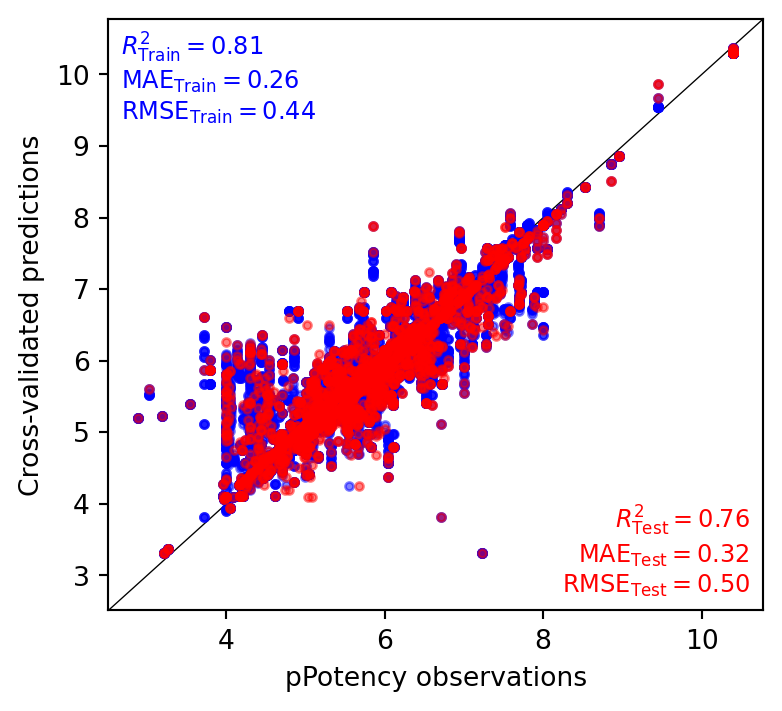

In [17]:
# --- Data ---
Y = EbolaVirusData_allDB["pPotency"]
smiles = EbolaVirusData_allDB["Canonical_SMILES"]

# CV partitions
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mcw = MACAW(
    type_fp="atompairs", metric="sokal",
    n_components=macawNComponents, n_landmarks=macawNLandmarks, random_state=42
)

param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

# Clean NaNs in target
valid = Y.notna()
smiles = smiles[valid].reset_index(drop=True)
Y = Y[valid].reset_index(drop=True)

print(f"Model training with: {len(smiles)} instances")

def process_fold(fold_id, train_idx, test_idx):
    smi_train, smi_test = smiles.iloc[train_idx], smiles.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx].values, Y.iloc[test_idx].values

    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)

    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)

    pred_train = grid.predict(X_train)
    pred_test  = grid.predict(X_test)

    return pred_train, y_train, pred_test, y_test, grid.best_params_

folds = list(kf.split(smiles))

results = Parallel(n_jobs=4)(
    delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
)

# Concatenate CV predictions
Y_pred_train = np.concatenate([r[0] for r in results])
Y_obs_train  = np.concatenate([r[1] for r in results])
Y_pred_test  = np.concatenate([r[2] for r in results])
Y_obs_test   = np.concatenate([r[3] for r in results])

best_params_per_fold = [r[4] for r in results]

# --- Metrics ---
def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred),
    )

train_mae, train_rmse, train_r2 = metrics(Y_obs_train, Y_pred_train)
test_mae,  test_rmse,  test_r2  = metrics(Y_obs_test,  Y_pred_test)

print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)
print(f"Train: MAE {train_mae:.2f} | RMSE {train_rmse:.2f} | R² {train_r2:.2f}")
print(f"Test:  MAE {test_mae:.2f} | RMSE {test_rmse:.2f} | R² {test_r2:.2f}")

parity_plot(
    x=Y_obs_train, y=Y_pred_train,
    x_test=Y_obs_test, y_test=Y_pred_test,
    xlabel="pPotency observations",
    ylabel="Cross-validated predictions",
    savetitle=resultsDir + "combinedEbolaVirus_allDB_CV_wMACAW.svg",
    save_formats=["svg", "png"],
)

### Create `MACAW` embeedings with `best parameters`to run `ART`

In [18]:
# Fit MACAW on SMILES and pPotency
mcw.fit(EbolaVirusData_allDB['Canonical_SMILES'], EbolaVirusData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(EbolaVirusData_allDB['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=EbolaVirusData_allDB.index)


# Add new MACAW columns to existing data frame 
EbolaVirusData_allDB_wMACAW = pd.concat([EbolaVirusData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {EbolaVirusData_allDB.shape}")
print(f"New dataframe shape: {EbolaVirusData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
EbolaVirusData_allDB_wMACAW.to_csv(os.path.join(resultsDir, "EbolaVirusData_allDB_wMACAW.csv"), index=False)
EbolaVirusData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (2704, 60)

Original dataframe shape: (2704, 4)
New dataframe shape: (2704, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW

,compound_id,Canonical_SMILES,pPotency,StrainClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,-0.164434,0.058899,-0.194485,0.231054,-0.141605,0.052492,...,-0.002104,0.011350,0.014281,-0.000237,0.056139,-0.013185,0.049325,0.029934,0.032952,0.017236
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,-0.164434,0.058899,-0.194485,0.231054,-0.141605,0.052492,...,-0.002104,0.011350,0.014281,-0.000237,0.056139,-0.013185,0.049325,0.029934,0.032952,0.017236
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,-0.154220,0.059115,-0.160091,0.213629,-0.145294,0.044615,...,-0.011945,-0.031756,0.002150,-0.026499,0.041905,-0.012766,0.039231,-0.026055,0.026574,-0.004416
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,-0.154220,0.059115,-0.160091,0.213629,-0.145294,0.044615,...,-0.011945,-0.031756,0.002150,-0.026499,0.041905,-0.012766,0.039231,-0.026055,0.026574,-0.004416
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,-0.173578,0.055245,-0.184186,0.235941,-0.141759,0.043349,...,-0.002848,0.012575,0.019814,-0.009299,0.043783,0.006175,0.053311,0.016172,0.012329,0.007963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,0.009356,-0.015573,0.071117,0.035188,-0.033923,-0.163456,...,0.015138,0.025627,0.008600,0.015239,0.015771,-0.021556,0.044617,0.014419,0.021939,-0.024397
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,0.009356,-0.015573,0.071117,0.035188,-0.033923,-0.163456,...,0.015138,0.025627,0.008600,0.015239,0.015771,-0.021556,0.044617,0.014419,0.021939,-0.024397
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,-0.041066,-0.000075,0.074335,0.045519,-0.016864,-0.146985,...,-0.052718,-0.036118,0.021584,-0.009251,0.047634,-0.001857,-0.058521,-0.005955,-0.002667,0.029287
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,-0.041066,-0.000075,0.074335,0.045519,-0.016864,-0.146985,...,-0.052718,-0.036118,0.021584,-0.009251,0.047634,-0.001857,-0.058521,-0.005955,-0.002667,0.029287


## 2.2 Compute `ChemBERTa/MoLFormer/MIST` embeddings

In [19]:
smilesCol = "Canonical_SMILES"
targetCol = "pPotency"
idCol = "compound_id"
strainCol = "StrainClassifier"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


### Define helper functions

In [20]:
def meanPoolTokenEmbeddings(tokenEmbeddings, attentionMask):
    mask = attentionMask.unsqueeze(-1).expand_as(tokenEmbeddings).float()
    return (tokenEmbeddings * mask).sum(dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


def firstTokenPoolTokenEmbeddings(tokenEmbeddings):
    return tokenEmbeddings[:, 0, :]


def extractTokenEmbeddings(outputs):
    if getattr(outputs, "last_hidden_state", None) is not None:
        return outputs.last_hidden_state
    if isinstance(outputs, tuple) and len(outputs) > 0:
        return outputs[0]
    if getattr(outputs, "hidden_states", None) is not None:
        return outputs.hidden_states[-1]
    raise RuntimeError("Cannot extract token embeddings from model output.")


def loadTokenizer(modelName, trustRemoteCode=False, useMistFallback=False, localFilesOnly=True):
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            modelName,
            trust_remote_code=trustRemoteCode,
            local_files_only=localFilesOnly,
        )
    except Exception as err:
        if not useMistFallback:
            raise err

        print("AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.")
        print(f"Original tokenizer error: {err}")

        from smirk import SmirkTokenizerFast

        try:
            tokenizer = SmirkTokenizerFast.from_pretrained(
                modelName,
                local_files_only=localFilesOnly,
            )
        except TypeError:
            tokenizer = SmirkTokenizerFast.from_pretrained(modelName)

    if tokenizer.pad_token is None:
        for attr in ["eos_token", "cls_token", "sep_token", "unk_token"]:
            token = getattr(tokenizer, attr, None)
            if token is not None:
                tokenizer.pad_token = token
                break

    if tokenizer.pad_token is None:
        raise ValueError(f"No pad token found for tokenizer: {modelName}")

    return tokenizer


def runModelForward(model, encoded):
    try:
        return model(**encoded)
    except TypeError as err:
        if "token_type_ids" in str(err) and "token_type_ids" in encoded:
            encoded = {k: v for k, v in encoded.items() if k != "token_type_ids"}
            return model(**encoded)
        raise err


def embedSmilesToArray(
    validSmilesList,
    tokenizer,
    model,
    poolingFn,
    device,
    batchSize,
    maxLength,
    dtype=np.float32,
):
    allEmbeddings = []

    with torch.inference_mode():
        for startIdx in tqdm(range(0, len(validSmilesList), batchSize)):
            batchSmiles = validSmilesList[startIdx:startIdx + batchSize]

            encoded = tokenizer(
                batchSmiles,
                padding=True,
                truncation=True,
                max_length=maxLength,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = runModelForward(model, encoded)
            tokenEmbeddings = extractTokenEmbeddings(outputs)

            if poolingFn == meanPoolTokenEmbeddings:
                pooled = poolingFn(tokenEmbeddings, encoded["attention_mask"])
            else:
                pooled = poolingFn(tokenEmbeddings)

            allEmbeddings.append(pooled.detach().cpu().numpy().astype(dtype))

    return np.vstack(allEmbeddings)


def smilesToEmbeddings(
    DF,
    modelName,
    featurePrefix,
    smilesCol="Canonical_SMILES",
    pooling="mean",
    batchSize=64,
    maxLength=512,
    trustRemoteCode=False,
    useMistFallback=False,
    featureIndexFmt="{prefix}_{i}",
    keepCleanSmiles=False,
    dtype=np.float32,
    device=None,
    localFilesOnly=True,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    poolingFnDict = {
        "mean": meanPoolTokenEmbeddings,
        "cls": firstTokenPoolTokenEmbeddings,
    }

    if pooling not in poolingFnDict:
        raise ValueError(f"pooling must be 'mean' or 'cls', got: {pooling}")

    if localFilesOnly and not os.path.exists(modelName):
        raise FileNotFoundError(f"Local model folder not found:\n{modelName}")

    outDF = DF.copy()
    cleanSmilesCol = f"{smilesCol}_clean"
    outDF[cleanSmilesCol] = outDF[smilesCol].apply(canonicalizeSmiles)

    validMask = outDF[cleanSmilesCol].notna()
    validSmilesList = outDF.loc[validMask, cleanSmilesCol].astype(str).tolist()

    print(f"Model           : {modelName}")
    print(f"Feature prefix  : {featurePrefix} | Pooling: {pooling}")
    print(f"Total / valid / invalid: {len(outDF)} / {len(validSmilesList)} / {(~validMask).sum()}")
    print(f"Device: {device} | Batch size: {batchSize} | Max length: {maxLength}")
    print(f"Local files only: {localFilesOnly}")

    if not validSmilesList:
        raise ValueError("No valid SMILES found.")

    tokenizer = loadTokenizer(
        modelName,
        trustRemoteCode=trustRemoteCode,
        useMistFallback=useMistFallback,
        localFilesOnly=localFilesOnly,
    )

    model = AutoModel.from_pretrained(
        modelName,
        trust_remote_code=trustRemoteCode,
        local_files_only=localFilesOnly,
    ).to(device).eval()

    embeddingArrayValid = embedSmilesToArray(
        validSmilesList,
        tokenizer,
        model,
        poolingFnDict[pooling],
        device,
        batchSize,
        maxLength,
        dtype,
    )

    nFeatures = embeddingArrayValid.shape[1]
    featureCols = [
        featureIndexFmt.format(prefix=featurePrefix, i=i)
        for i in range(nFeatures)
    ]

    embeddingArrayAll = np.full((len(outDF), nFeatures), np.nan, dtype=dtype)
    embeddingArrayAll[validMask.values] = embeddingArrayValid

    embeddingDF = pd.DataFrame(
        embeddingArrayAll,
        columns=featureCols,
        index=outDF.index,
    )

    outDF = pd.concat([outDF, embeddingDF], axis=1)

    if not keepCleanSmiles:
        outDF = outDF.drop(columns=[cleanSmilesCol])

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outDF, featureCols

In [21]:
localModelDict = {
    "ChemBERTa_zinc_base": os.path.join(HuggingFaceModelsDir, "ChemBERTa_zinc_base"),
    "MoLFormer_XL": os.path.join(HuggingFaceModelsDir, "MoLFormer_XL_both_10pct"),
    "MIST_28M": os.path.join(HuggingFaceModelsDir, "MIST_28M"),
}

for modelKey, modelPath in localModelDict.items():
    if os.path.exists(modelPath):
        print(f"Found:   {modelKey} -> {modelPath}")
    else:
        print(f"Missing: {modelKey} -> {modelPath}")

Found:   ChemBERTa_zinc_base -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/ChemBERTa_zinc_base
Found:   MoLFormer_XL -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MoLFormer_XL_both_10pct
Found:   MIST_28M -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MIST_28M


### Generate `ChemBERTa` embeddings

In [22]:
chemBertaModelPath = localModelDict["ChemBERTa_zinc_base"]

EbolaVirusData_allDB_wChemBERTa, chemBertaFeatureCols = smilesToEmbeddings(
    DF              = EbolaVirusData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = chemBertaModelPath,
    featurePrefix   = "ChemBERTa",
    pooling         = "mean",
    batchSize       = 64,
    maxLength       = 256,
    trustRemoteCode = False,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

chemBertaOutputFile = resultsDir + "EbolaVirusData_allDB_wChemBERTa.csv"
EbolaVirusData_allDB_wChemBERTa.to_csv(chemBertaOutputFile, index=False)

print(f"Saved: {chemBertaOutputFile}  |  ChemBERTa feature count: {len(chemBertaFeatureCols)}")
EbolaVirusData_allDB_wChemBERTa.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/ChemBERTa_zinc_base
Feature prefix  : ChemBERTa | Pooling: mean
Total / valid / invalid: 2704 / 2704 / 0
Device: cpu | Batch size: 64 | Max length: 256
Local files only: True


  0%|          | 0/43 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_wChemBERTa.csv  |  ChemBERTa feature count: 768


,compound_id,Canonical_SMILES,pPotency,StrainClassifier,ChemBERTa_0,ChemBERTa_1,ChemBERTa_2,ChemBERTa_3,ChemBERTa_4,ChemBERTa_5,...,ChemBERTa_758,ChemBERTa_759,ChemBERTa_760,ChemBERTa_761,ChemBERTa_762,ChemBERTa_763,ChemBERTa_764,ChemBERTa_765,ChemBERTa_766,ChemBERTa_767
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,0.316940,0.489562,0.482476,-0.420530,-0.114617,-0.349872,...,-0.374723,0.334282,0.183973,-0.811278,-0.207968,0.118253,-0.192927,-0.118759,-0.021240,-0.121672
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,0.387283,0.484221,0.526161,-0.500852,-0.071643,-0.333776,...,-0.373100,0.286691,0.203523,-0.805880,-0.201773,0.174176,-0.159856,-0.078252,-0.035769,-0.100217
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,0.665996,0.395122,0.636223,-0.654288,0.054918,-0.266940,...,-0.453817,0.107224,0.392276,-0.692822,-0.211482,0.019600,-0.360839,-0.087237,-0.287110,0.103901
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,0.665996,0.395122,0.636223,-0.654288,0.054918,-0.266940,...,-0.453817,0.107224,0.392276,-0.692822,-0.211482,0.019600,-0.360839,-0.087237,-0.287110,0.103901
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,0.367225,0.482722,0.535558,-0.470061,-0.118901,-0.314902,...,-0.389007,0.242806,0.239948,-0.793799,-0.219330,0.160506,-0.121072,-0.124412,-0.031190,-0.078593


### Generate `MoLFormer` embeddings

In [23]:
molFormerModelPath = localModelDict["MoLFormer_XL"]

EbolaVirusData_allDB_wMoLFormer, molFormerFeatureCols = smilesToEmbeddings(
    DF              = EbolaVirusData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = molFormerModelPath,
    featurePrefix   = "MoLFormer",
    pooling         = "mean",
    batchSize       = 32,
    maxLength       = 202,
    trustRemoteCode = True,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

molFormerOutputFile = resultsDir + "EbolaVirusData_allDB_wMoLFormer.csv"
EbolaVirusData_allDB_wMoLFormer.to_csv(molFormerOutputFile, index=False)

print(f"Saved: {molFormerOutputFile}  |  MoLFormer feature count: {len(molFormerFeatureCols)}")
EbolaVirusData_allDB_wMoLFormer.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MoLFormer_XL_both_10pct
Feature prefix  : MoLFormer | Pooling: mean
Total / valid / invalid: 2704 / 2704 / 0
Device: cpu | Batch size: 32 | Max length: 202
Local files only: True


  0%|          | 0/85 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_wMoLFormer.csv  |  MoLFormer feature count: 768


,compound_id,Canonical_SMILES,pPotency,StrainClassifier,MoLFormer_0,MoLFormer_1,MoLFormer_2,MoLFormer_3,MoLFormer_4,MoLFormer_5,...,MoLFormer_758,MoLFormer_759,MoLFormer_760,MoLFormer_761,MoLFormer_762,MoLFormer_763,MoLFormer_764,MoLFormer_765,MoLFormer_766,MoLFormer_767
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,0.620432,0.383493,-0.152123,0.441740,-1.084066,-0.328487,...,-0.510143,-0.192172,0.388542,0.493769,-0.197707,-0.107083,-2.917970,0.179504,-0.446869,-0.131765
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,0.663147,0.334585,-0.181470,0.489837,-1.060945,-0.378584,...,-0.514648,-0.199531,0.363420,0.439495,-0.274447,-0.125021,-2.938753,0.142389,-0.424234,-0.143943
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,0.485422,0.405491,0.162565,0.546002,-1.264227,-0.114922,...,-0.214602,-0.219645,0.408879,0.270941,-0.127312,-0.035224,-2.838430,-0.215528,-0.366369,-0.169192
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,0.485422,0.405491,0.162565,0.546002,-1.264227,-0.114922,...,-0.214602,-0.219645,0.408879,0.270941,-0.127312,-0.035224,-2.838430,-0.215528,-0.366369,-0.169192
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,0.540595,0.370876,-0.186437,0.419776,-1.079576,-0.390496,...,-0.493850,-0.203408,0.260512,0.473979,-0.236497,-0.158160,-2.980453,0.084973,-0.292107,-0.045252


### Generate `MIST-28M parameter` embeddings

In [24]:
mistModelPath = localModelDict["MIST_28M"]

EbolaVirusData_allDB_wMIST, mistFeatureCols = smilesToEmbeddings(
    DF              = EbolaVirusData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = mistModelPath,
    featurePrefix   = "MIST",
    pooling         = "cls",
    batchSize       = 64,
    maxLength       = 2048,
    trustRemoteCode = True,
    useMistFallback = True,
    featureIndexFmt = "{prefix}_{i:04d}",
    localFilesOnly  = True,
    device          = device,
)

mistOutputFile = resultsDir + "EbolaVirusData_allDB_wMIST.csv"
EbolaVirusData_allDB_wMIST.to_csv(mistOutputFile, index=False)

print(f"Saved: {mistOutputFile}  |  MIST feature count: {len(mistFeatureCols)}")
EbolaVirusData_allDB_wMIST.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MIST_28M
Feature prefix  : MIST | Pooling: cls
Total / valid / invalid: 2704 / 2704 / 0
Device: cpu | Batch size: 64 | Max length: 2048
Local files only: True
AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.
Original tokenizer error: Tokenizer class SmirkTokenizerFast does not exist or is not currently imported.


  0%|          | 0/43 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_wMIST.csv  |  MIST feature count: 512


,compound_id,Canonical_SMILES,pPotency,StrainClassifier,MIST_0000,MIST_0001,MIST_0002,MIST_0003,MIST_0004,MIST_0005,...,MIST_0502,MIST_0503,MIST_0504,MIST_0505,MIST_0506,MIST_0507,MIST_0508,MIST_0509,MIST_0510,MIST_0511
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,2.094044,1.040824,0.663600,-0.552805,1.858448,0.017446,...,0.481038,0.512447,-1.298337,1.133178,0.733838,0.248807,-0.278274,1.330179,-0.704992,0.684902
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,2.021761,1.066552,0.693618,-0.579799,1.819009,0.012585,...,0.529007,0.539942,-1.303200,1.133012,0.674390,0.238593,-0.219470,1.322445,-0.669361,0.721682
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,1.921722,1.152736,0.677800,-0.449963,1.791586,0.066850,...,0.564328,0.411658,-1.284727,1.031397,0.766456,0.553722,-0.388847,1.238097,-0.553582,0.512289
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,1.921722,1.152736,0.677800,-0.449963,1.791586,0.066850,...,0.564328,0.411658,-1.284727,1.031397,0.766456,0.553722,-0.388847,1.238097,-0.553582,0.512289
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,2.017720,1.068052,0.691986,-0.574825,1.825758,0.013114,...,0.536269,0.536316,-1.296279,1.139665,0.679063,0.237407,-0.222001,1.316225,-0.668936,0.722905


### Create optimized embeedings from `chemical foundation models` with `best parameters`to train `ART`

In [25]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    EbolaVirusData_allDB[smilesCol].notna()
    & EbolaVirusData_allDB[targetCol].notna()
)

baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier"]
    if c in EbolaVirusData_allDB.columns
]

baseDF = EbolaVirusData_allDB.loc[validMask, baseCols].reset_index(drop=True)

# Column prefix registry 
# Maps embedding name → (source dataframe, column prefix in that dataframe)
EMBEDDING_REGISTRY = {
    "chemberta" : (EbolaVirusData_allDB_wChemBERTa, "ChemBERTa_"),
    "molformer" : (EbolaVirusData_allDB_wMoLFormer,  "MoLFormer_"),
    "mist"      : (EbolaVirusData_allDB_wMIST,       "MIST_"),
}

def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol):
    """
    Concatenate embeddings for the given list of embedding names,
    rename all feature columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel).
    """
    featureBlocks        = []
    originalFeatureCols  = []
    featureCountByModel  = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]

        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")

        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    embeddingDF     = pd.concat(featureBlocks, axis=1)
    artFeatureCols  = [f"ARTfeat_{i+1}" for i in range(embeddingDF.shape[1])]
    embeddingDF.columns = artFeatureCols

    combinedDF = (
        pd.concat([baseDF.reset_index(drop=True),
                   embeddingDF.reset_index(drop=True)], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel


# Generate every non-empty subset of the three embeddings 
allEmbeddings   = ["chemberta", "molformer", "mist"]
savedFiles      = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol)
        )

        outCsv = os.path.join(
            resultsDir,
            f"EbolaVirusData_allDB_w{choiceName}_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        info = {
            "embeddingChoice"          : choiceName,
            "inputFeatureColumnPrefix" : "ARTfeat_",
            "artFeatureCols"           : artFeatureCols,
            "originalFeatureCols"      : originalFeatureCols,
            "featureCountByModel"      : featureCountByModel,
            "totalFeatureCount"        : len(artFeatureCols),
            "artReadyCsv"              : outCsv,
        }

        infoJson = os.path.join(
            resultsDir,
            f"EbolaVirusData_allDB_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))


print(f"{'File':<75}  {'Shape':>15}")
print("─" * 92)
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")

File                                                                                   Shape
────────────────────────────────────────────────────────────────────────────────────────────
EbolaVirusData_allDB_wchemberta_ARTready.csv                                     (2704, 772)
EbolaVirusData_allDB_wmolformer_ARTready.csv                                     (2704, 772)
EbolaVirusData_allDB_wmist_ARTready.csv                                          (2704, 516)
EbolaVirusData_allDB_wchemberta_molformer_ARTready.csv                          (2704, 1540)
EbolaVirusData_allDB_wchemberta_mist_ARTready.csv                               (2704, 1284)
EbolaVirusData_allDB_wmolformer_mist_ARTready.csv                               (2704, 1284)
EbolaVirusData_allDB_wchemberta_molformer_mist_ARTready.csv                     (2704, 2052)


### Cross-validation comparison:
   1. MACAW only
   2. ChemBERTa only
   3. MoLFormer only
   4. MIST only
   5. mix models (MACAW + ChemBERTa + MoLFormer + MIST)

MACAW parameters: {'type_fp': 'atompairs', 'metric': 'sokal', 'n_components': 60, 'n_landmarks': 1000, 'random_state': 42}

Loaded ART-ready files
--------------------------------------------------------------------------------------------------------------
chemberta                           molecules=2704     features=768      file=combinedEbolaVirusData_allDB_wchemberta_ARTready.csv
molformer                           molecules=2704     features=768      file=combinedEbolaVirusData_allDB_wmolformer_ARTready.csv
mist                                molecules=2704     features=512      file=combinedEbolaVirusData_allDB_wmist_ARTready.csv
chemberta_molformer                 molecules=2704     features=1536     file=combinedEbolaVirusData_allDB_wchemberta_molformer_ARTready.csv
chemberta_mist                      molecules=2704     features=1280     file=combinedEbolaVirusData_allDB_wchemberta_mist_ARTready.csv
molformer_mist                      molecules=2704     features=1280     file

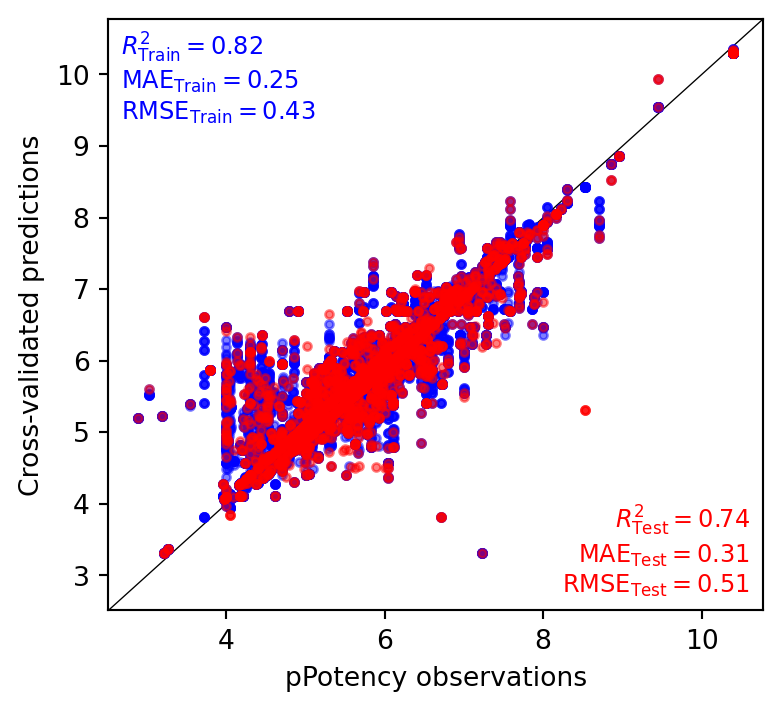


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wChemBERTa
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 768
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wChemBERTa
Train: MAE 0.26 | RMSE 0.43 | R² 0.82
Test:  MAE 0.33 | RMSE 0.53 | R² 0.73
Feature count per fold: [768]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa.png


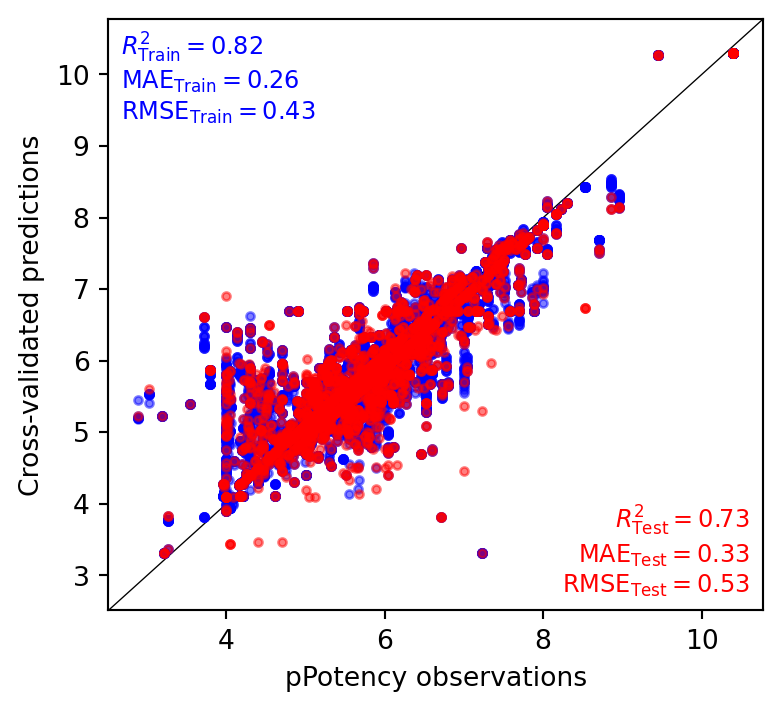


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMoLFormer
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 768
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wMoLFormer
Train: MAE 0.13 | RMSE 0.24 | R² 0.95
Test:  MAE 0.31 | RMSE 0.48 | R² 0.78
Feature count per fold: [768]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMoLFormer.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMoLFormer.png


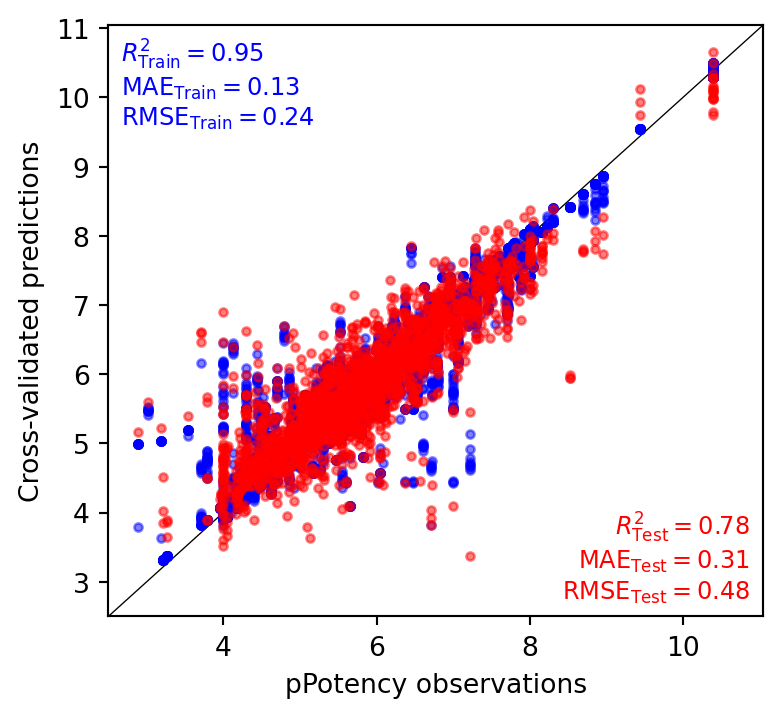


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 512
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wMIST
Train: MAE 0.27 | RMSE 0.44 | R² 0.81
Test:  MAE 0.33 | RMSE 0.53 | R² 0.72
Feature count per fold: [512]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMIST.png


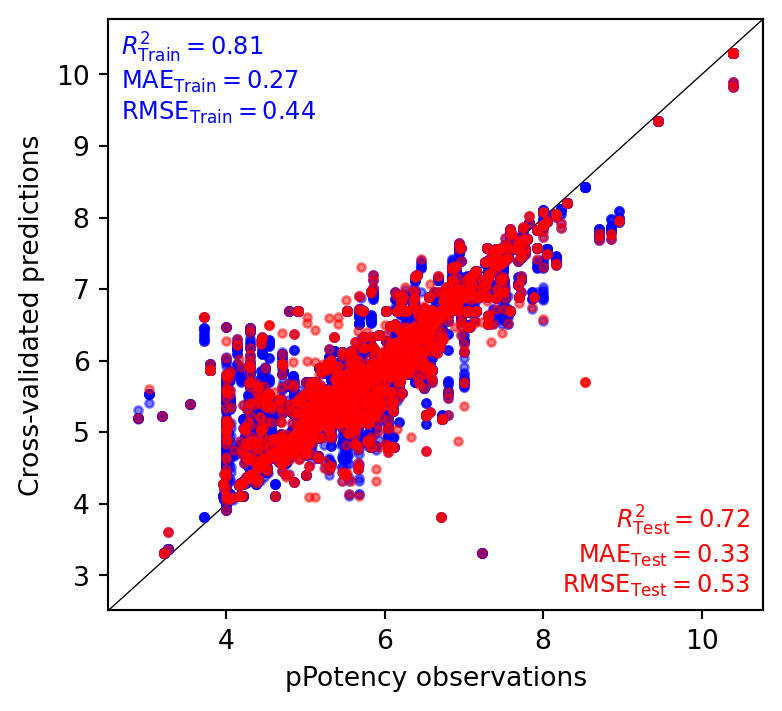


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wChemBERTa_MoLFormer
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1536
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wChemBERTa_MoLFormer
Train: MAE 0.14 | RMSE 0.25 | R² 0.94
Test:  MAE 0.30 | RMSE 0.46 | R² 0.79
Feature count per fold: [1536]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MoLFormer.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MoLFormer.png


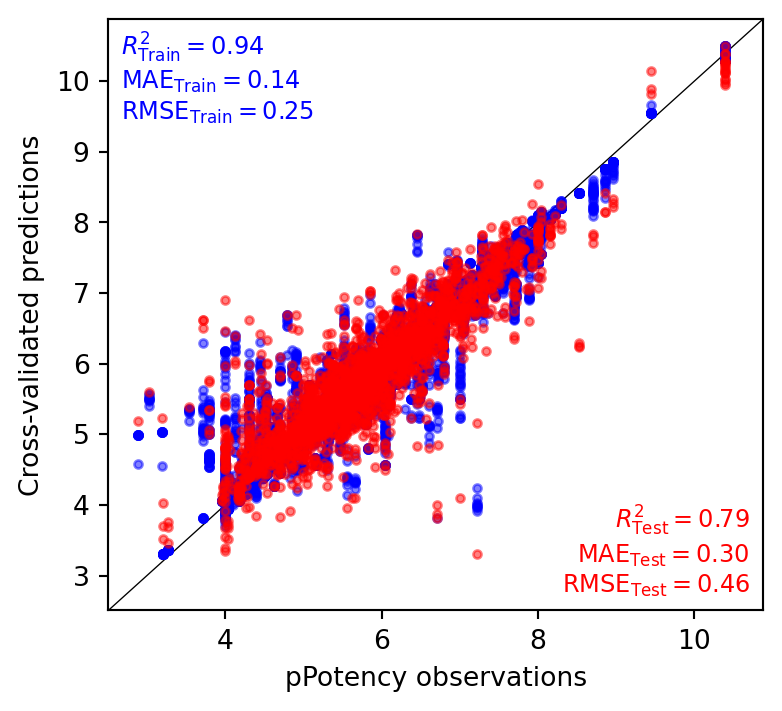


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wChemBERTa_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1280
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wChemBERTa_MIST
Train: MAE 0.25 | RMSE 0.42 | R² 0.83
Test:  MAE 0.32 | RMSE 0.52 | R² 0.73
Feature count per fold: [1280]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MIST.png


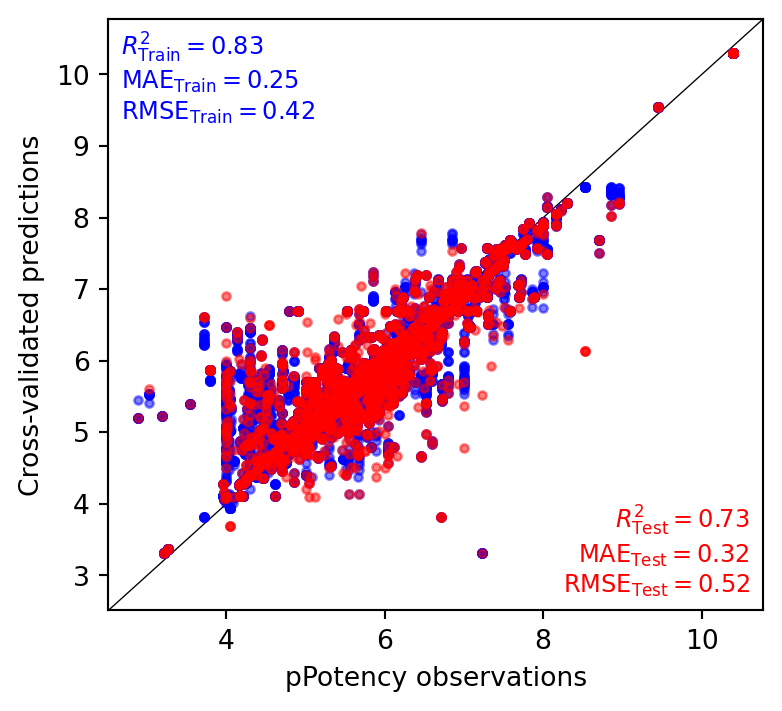


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMoLFormer_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1280
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wMoLFormer_MIST
Train: MAE 0.14 | RMSE 0.25 | R² 0.94
Test:  MAE 0.30 | RMSE 0.46 | R² 0.79
Feature count per fold: [1280]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMoLFormer_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMoLFormer_MIST.png


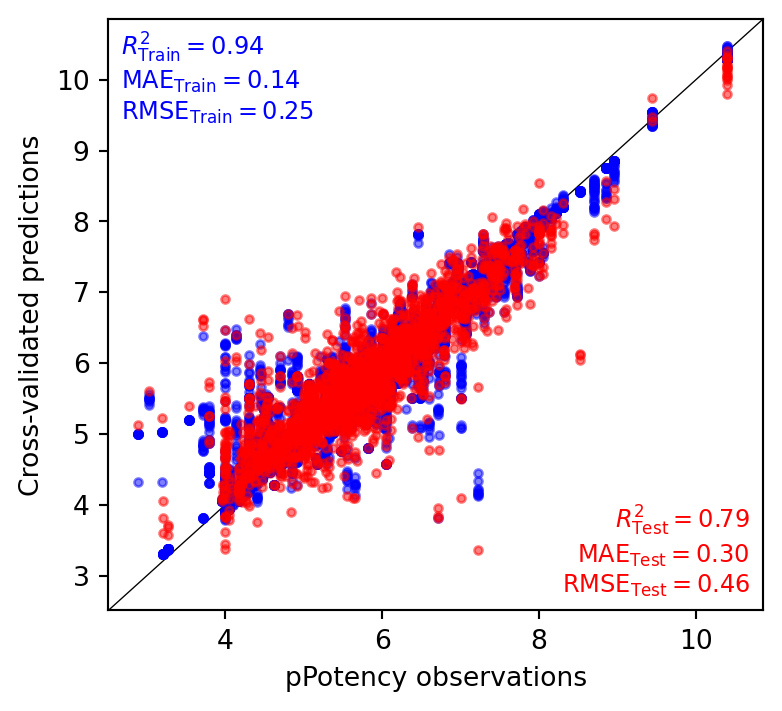


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wChemBERTa_MoLFormer_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 2048
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wChemBERTa_MoLFormer_MIST
Train: MAE 0.15 | RMSE 0.27 | R² 0.93
Test:  MAE 0.29 | RMSE 0.46 | R² 0.80
Feature count per fold: [2048]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MoLFormer_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wChemBERTa_MoLFormer_MIST.png


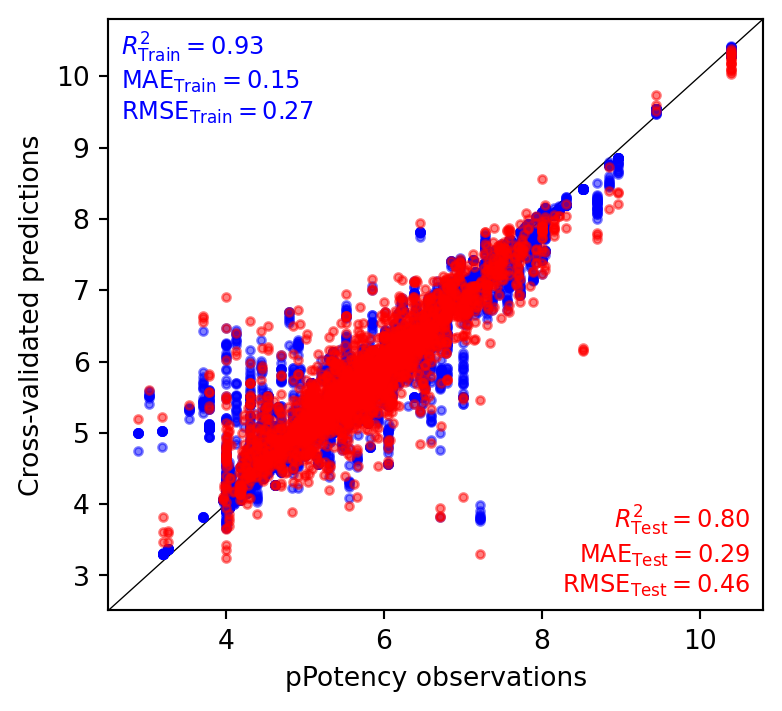


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_ChemBERTa
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 768
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_ChemBERTa
Train: MAE 0.25 | RMSE 0.42 | R² 0.83
Test:  MAE 0.32 | RMSE 0.52 | R² 0.74
Feature count per fold: [828]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa.png


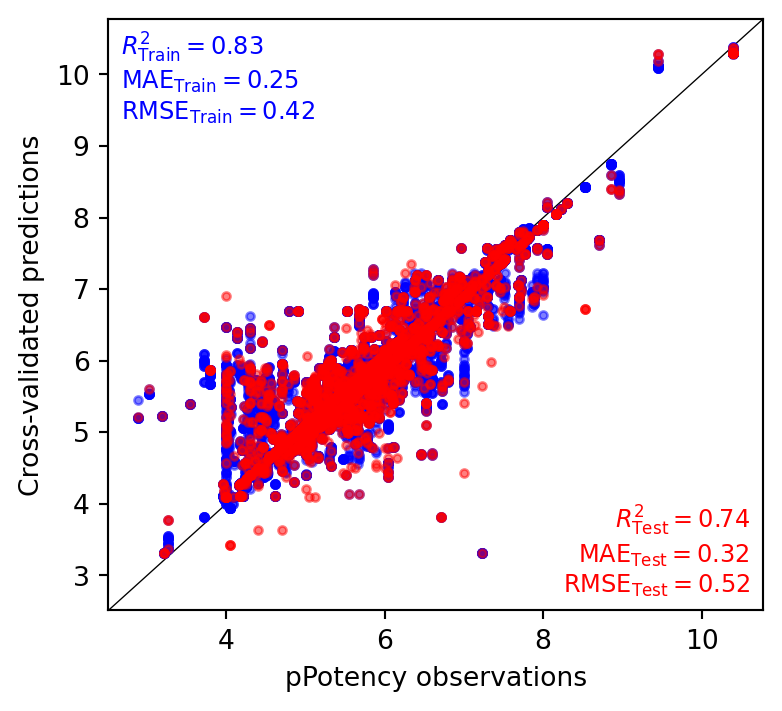


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_MoLFormer
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 768
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_MoLFormer
Train: MAE 0.13 | RMSE 0.23 | R² 0.95
Test:  MAE 0.31 | RMSE 0.47 | R² 0.79
Feature count per fold: [828]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MoLFormer.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MoLFormer.png


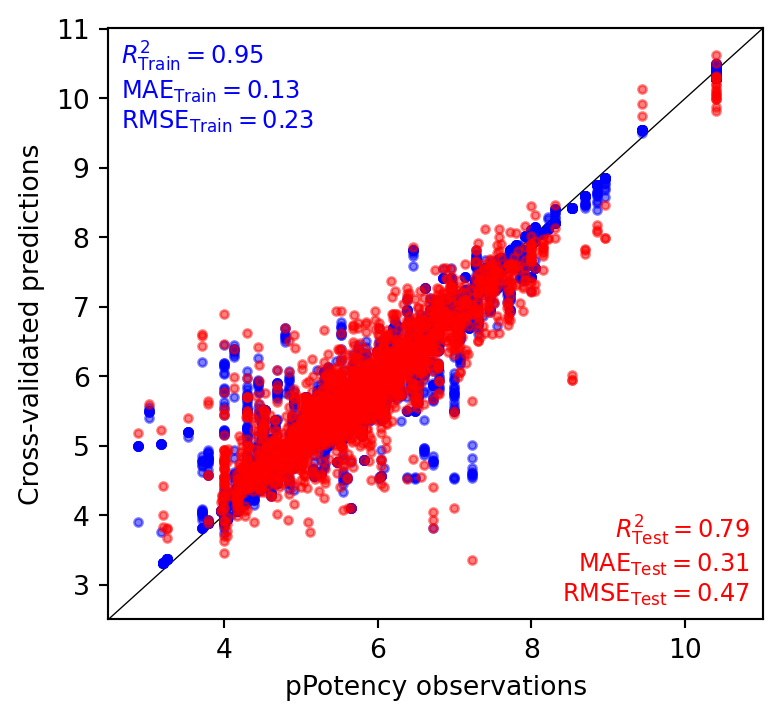


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 512
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_MIST
Train: MAE 0.25 | RMSE 0.42 | R² 0.83
Test:  MAE 0.32 | RMSE 0.52 | R² 0.74
Feature count per fold: [572]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MIST.png


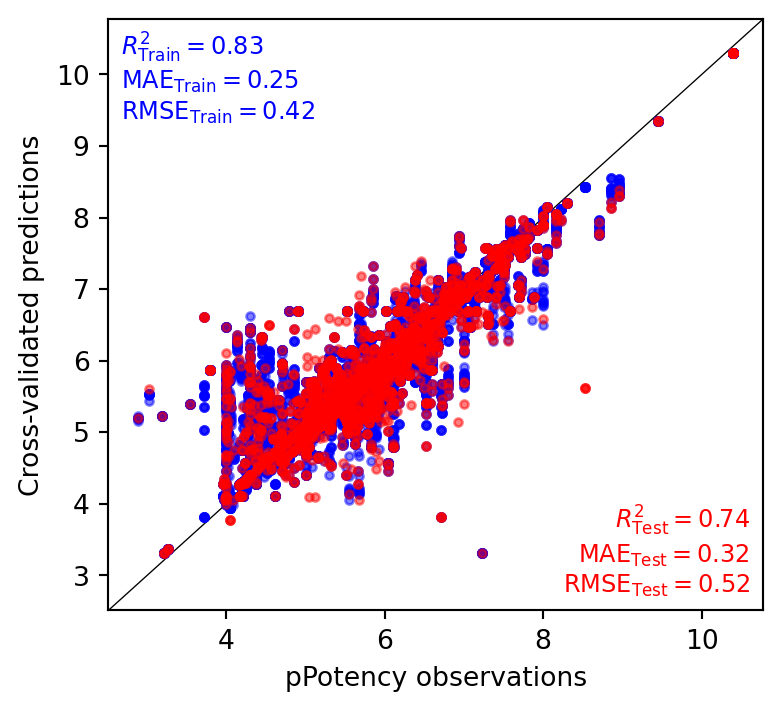


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_ChemBERTa_MoLFormer
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1536
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_ChemBERTa_MoLFormer
Train: MAE 0.14 | RMSE 0.25 | R² 0.94
Test:  MAE 0.29 | RMSE 0.46 | R² 0.80
Feature count per fold: [1596]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MoLFormer.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MoLFormer.png


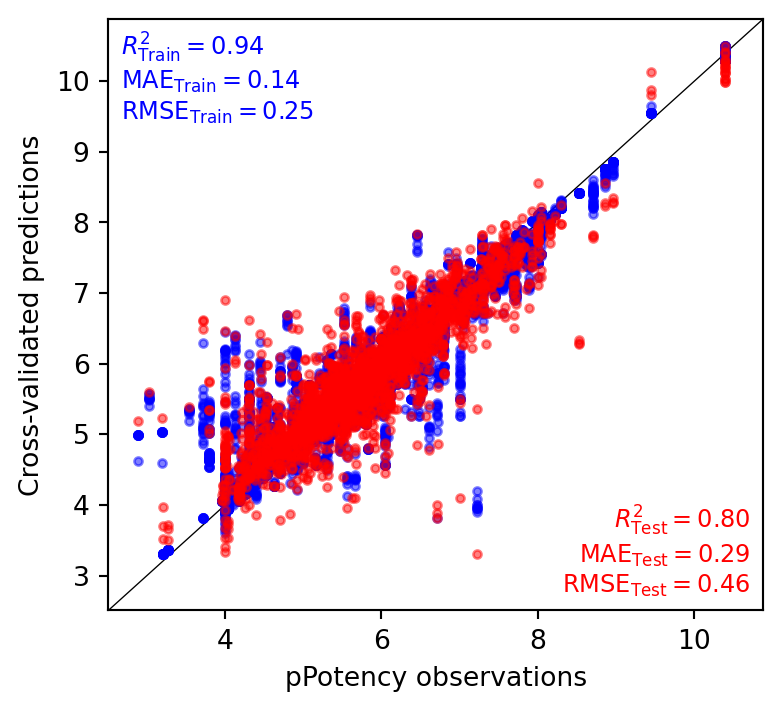


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_ChemBERTa_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1280
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_ChemBERTa_MIST
Train: MAE 0.24 | RMSE 0.42 | R² 0.83
Test:  MAE 0.31 | RMSE 0.52 | R² 0.74
Feature count per fold: [1340]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MIST.png


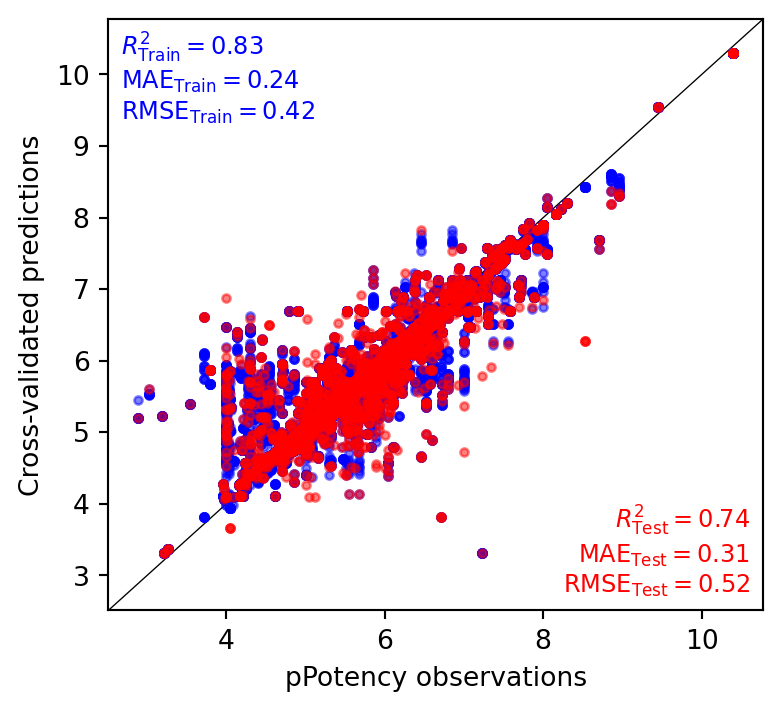


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_MoLFormer_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 1280
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_MoLFormer_MIST
Train: MAE 0.14 | RMSE 0.25 | R² 0.94
Test:  MAE 0.29 | RMSE 0.46 | R² 0.80
Feature count per fold: [1340]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MoLFormer_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_MoLFormer_MIST.png


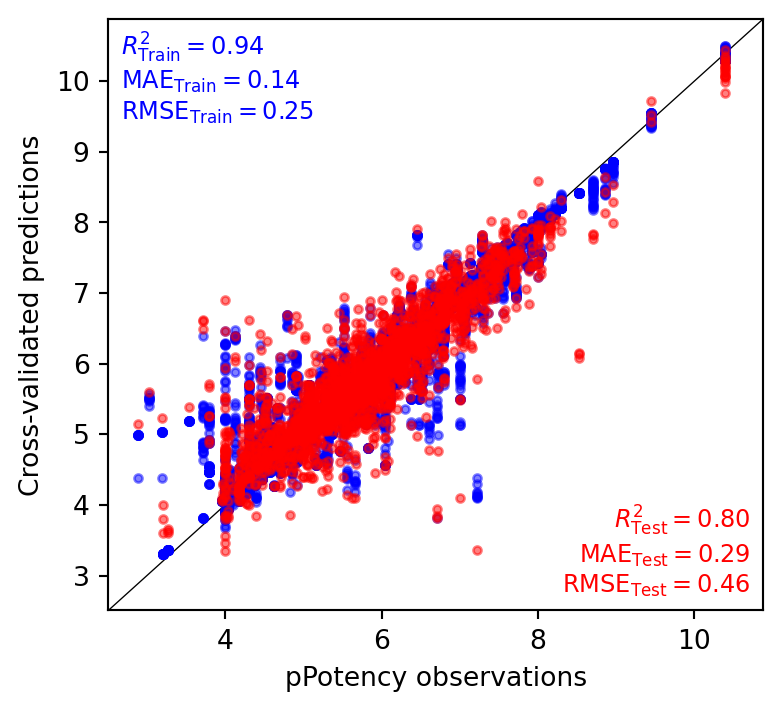


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_ChemBERTa_MoLFormer_MIST
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 2048
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_ChemBERTa_MoLFormer_MIST
Train: MAE 0.15 | RMSE 0.27 | R² 0.93
Test:  MAE 0.29 | RMSE 0.46 | R² 0.80
Feature count per fold: [2108]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MoLFormer_MIST.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa_MoLFormer_MIST.png


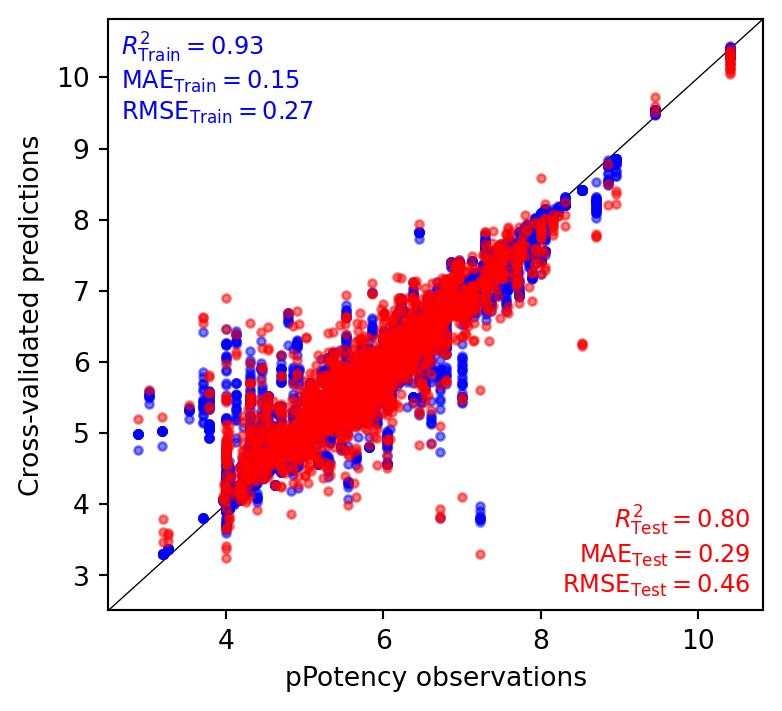

Saved ranked summary: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_SVR_MACAW_ARTready_comparison_ranked.csv


In [26]:
smilesCol        = "Canonical_SMILES"
targetCol        = "pPotency"
nSplits          = 10
outerRandomState = 42
nJobs            = 4
scaleFeatures    = True
useCommonMoleculeSet = True
artFeaturePrefix = "ARTfeat_"

if "param_grid" not in globals():
    param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

macawParams = {
    "type_fp"     : getattr(mcw, "type_fp", "atompairs"),
    "metric"      : getattr(mcw, "metric", "sokal"),
    "n_components": macawNComponents,
    "n_landmarks" : macawNLandmarks,
    "random_state": getattr(mcw, "random_state", 42),
}
print("MACAW parameters:", macawParams)

comparisonPlan = [
    ("wMACAW",                          tuple(),                            True),
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]


def getRegressionMetrics(yTrue, yPred):
    return (mean_absolute_error(yTrue, yPred),
            np.sqrt(mean_squared_error(yTrue, yPred)),
            r2_score(yTrue, yPred))


def standardizeByTrainFold(xTrain, xTest):
    mu, sigma = np.nanmean(xTrain, axis=0), np.nanstd(xTrain, axis=0)
    sigma[sigma == 0] = 1.0
    sigma[~np.isfinite(sigma)] = 1.0
    mu[~np.isfinite(mu)] = 0.0
    return (xTrain - mu) / sigma, (xTest - mu) / sigma


def makeSafeTag(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text))


def choiceToFileStem(choice):
    return "_".join(choice)


def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"combinedEbolaVirusData_allDB_w{choiceName}_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_ARTready.csv")))
    if not matches:
        raise FileNotFoundError(f"ART-ready CSV not found for '{choiceName}'.\nExpected: {expectedPath}")
    return matches[0]


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_ARTready.csv", "_ARTready_featureInfo.json")
    return json.load(open(infoPath)) if os.path.exists(infoPath) else {}


def readARTReadyCSV(choice):
    csvPath        = getARTReadyCsvPath(choice)
    df             = pd.read_csv(csvPath)
    artFeatureCols = [c for c in df.columns if c.startswith(artFeaturePrefix)]
    if not artFeatureCols:
        raise ValueError(f"No '{artFeaturePrefix}*' columns in: {csvPath}")
    neededCols  = [smilesCol, targetCol] + artFeatureCols
    missingCols = [c for c in neededCols if c not in df.columns]
    if missingCols:
        raise ValueError(f"Missing columns in {csvPath}: {missingCols}")
    df[targetCol] = pd.to_numeric(df[targetCol], errors="coerce")
    for col in artFeatureCols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=neededCols).reset_index(drop=True)
    return {"choice": choice, "choiceName": choiceToFileStem(choice), "csvPath": csvPath,
            "DF": df, "featureCols": artFeatureCols, "featureInfo": loadFeatureInfo(csvPath)}


def makeFreshMACAWForFold(nTrain):
    foldNLandmarks  = min(macawParams["n_landmarks"], nTrain)
    foldNComponents = min(macawParams["n_components"], foldNLandmarks - 1)
    if foldNComponents < 2:
        raise ValueError(f"Too few molecules for MACAW: n_train={nTrain}, "
                         f"n_landmarks={foldNLandmarks}, n_components={foldNComponents}")
    return MACAW(type_fp=macawParams["type_fp"], metric=macawParams["metric"],
                 n_components=foldNComponents, n_landmarks=foldNLandmarks,
                 random_state=macawParams["random_state"])


# Load ART-ready files
uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if len(choice) > 0 and choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {choice: readARTReadyCSV(choice) for choice in uniqueARTChoices}

print("\nLoaded ART-ready files")
print("-" * 110)
for choice, item in artInputByChoice.items():
    print(f"{item['choiceName']:<35} molecules={item['DF'].shape[0]:<8} "
          f"features={len(item['featureCols']):<8} file={os.path.basename(item['csvPath'])}")

# Common molecule key
availableKeyCols = [c for c in ["compound_id", smilesCol, "StrainClassifier"]
                    if all(c in item["DF"].columns for item in artInputByChoice.values())] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across ART-ready files.")
    for item in artInputByChoice.values():
        item["DF"] = (item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
                      .sort_values("_cvKey").reset_index(drop=True))
        if item["DF"]["_cvKey"].duplicated().any():
            print(f"Warning: duplicate _cvKey values in {item['choiceName']}.")

# MACAW-only baseline dataframe
referenceChoice = ("chemberta", "molformer", "mist")
referenceDF     = artInputByChoice.get(referenceChoice, list(artInputByChoice.values())[0])["DF"]
baseColsForMacaw = [c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier", "_cvKey"]
                    if c in referenceDF.columns]
macawBaseDF = referenceDF[baseColsForMacaw].copy().reset_index(drop=True)


def runFeatureSetCV(DF, featureCols, useMacaw, modelTag):
    print(f"\n{'─'*90}\nRunning CV: {modelTag}\n{'─'*90}")

    requiredCols = [smilesCol, targetCol] + featureCols
    DF     = DF.replace([np.inf, -np.inf], np.nan).dropna(subset=requiredCols).reset_index(drop=True)
    smiles = DF[smilesCol].reset_index(drop=True)
    Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    if Y.isna().any():
        DF     = DF.loc[Y.notna()].reset_index(drop=True)
        smiles = DF[smilesCol].reset_index(drop=True)
        Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    precomputedX = DF[featureCols].values.astype(np.float32) if featureCols else None

    print(f"Model training with: {len(smiles)} instances")
    print(f"ART/precomputed feature count: {len(featureCols)}")
    print(f"Use MACAW: {useMacaw}")
    print(f"Scale features inside fold: {scaleFeatures}")

    if len(smiles) < nSplits:
        raise ValueError(f"nSplits={nSplits} > n_rows={len(smiles)} for {modelTag}.")
    if not featureCols and not useMacaw:
        raise ValueError(f"{modelTag}: no features and useMacaw=False.")

    folds = list(KFold(n_splits=nSplits, shuffle=True, random_state=outerRandomState).split(smiles))

    def process_fold(fold_id, train_idx, test_idx):
        y_train, y_test = Y.iloc[train_idx].values.astype(float), Y.iloc[test_idx].values.astype(float)
        xTrainBlocks, xTestBlocks = [], []

        if useMacaw:
            smi_train = smiles.iloc[train_idx].reset_index(drop=True).astype(str).tolist()
            smi_test  = smiles.iloc[test_idx].reset_index(drop=True).astype(str).tolist()
            mcw_fold  = makeFreshMACAWForFold(nTrain=len(smi_train))
            mcw_fold.fit(smi_train, y_train)
            xTrainBlocks.append(np.asarray(mcw_fold.transform(smi_train), dtype=np.float32))
            xTestBlocks.append(np.asarray(mcw_fold.transform(smi_test),  dtype=np.float32))

        if precomputedX is not None:
            xTrainBlocks.append(precomputedX[train_idx, :])
            xTestBlocks.append(precomputedX[test_idx,  :])

        X_train, X_test = np.hstack(xTrainBlocks), np.hstack(xTestBlocks)
        if scaleFeatures:
            X_train, X_test = standardizeByTrainFold(X_train, X_test)

        grid = GridSearchCV(SVR(), param_grid=param_grid, cv=5, refit=True, n_jobs=1)
        grid.fit(X_train, y_train)
        return {"fold_id": fold_id, "train_idx": train_idx, "test_idx": test_idx,
                "pred_train": grid.predict(X_train), "y_train": y_train,
                "pred_test": grid.predict(X_test),   "y_test": y_test,
                "best_params": grid.best_params_, "feature_count": X_train.shape[1]}

    results = Parallel(n_jobs=nJobs)(
        delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
    )

    Y_pred_train  = np.concatenate([r["pred_train"] for r in results])
    Y_obs_train   = np.concatenate([r["y_train"]    for r in results])
    Y_pred_test   = np.full(len(Y), np.nan, dtype=float)
    Y_obs_test    = Y.values.astype(float)
    foldIdForRow  = np.full(len(Y), -1, dtype=int)

    for r in results:
        Y_pred_test[r["test_idx"]]  = r["pred_test"]
        foldIdForRow[r["test_idx"]] = r["fold_id"]

    bestParamsPerFold   = [r["best_params"]   for r in results]
    featureCountPerFold = [r["feature_count"] for r in results]

    trainMae, trainRmse, trainR2 = getRegressionMetrics(Y_obs_train, Y_pred_train)
    testMae,  testRmse,  testR2  = getRegressionMetrics(Y_obs_test,  Y_pred_test)

    print(f"Cross Validation Metrics: {modelTag}")
    print(f"Train: MAE {trainMae:.2f} | RMSE {trainRmse:.2f} | R² {trainR2:.2f}")
    print(f"Test:  MAE {testMae:.2f} | RMSE {testRmse:.2f} | R² {testR2:.2f}")
    print("Feature count per fold:", sorted(set(featureCountPerFold)))

    safeTag    = makeSafeTag(modelTag)
    predCols   = [c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier", "_cvKey"] if c in DF.columns]
    predFile   = os.path.join(resultsDir, f"combinedEbolaVirus_allDB_CV_{safeTag}_OOF_predictions.csv")
    plotBase   = os.path.join(resultsDir, f"combinedEbolaVirus_allDB_CV_{safeTag}")

    if "parity_plot" in globals():
        parity_plot(x=Y_obs_train, y=Y_pred_train, x_test=Y_obs_test, y_test=Y_pred_test,
                    xlabel="pPotency observations", ylabel="Cross-validated predictions",
                    savetitle=plotBase + ".svg", save_formats=["svg", "png"])
    else:
        print("parity_plot not found; skipping plot.")

    return {"Model": modelTag, "FeatureCountMin": min(featureCountPerFold),
            "FeatureCountMax": max(featureCountPerFold), "FeatureCountPerFold": featureCountPerFold,
            "Train_MAE": trainMae, "Train_RMSE": trainRmse, "Train_R2": trainR2,
            "Test_MAE": testMae,  "Test_RMSE": testRmse,  "Test_R2": testR2,
            "BestParamsPerFold": bestParamsPerFold, "PredictionFile": predFile,
            "Y_obs_train": Y_obs_train, "Y_pred_train": Y_pred_train,
            "Y_obs_test": Y_obs_test,   "Y_pred_test": Y_pred_test}


# Build and run experiments
featureExperiments = []
for modelTag, choice, useMacaw in comparisonPlan:
    if len(choice) == 0:
        experimentDF, featureCols, featureInfo = macawBaseDF.copy(), [], {}
    else:
        item = artInputByChoice[choice]
        experimentDF, featureCols, featureInfo = item["DF"].copy(), item["featureCols"], item["featureInfo"]
    featureExperiments.append({"modelTag": modelTag, "DF": experimentDF,
                                "featureCols": featureCols, "useMacaw": useMacaw, "featureInfo": featureInfo})

cvResults = []
for exp in featureExperiments:
    result = runFeatureSetCV(DF=exp["DF"], featureCols=exp["featureCols"],
                             useMacaw=exp["useMacaw"], modelTag=exp["modelTag"])
    result["ARTFeatureInfo"] = exp.get("featureInfo", {})
    cvResults.append(result)

# Save ranked summary
cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE": r["Test_MAE"],   "Test_RMSE": r["Test_RMSE"],   "Test_R2": r["Test_R2"],
     "BestParamsPerFold": r["BestParamsPerFold"], "PredictionFile": r["PredictionFile"]}
    for r in cvResults
])

rankedSummaryFile = os.path.join(resultsDir, "combinedEbolaVirus_allDB_CV_SVR_MACAW_ARTready_comparison_ranked.csv")
cvSummaryDF.sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True]).reset_index(drop=True).to_csv(rankedSummaryFile, index=False)
print("Saved ranked summary:", rankedSummaryFile)

### Two-stage dimensionality reduction: `PCA -> UMAP` cascade.
 
Stage 1 - PCA (linear): Handles bulk variance compression.  At `pcaComponents=192`, ChemBERTa's 768-dim space retains ~99% of variance while cutting per-worker memory ~4x.  StandardScaler is applied first so no single embedding dimension dominates the principal components.
 
Stage 2 - UMAP (non-linear, optional): Acts on the PCA output to capture local manifold structure that PCA cannot represent.  For ML downstream tasks umapComponents should be in the range 32-64, min_dist should be 0.0 or small and n_neighbors controls the local/global trade-off (larger = more global structure preserved).  UMAP on the PCA-compressed space converges faster and is more stable than running it directly on the raw 768-dim embeddings.
 
Setting pcaComponents: null skips both stages.
Setting umapComponents: null skips stage 2 only (PCA alone).

In [27]:
PcaUmapConfig = {
    "pcaComponents"  : 192,   # retains ~99% variance for ChemBERTa / MoLFormer
    "umapComponents" : None,    # final dims fed to ART; set to None for PCA only
    "umapNNeighbors" : 15,    # local vs. global structure trade-off (10–30)
    "umapMinDist"    : 0.0,   # 0.0 = tightest clusters; best for ML tasks
    "randomSeed"     : 42,
}

In [28]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    EbolaVirusData_allDB[smilesCol].notna()
    & EbolaVirusData_allDB[targetCol].notna()
)
baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier"]
    if c in EbolaVirusData_allDB.columns
]
baseDF = EbolaVirusData_allDB.loc[validMask, baseCols].reset_index(drop=True)

EMBEDDING_REGISTRY = {
    "chemberta" : (EbolaVirusData_allDB_wChemBERTa, "ChemBERTa_"),
    "molformer" : (EbolaVirusData_allDB_wMoLFormer,  "MoLFormer_"),
    "mist"      : (EbolaVirusData_allDB_wMIST,       "MIST_"),
}


def applyDimReduction(rawFeatures, config):
    """
    PCA -> UMAP cascade on a (n_samples, n_features) numpy array.

    Returns reducedFeatures (np.ndarray) and dimBundle (dict) containing
    the fitted scaler, pca, and umap objects for inference reuse.
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    nSamples, nFeatures = rawFeatures.shape
    meta = {
        "originalDims"        : nFeatures,
        "pcaComponents"       : None,
        "umapComponents"      : None,
        "finalDims"           : nFeatures,
        "explainedVariancePct": None,
    }

    pcaComponents = config.get("pcaComponents")
    if pcaComponents is None:
        print("    [DimReduction] Skipped — pcaComponents not set.")
        return rawFeatures, {"scaler": None, "pca": None, "umap": None, "meta": meta}

    nPcaComponents = min(pcaComponents, nSamples, nFeatures)
    scaler         = StandardScaler()
    scaledFeatures = scaler.fit_transform(rawFeatures)
    pca            = PCA(n_components=nPcaComponents, random_state=config["randomSeed"])
    pcaFeatures    = pca.fit_transform(scaledFeatures)
    explainedVar   = float(np.sum(pca.explained_variance_ratio_) * 100)

    print(f"    [PCA]  {nFeatures} → {nPcaComponents} dims  ({explainedVar:.1f}% variance retained)")
    meta.update({"pcaComponents": nPcaComponents, "explainedVariancePct": round(explainedVar, 2)})

    umapComponents = config.get("umapComponents")
    umapModel      = None

    if umapComponents is not None:
        try:
            import umap
        except ImportError:
            raise ImportError("umap-learn is not installed. Run: pip install umap-learn")

        nUmapComponents = min(umapComponents, nPcaComponents)
        umapModel = umap.UMAP(
            n_components=nUmapComponents,
            n_neighbors=config.get("umapNNeighbors", 15),
            min_dist=config.get("umapMinDist", 0.0),
            metric="euclidean",
            random_state=config["randomSeed"],
        )
        finalFeatures = umapModel.fit_transform(pcaFeatures)
        print(f"    [UMAP] {nPcaComponents} → {nUmapComponents} dims  "
              f"(n_neighbors={config.get('umapNNeighbors', 15)}, "
              f"min_dist={config.get('umapMinDist', 0.0)})")
        meta.update({"umapComponents": nUmapComponents, "finalDims": nUmapComponents})
    else:
        print("    [UMAP] Skipped — umapComponents not set.")
        finalFeatures    = pcaFeatures
        meta["finalDims"] = nPcaComponents

    return finalFeatures, {"scaler": scaler, "pca": pca, "umap": umapModel, "meta": meta}


def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol, config):
    """
    Concatenate embeddings, apply PCA -> UMAP reduction, rename all feature
    columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle).
    """
    featureBlocks       = []
    originalFeatureCols = []
    featureCountByModel = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]
        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")
        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    rawMatrix             = pd.concat(featureBlocks, axis=1).to_numpy()
    reducedMatrix, dimBundle = applyDimReduction(rawMatrix, config)

    artFeatureCols        = [f"ARTfeat_{i+1}" for i in range(reducedMatrix.shape[1])]
    reducedDF             = pd.DataFrame(reducedMatrix, columns=artFeatureCols)
    combinedDF            = (
        pd.concat([baseDF.reset_index(drop=True), reducedDF], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle


# Generate every non-empty subset of the three embeddings
allEmbeddings = ["chemberta"]  # ["chemberta", "molformer", "mist"]
savedFiles    = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)
        print(f"\n{'-->'} Processing: {choiceName}")

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol, PcaUmapConfig)
        )

        outCsv = os.path.join(
            resultsDir,
            f"EbolaVirusData_allDB_w{choiceName}_PCA_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        dimReductionFile = os.path.join(
            resultsDir,
            f"EbolaVirusData_allDB_w{choiceName}_dimReduction.cpkl"
        )
        with open(dimReductionFile, "wb") as fh:
            cloudpickle.dump(dimBundle, fh)

        info = {
            "embeddingChoice"         : choiceName,
            "inputFeatureColumnPrefix": "ARTfeat_",
            "artFeatureCols"          : artFeatureCols,
            "originalFeatureCols"     : originalFeatureCols,
            "featureCountByModel"     : featureCountByModel,
            "originalFeatureCount"    : len(originalFeatureCols),
            "reducedFeatureCount"     : len(artFeatureCols),
            "dimReductionConfig"      : PcaUmapConfig,
            "dimReductionMeta"        : dimBundle["meta"],
            "artReadyCsv"             : outCsv,
            "dimReductionFile"        : dimReductionFile,
        }
        infoJson = os.path.join(resultsDir,f"EbolaVirusData_allDB_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))

print(f"\n{'─'*92}")
print(f"{'File':<75}  {'Shape':>15}")
print(f"{'─'*92}")
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")


--> Processing: chemberta
    [PCA]  768 → 192 dims  (99.6% variance retained)
    [UMAP] Skipped — umapComponents not set.

────────────────────────────────────────────────────────────────────────────────────────────
File                                                                                   Shape
────────────────────────────────────────────────────────────────────────────────────────────
EbolaVirusData_allDB_wchemberta_PCA_ARTready.csv                                 (2704, 196)


### Run cross-validation with reduced dimentionality

  Skipping 'molformer' — PCA-reduced CSV not found.
  Skipping 'mist' — PCA-reduced CSV not found.
  Skipping 'chemberta_molformer' — PCA-reduced CSV not found.
  Skipping 'chemberta_mist' — PCA-reduced CSV not found.
  Skipping 'molformer_mist' — PCA-reduced CSV not found.
  Skipping 'chemberta_molformer_mist' — PCA-reduced CSV not found.

Loaded PCA+UMAP-reduced ART-ready files
--------------------------------------------------------------------------------------------------------------
chemberta                           molecules=2704     features=192      file=EbolaVirusData_allDB_wchemberta_PCA_ARTready.csv

──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wChemBERTa
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 192
Use MACAW: False
Scale features inside fold: True
Cross Validation Metrics: wChemBERTa
Train: MAE 0.24

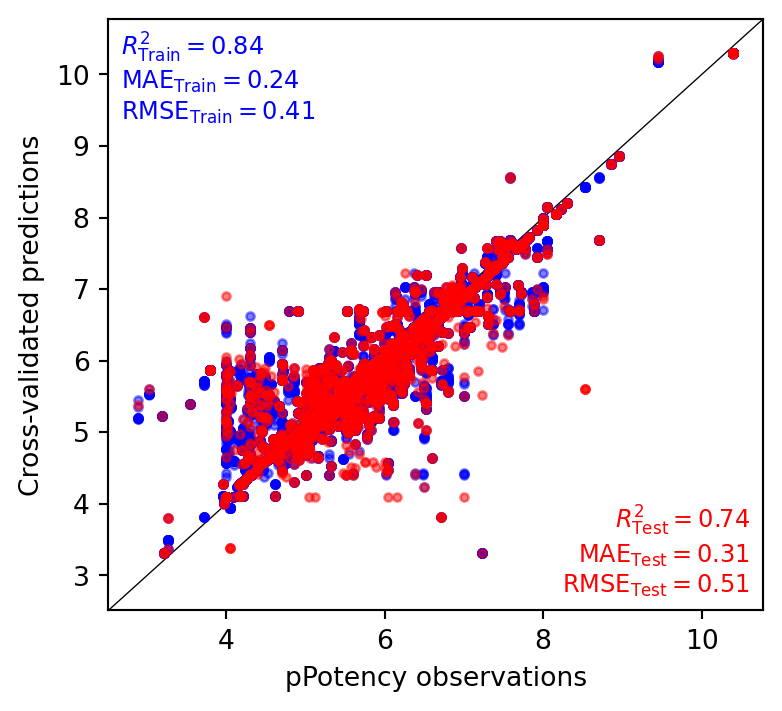


──────────────────────────────────────────────────────────────────────────────────────────
Running CV: wMACAW_ChemBERTa
──────────────────────────────────────────────────────────────────────────────────────────
Model training with: 2704 instances
ART/precomputed feature count: 192
Use MACAW: True
Scale features inside fold: True
Cross Validation Metrics: wMACAW_ChemBERTa
Train: MAE 0.23 | RMSE 0.41 | R² 0.84
Test:  MAE 0.30 | RMSE 0.51 | R² 0.75
Feature count per fold: [252]
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_CV_wMACAW_ChemBERTa.png


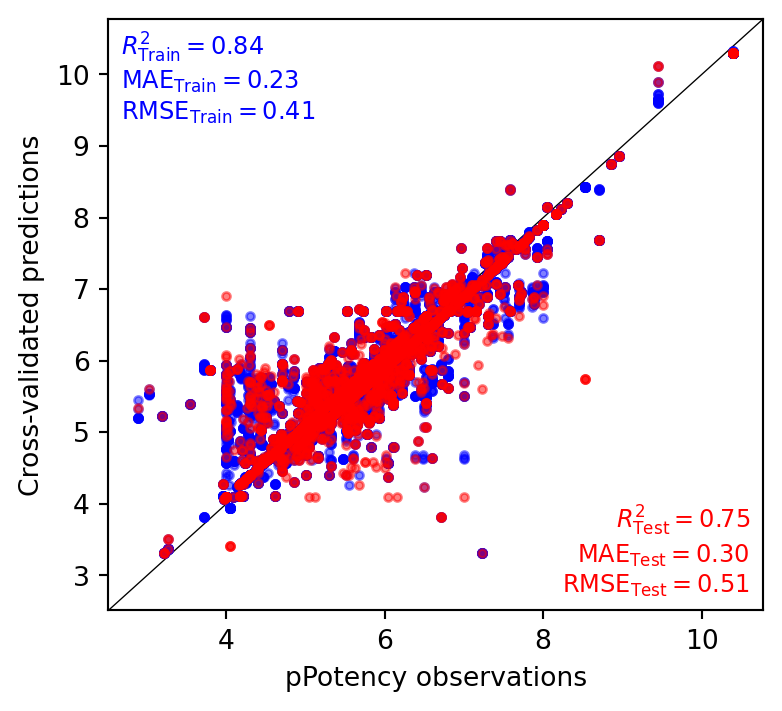

,Model,FeatureCountMin,FeatureCountMax,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,BestParamsPerFold,PredictionFile
0,wMACAW_ChemBERTa,252,252,0.234458,0.407936,0.839105,0.304407,0.512396,0.746154,"[{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', '...",/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
1,wChemBERTa,192,192,0.236461,0.410662,0.836948,0.306517,0.513634,0.744927,"[{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', '...",/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...


In [29]:
def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"EbolaVirusData_allDB_w{choiceName}_PCA_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_PCA_ARTready.csv")))
    return matches[0] if matches else None


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_PCA_ARTready.csv", "_ARTready_featureInfo.json")
    if not os.path.exists(infoPath):
        return {}
    with open(infoPath, "r") as fh:
        return json.load(fh)


# MACAW-only baseline excluded — no embedding to reduce.
comparisonPlan = [
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]

# Load, align, and run 
uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {}
for choice in uniqueARTChoices:
    csvPath = getARTReadyCsvPath(choice)
    if csvPath is None:
        print(f"  Skipping '{choiceToFileStem(choice)}' — PCA-reduced CSV not found.")
        continue
    artInputByChoice[choice] = readARTReadyCSV(choice)

print("\nLoaded PCA+UMAP-reduced ART-ready files")
print("-" * 110)
for choice, item in artInputByChoice.items():
    print(
        f"{item['choiceName']:<35} "
        f"molecules={item['DF'].shape[0]:<8} "
        f"features={len(item['featureCols']):<8} "
        f"file={os.path.basename(item['csvPath'])}"
    )

availableKeyCols = [
    c for c in ["compound_id", smilesCol, "StrainClassifier"]
    if all(c in item["DF"].columns for item in artInputByChoice.values())
] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across PCA-reduced files.")
    for item in artInputByChoice.values():
        item["DF"] = (
            item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
            .sort_values("_cvKey").reset_index(drop=True)
        )

featureExperiments = [
    {"modelTag": modelTag, "DF": artInputByChoice[choice]["DF"].copy(),
     "featureCols": artInputByChoice[choice]["featureCols"], "useMacaw": useMacaw,
     "featureInfo": artInputByChoice[choice]["featureInfo"]}
    for modelTag, choice, useMacaw in comparisonPlan
    if choice in artInputByChoice
]

cvResults = []
for experiment in featureExperiments:
    result = runFeatureSetCV(
        DF=experiment["DF"], featureCols=experiment["featureCols"],
        useMacaw=experiment["useMacaw"], modelTag=experiment["modelTag"],
    )
    result["ARTFeatureInfo"] = experiment.get("featureInfo", {})
    cvResults.append(result)

# Summary 
cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE": r["Test_MAE"], "Test_RMSE": r["Test_RMSE"], "Test_R2": r["Test_R2"],
     "BestParamsPerFold": r["BestParamsPerFold"], "PredictionFile": r["PredictionFile"]}
    for r in cvResults
])

requestedOrder = [tag for tag, _, _ in comparisonPlan]
cvSummaryDF["RequestedOrder"] = cvSummaryDF["Model"].map({n: i for i, n in enumerate(requestedOrder)})

cvSummaryDF_ranked = (
    cvSummaryDF.sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True])
               .drop(columns=["RequestedOrder"]).reset_index(drop=True)
)


cvSummaryDF_ranked

### Foundation model parameter tuning to find best `test-R2`

# 3. Use ART to get predictions using `Ensemble model`

### Extract the data for `Ebola` into a data frame with `duplicate` SMILES

In [165]:
EbolaVirusData_allDB_wMACAW = pd.read_csv(resultsDir + "EbolaVirusData_allDB_wMACAW.csv")
EbolaVirusData_allDB_wMACAW 

,compound_id,Canonical_SMILES,pPotency,StrainClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.4202,Ebola,-0.1644,0.0589,-0.1945,0.2311,-0.1416,0.0525,...,-0.0021,0.0113,0.0143,-0.0002,0.0561,-0.0132,0.0493,0.0299,0.0330,0.0172
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.1192,Ebola,-0.1644,0.0589,-0.1945,0.2311,-0.1416,0.0525,...,-0.0021,0.0113,0.0143,-0.0002,0.0561,-0.0132,0.0493,0.0299,0.0330,0.0172
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.4949,Ebola,-0.1542,0.0591,-0.1601,0.2136,-0.1453,0.0446,...,-0.0119,-0.0318,0.0021,-0.0265,0.0419,-0.0128,0.0392,-0.0261,0.0266,-0.0044
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.5200,Ebola,-0.1542,0.0591,-0.1601,0.2136,-0.1453,0.0446,...,-0.0119,-0.0318,0.0021,-0.0265,0.0419,-0.0128,0.0392,-0.0261,0.0266,-0.0044
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola,-0.1736,0.0552,-0.1842,0.2359,-0.1418,0.0433,...,-0.0028,0.0126,0.0198,-0.0093,0.0438,0.0062,0.0533,0.0162,0.0123,0.0080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola,0.0094,-0.0156,0.0711,0.0352,-0.0339,-0.1635,...,0.0151,0.0256,0.0086,0.0152,0.0158,-0.0216,0.0446,0.0144,0.0219,-0.0244
2700,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola,0.0094,-0.0156,0.0711,0.0352,-0.0339,-0.1635,...,0.0151,0.0256,0.0086,0.0152,0.0158,-0.0216,0.0446,0.0144,0.0219,-0.0244
2701,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola,-0.0411,-0.0001,0.0743,0.0455,-0.0169,-0.1470,...,-0.0527,-0.0361,0.0216,-0.0093,0.0476,-0.0019,-0.0585,-0.0060,-0.0027,0.0293
2702,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola,-0.0411,-0.0001,0.0743,0.0455,-0.0169,-0.1470,...,-0.0527,-0.0361,0.0216,-0.0093,0.0476,-0.0019,-0.0585,-0.0060,-0.0027,0.0293


### Prepare data to run `ART` on `Ebola` data with `duplicate` SMILES + predict response with `ART`

#### Find Features and Response

In [166]:
input_var = [col for col in EbolaVirusData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

MACAW Embeddings: 60
['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']


### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

run using ART command line interface

`/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART_MACAW`

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from `MACAW`

ART model loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_MACAW/ART_results/art.cpkl
ART output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative


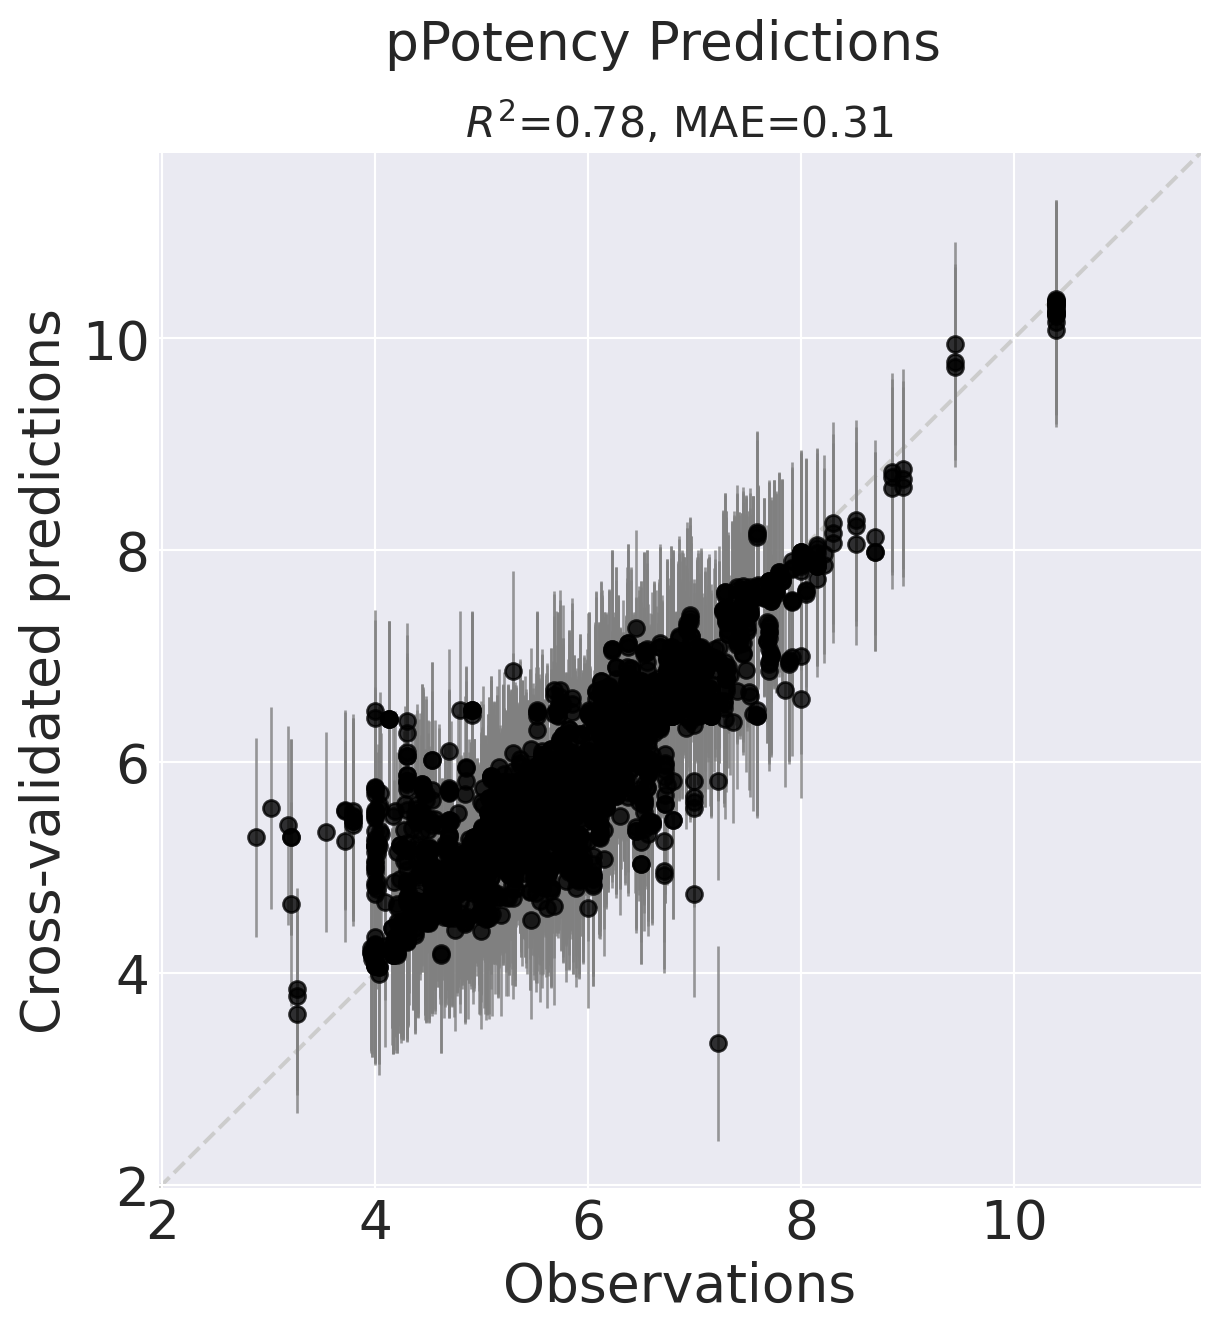

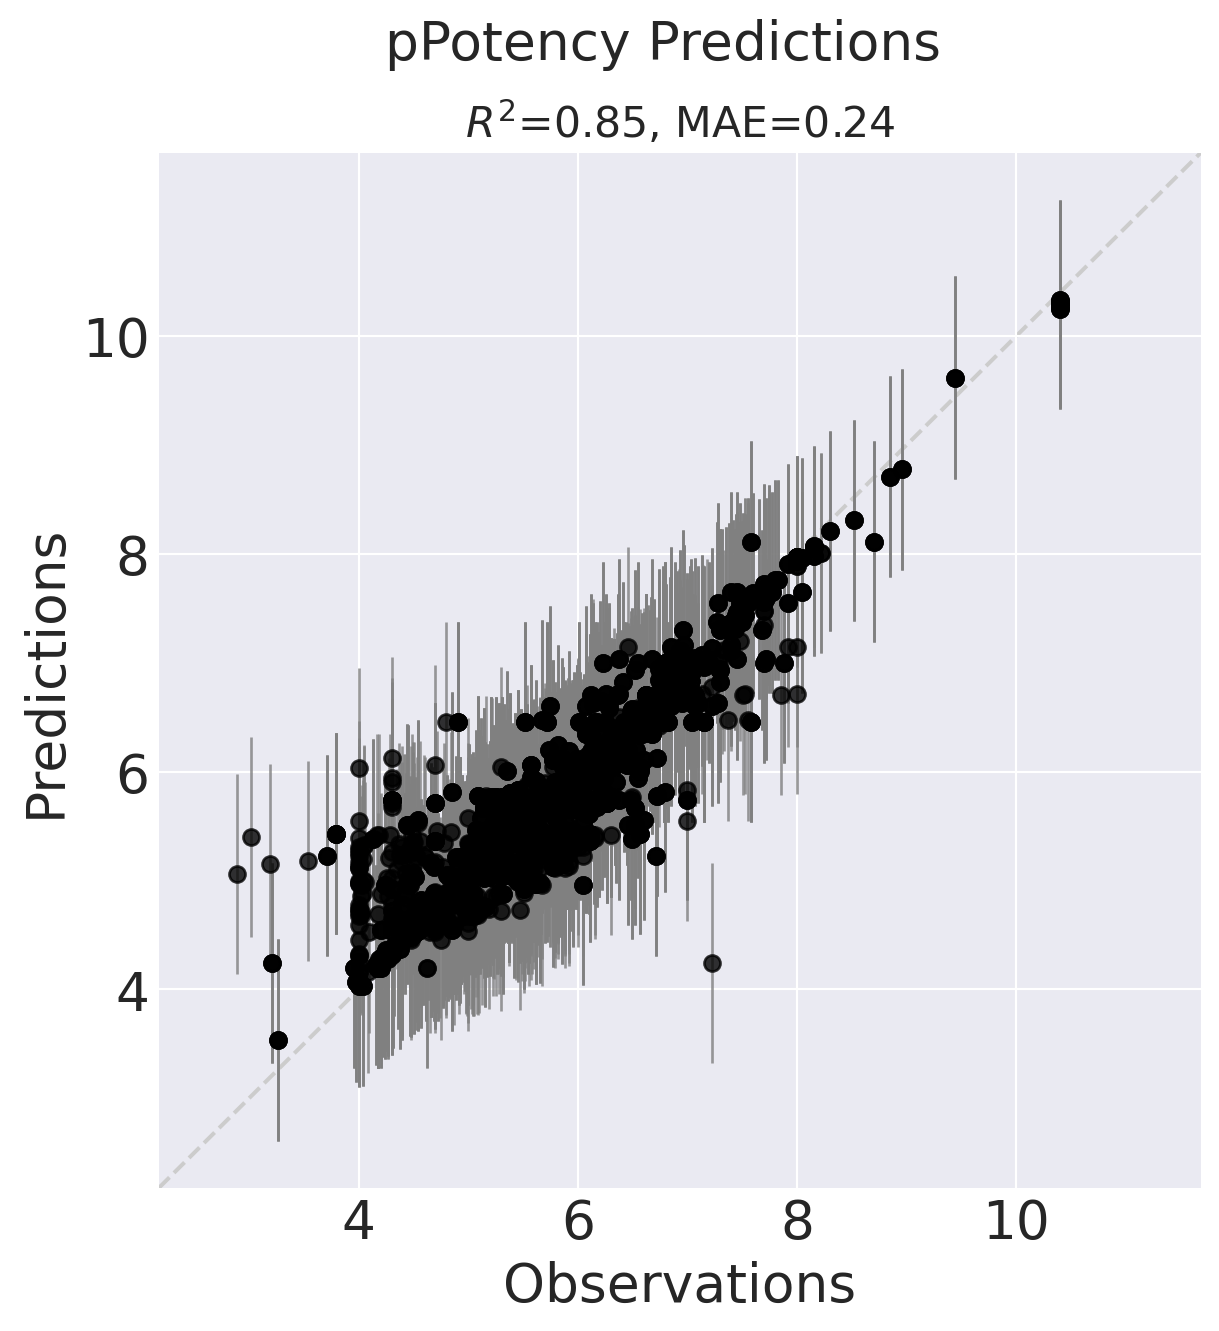

In [167]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART/ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art_macaw,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art_macaw,
    cv=False,
    error_bars=True
)

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from Foundation models (`MoLFormer`)

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from Foundation models (`ChemBARTa`)

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from Foundation models (`MIST`)

# 4. Find external validation with pre-trained `ART` models

## 4.1 Predict pPotency `FDA approved` antivirals from `Drugbank`

In [33]:
drugBankDrug_FDAapproved_Antiviral = pd.read_csv(dataDir + "Toxicity/DrugBank/drugBankDrug_FDAapproved_antiviral_wToxicity.csv", dtype=str)
print(f"Original DrugBank data shape: {drugBankDrug_FDAapproved_Antiviral.shape}")

drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[["smiles","ATC_code","Drug_Type"]].copy()
# canonicalize and rename
drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"] = drugBankDrug_FDAapproved_Antiviral["smiles"].apply(canonicalizeSmiles)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral.drop(columns=["smiles"])
drugBankDrug_FDAapproved_Antiviral

Original DrugBank data shape: (77, 102)


,ATC_code,Drug_Type,Canonical_SMILES
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...
...,...,...,...
72,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O
73,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...
74,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1
75,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...


### Check how many common `SMILES` are presents in training set

In [34]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(drugBankDrug_FDAapproved_Antiviral)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[
    ~drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(drugBankDrug_FDAapproved_Antiviral)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(drugBankDrug_FDAapproved_Antiviral)}")

drugBankDrug_FDAapproved_Antiviral

Number of canonical SMILES common to training & external: 1
Training set molecules found and removed (unique canonical overlap): 1
Total buyable antiviral molecules for external validation after removing training set molecules: 76


,ATC_code,Drug_Type,Canonical_SMILES
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...
...,...,...,...
71,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O
72,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...
73,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1
74,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [35]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(drugBankDrug_FDAapproved_Antiviral['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=drugBankDrug_FDAapproved_Antiviral.index)

drugBankDrug_FDAapproved_Antiviral_wMACAW = pd.concat([drugBankDrug_FDAapproved_Antiviral, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {drugBankDrug_FDAapproved_Antiviral.shape}")
print(f"New dataframe shape: {drugBankDrug_FDAapproved_Antiviral_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
drugBankDrug_FDAapproved_Antiviral_wMACAW.to_csv(os.path.join(resultsDir, "drugBankDrug_FDAapproved_Antiviral_wMACAW.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (76, 60)

Original dataframe shape: (76, 3)
New dataframe shape: (76, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58

,ATC_code,Drug_Type,Canonical_SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,-0.154581,0.057817,-0.111791,0.122726,-0.066385,0.011532,-0.027614,...,-0.021035,0.031125,0.006020,-0.000483,0.024706,-0.008426,-0.020618,0.031630,-0.006894,-0.008609
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,-0.150799,0.070359,-0.124676,0.105466,-0.118500,0.052182,-0.041103,...,-0.020220,-0.034662,-0.010488,0.029502,0.041084,0.010992,0.006629,0.008703,-0.008122,-0.015621
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,-0.006626,-0.004172,-0.118031,0.000648,0.020309,0.042132,-0.005272,...,-0.036868,-0.024796,-0.025639,0.012159,-0.009462,0.000069,0.027401,-0.036029,-0.016555,-0.002122
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,0.028557,-0.033331,-0.049008,0.035660,0.064683,-0.101755,0.023688,...,0.016377,-0.001431,0.008500,-0.008178,0.005819,-0.001227,0.017319,-0.017944,-0.007595,0.017799
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,0.147636,-0.096422,-0.117657,0.064573,0.094344,0.032768,0.030077,...,-0.035321,0.014993,-0.004221,0.025059,0.004012,0.025031,0.022012,-0.011099,-0.012547,0.000916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,-0.135321,0.060291,-0.204447,0.202536,-0.123838,0.028684,-0.062774,...,0.033813,0.058853,0.026854,0.048385,0.065170,-0.027663,0.019288,0.027312,0.043169,0.029179
72,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,0.176338,-0.083581,-0.144988,0.059983,0.107786,0.050877,0.025644,...,-0.024515,0.014442,0.012758,0.021303,-0.028253,0.040523,0.028925,-0.029333,-0.027215,0.002229
73,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,-0.135665,0.109679,-0.131889,0.090855,-0.081821,-0.005869,-0.045836,...,0.026758,-0.021515,-0.002617,0.056013,0.002312,0.041448,0.004929,0.000928,-0.008234,-0.004413
74,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,-0.087905,0.037014,-0.163909,0.100257,-0.068389,-0.028876,-0.005645,...,0.037752,-0.028109,0.012918,0.026430,0.047356,-0.007208,0.014017,-0.024430,0.012780,-0.024942


In [36]:
macawFeatureCols = [col for col in drugBankDrug_FDAapproved_Antiviral_wMACAW.columns if col.startswith('MACAW_')]
smiLib = drugBankDrug_FDAapproved_Antiviral_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [37]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wMACAW[['Canonical_SMILES', 'Drug_Type']].copy()

drugBankDrug_FDAapproved_Antiviral_wART['pPotency_prediction'] = mean
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_std'] = std

# Calculate 95% Confidence Intervals
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'] = mean - 1.96 * std
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_prediction'] = 10 ** (-mean)
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_lower_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'])
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_upper_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'])

# Select and save results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wART.filter(
    items=["Canonical_SMILES", "Drug_Type", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

drugBankDrug_FDAapproved_Antiviral_wART = (
    drugBankDrug_FDAapproved_Antiviral_wART
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

drugBankDrug_FDAapproved_Antiviral_wART.to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wART[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmin()]
potency_max = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

drugBankDrug_FDAapproved_Antiviral_wART

Predicted potency range: 5.112 ± 0.48 - 6.629 ± 0.47


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005
...,...,...,...,...,...,...,...,...,...
71,CC(C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@H](n...,antiviral,5.157025,0.475299,4.225440,6.088610,6.965867e-06,8.154363e-07,0.000060
72,CN(C)CCOCC(=O)NC12CC3CC(CC(C3)C1)C2,antiviral,5.146557,0.478147,4.209389,6.083725,7.135807e-06,8.246596e-07,0.000062
73,CC(C)[C@H](N)C(=O)OCCOCn1cnc2c(=O)nc(N)[nH]c21,antiviral,5.122079,0.478454,4.184309,6.059849,7.549542e-06,8.712659e-07,0.000065
74,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,antiviral,5.116885,0.481782,4.172592,6.061179,7.640375e-06,8.686028e-07,0.000067


### Compute `ADMET profile` of all `FDA approved` antibiotics

In [38]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrug_FDAapproved_Antiviral_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrug_FDAapproved_Antiviral_wART_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,602.585,...,17.855888,32.548330,87.381371,56.028120,15.536028,96.731107,79.613357,70.298770,48.189807,68.611599
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003,868.948,...,33.743409,47.451670,84.323374,66.362039,33.110721,95.676626,87.662566,95.676626,10.966608,19.437610
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004,838.878,...,29.384886,28.014060,75.395431,53.040422,27.065026,96.590510,74.446397,88.084359,18.699473,14.657293
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005,894.127,...,22.249561,61.300527,94.235501,91.458699,13.673111,94.270650,99.578207,97.504394,3.971880,70.685413
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005,1113.199,...,26.924429,3.339192,82.319859,97.434095,9.173989,99.964851,99.683656,94.938489,4.217926,92.794376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,CC(C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@H](n...,antiviral,5.157025,0.475299,4.225440,6.088610,6.965867e-06,8.154363e-07,0.000060,529.458,...,20.246046,46.959578,77.680141,3.233743,20.351494,91.845343,58.980668,52.688928,56.555360,18.418278
72,CN(C)CCOCC(=O)NC12CC3CC(CC(C3)C1)C2,antiviral,5.146557,0.478147,4.209389,6.083725,7.135807e-06,8.246596e-07,0.000062,280.412,...,78.101933,67.908612,56.098418,42.355009,74.551845,61.546573,46.362039,22.530756,67.557118,61.968366
73,CC(C)[C@H](N)C(=O)OCCOCn1cnc2c(=O)nc(N)[nH]c21,antiviral,5.122079,0.478454,4.184309,6.059849,7.549542e-06,8.712659e-07,0.000065,324.341,...,13.778559,27.100176,33.673111,8.154657,12.583480,40.456942,16.731107,21.089631,61.089631,67.838313
74,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,antiviral,5.116885,0.481782,4.172592,6.061179,7.640375e-06,8.686028e-07,0.000067,225.208,...,16.309315,25.026362,20.281195,18.488576,14.727592,24.639719,16.414763,21.933216,65.272408,70.861160


### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [39]:
# Potency-related columns
dataCols = ["Canonical_SMILES","Drug_Type"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_Antiviral_wART_wADMET.columns
]

drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_Antiviral_wART_wADMET.shape)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.to_csv(resultsDir + "drugBankDrug_FDAapproved_Antiviral_wART_wADMET.csv", index=False)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.head()

Filtered dataframe shape: (76, 42)


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,0.473479,...,0.277044,0.757844,0.001464,0.091504,0.089238,0.112458,0.049566,0.061976,0.630507,0.594246
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003,0.402790,...,0.828310,0.719191,0.000117,0.095870,0.049874,0.261650,0.025222,0.006694,0.876515,0.975297
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004,0.402193,...,0.566219,0.692124,0.000146,0.062885,0.067880,0.181337,0.019857,0.011510,0.771802,0.868724
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005,0.110028,...,0.472612,0.741510,0.000094,0.232419,0.103702,0.511647,0.014375,0.013199,0.846098,0.938079
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005,0.078322,...,0.677893,0.716190,0.000045,0.234808,0.075199,0.690765,0.026800,0.019639,0.937238,0.997227


### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [40]:
drugBankDrugWithdrawnDataDF = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF

,Unnamed: 0,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.244807,...,0.463332,0.605704,0.017399,0.263449,0.207183,0.100211,0.232910,0.125635,0.925135,0.938593
1,1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,0.215953,...,0.027663,0.470261,0.000746,0.008154,0.066037,0.003312,0.010593,0.036415,0.061753,0.000318
2,2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,0.494518,...,0.737525,0.696307,0.166940,0.244747,0.189303,0.188501,0.161169,0.020346,0.343310,0.108636
3,3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,0.678855,...,0.086299,0.860139,0.031484,0.182946,0.114121,0.124554,0.160284,0.026472,0.090174,0.046522
4,4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,0.227781,...,0.227191,0.956495,0.102633,0.029928,0.428593,0.004736,0.231113,0.026281,0.171291,0.030738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,0.250689,...,0.094615,0.934835,0.072102,0.036693,0.347887,0.206038,0.039468,0.026548,0.103570,0.006168
605,605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,0.010421,...,0.845728,0.240165,0.000727,0.004731,0.050183,0.001061,0.538791,0.215035,0.560323,0.001474
606,606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,0.013408,...,0.984755,0.942265,0.243439,0.567955,0.310735,0.045990,0.262644,0.001311,0.650809,0.001634
607,607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,0.139711,...,0.753677,0.839571,0.949634,0.672943,0.431539,0.900576,0.232279,0.186494,0.658334,0.171204


In [41]:
drugBankDrugWithdrawnDataDF["Canonical_SMILES"] = (
    drugBankDrugWithdrawnDataDF["SMILES"].apply(canonicalizeSmiles))

# Keep only Name + Canonical_SMILES and add Drug_Type
drugBankDrugWithdrawnDataDF = drugBankDrugWithdrawnDataDF[
    ["Name", "Canonical_SMILES"]].copy()

drugBankDrugWithdrawnDataDF["Drug_Type"] = "withdrawn"
drugBankDrugWithdrawnDataDF

,Name,Canonical_SMILES,Drug_Type
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn
...,...,...,...
604,Benzoylpas,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,withdrawn
605,Pentapiperium,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,withdrawn
606,Dichlorotetrafluoroethane,FC(F)(Cl)C(F)(F)Cl,withdrawn
607,Tribromsalan,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,withdrawn


### Compute `ADMET profile` of all `FDA withdrawn` drugs (we do not know the category like antiviral/antibiotic)

In [42]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrugWithdrawnDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrugWithdrawnDataDF_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Name,Canonical_SMILES,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn,1416.089,1.1680,16,13,1.0,0.024675,10,...,3.725835,22.917399,94.446397,54.692443,3.198594,84.253076,59.086116,69.279438,51.739895,54.973638
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn,347.224,-1.8630,9,5,4.0,0.390179,4,...,7.029877,17.609842,42.460457,38.558875,6.783831,21.898067,24.147627,21.687170,80.702988,72.126538
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn,278.436,5.6605,1,1,3.0,0.348410,0,...,80.843585,89.490334,77.188049,2.284710,89.138840,10.755712,70.123023,84.639719,19.718805,29.068541
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn,240.306,-0.8084,6,4,4.0,0.336025,2,...,10.474517,32.794376,38.804921,8.435852,16.414763,22.214411,14.657293,31.564148,62.917399,6.889279
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn,204.229,1.1223,2,3,4.0,0.700584,1,...,19.332162,14.868190,12.513181,15.079086,25.659051,53.005272,21.652021,32.513181,72.794376,25.553603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Benzoylpas,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,withdrawn,257.245,2.3427,3,3,4.0,0.787225,0,...,39.086116,49.490334,31.599297,11.704745,35.114236,19.718805,29.630931,66.467487,39.156415,22.214411
605,Pentapiperium,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,withdrawn,304.454,3.5983,2,0,4.0,0.613551,2,...,79.929701,62.495606,33.954306,60.702988,72.548330,42.390158,34.973638,16.274165,80.175747,75.711775
606,Dichlorotetrafluoroethane,FC(F)(Cl)C(F)(F)Cl,withdrawn,170.920,2.6496,0,0,4.0,0.419713,0,...,99.437610,91.950791,68.049209,72.442882,99.824253,0.421793,68.049209,36.801406,55.079086,84.674868
607,Tribromsalan,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,withdrawn,449.924,4.9320,2,2,4.0,0.682461,0,...,54.692443,74.235501,75.043937,97.574692,70.123023,66.080844,91.142355,81.898067,8.049209,94.130053


### Retain only `Canonical_SMILES`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [43]:
# Potency-related columns
dataCols = ["Name","Canonical_SMILES","Drug_Type"]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugWithdrawnDataDF_wADMET.columns
]

drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET.to_csv(resultsDir + "drugBankDrugWithdrawnDataDF_wADMET.csv", index=False)
drugBankDrugWithdrawnDataDF_wADMET.head()

Filtered dataframe shape: (609, 36)


,Name,Canonical_SMILES,Drug_Type,AMES,hERG,DILI,ClinTox,Carcinogens_Lagunin,Skin_Reaction,LD50_Zhu,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn,0.254504,0.981034,0.470070,0.309441,0.066228,0.117368,3.057549,...,0.011846,0.223714,0.000003,0.029137,0.004623,0.127366,0.004255,0.238418,0.695700,0.997110
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn,0.332332,0.071598,0.720851,0.552732,0.126209,0.204692,1.965409,...,0.001456,0.181162,0.000473,0.027287,0.008534,0.011404,0.001425,0.024123,0.049317,0.001035
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn,0.237453,0.234704,0.159396,0.105420,0.264607,0.763378,1.705102,...,0.727614,0.690413,0.038983,0.054847,0.270240,0.044004,0.203606,0.062427,0.563903,0.036418
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn,0.722585,0.013167,0.049900,0.039962,0.234551,0.722627,1.971292,...,0.047806,0.516514,0.001128,0.006420,0.008872,0.002367,0.031434,0.001855,0.049758,0.000370
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn,0.286964,0.224766,0.344543,0.237204,0.320831,0.499903,2.486238,...,0.474984,0.870896,0.238705,0.042194,0.192286,0.022449,0.227100,0.082563,0.260672,0.013772


## 4.2 Checking drug likeliness of custom compounds:
- `Remdesivir`
- `Molnupiravir`
- `Favipiravir`
- `Brincidofovir`

In [44]:
querySmilesDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir": r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryCanonicalDict = {name: canonicalizeSmiles(smiles) for name, smiles in querySmilesDict.items()}

queryAntiviralsDF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": cs} for name, cs in queryCanonicalDict.items()])

queryAntiviralsDF

,drugName,Canonical_SMILES
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...


### Are they present in training data ?

In [45]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    queryAntiviralsDF["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(queryAntiviralsDF)
queryAntiviralsDF = queryAntiviralsDF[
    ~queryAntiviralsDF["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(queryAntiviralsDF)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(queryAntiviralsDF)}")

queryAntiviralsDF

Number of canonical SMILES common to training & external: 0
Training set molecules found and removed (unique canonical overlap): 0
Total buyable antiviral molecules for external validation after removing training set molecules: 4


,drugName,Canonical_SMILES
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [46]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(queryAntiviralsDF['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=queryAntiviralsDF.index)

queryAntiviralsDF_wMACAW = pd.concat([queryAntiviralsDF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {queryAntiviralsDF.shape}")
print(f"New dataframe shape: {queryAntiviralsDF_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
queryAntiviralsDF_wMACAW.to_csv(os.path.join(resultsDir, "queryAntiviralsDF_wMACAW.csv"), index=False)
queryAntiviralsDF_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4, 60)

Original dataframe shape: (4, 2)
New dataframe shape: (4, 62)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 

,drugName,Canonical_SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.143171,-0.169881,-0.294594,0.160284,0.215070,-0.007827,0.052498,-0.021193,...,0.017305,0.001557,-0.007112,-0.053585,0.014354,-0.041146,-0.008522,0.004131,0.017275,0.000606
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,-0.078102,0.012838,-0.184307,0.102667,-0.014136,-0.028947,-0.032610,0.027960,...,0.011424,-0.034138,-0.017162,-0.006987,0.027272,0.013374,0.007422,-0.037038,0.008317,-0.046365
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,-0.195735,0.085677,-0.154042,0.164502,-0.220953,0.156392,-0.130209,-0.057172,...,-0.000985,0.009235,0.000004,0.016693,-0.000150,-0.015894,0.002341,-0.043229,-0.002557,-0.011280
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,0.116127,0.019739,-0.093622,0.031452,-0.017005,0.028041,-0.000266,-0.022467,...,0.066637,0.025010,0.020967,0.012361,0.027155,0.019631,-0.016332,-0.079580,-0.021357,-0.025923


In [47]:
macawFeatureCols = [col for col in queryAntiviralsDF_wMACAW.columns if col.startswith('MACAW_')]
smiLib = queryAntiviralsDF_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [48]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_wMACAW[['Canonical_SMILES', 'drugName']].copy()

queryAntiviralsDF_ARTprediction['pPotency_prediction'] = mean
queryAntiviralsDF_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
queryAntiviralsDF_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
queryAntiviralsDF_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'])
queryAntiviralsDF_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'])

# Select and save results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_ARTprediction.filter(
    items=["Canonical_SMILES", "drugName", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

queryAntiviralsDF_ARTprediction = (
    queryAntiviralsDF_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

queryAntiviralsDF_ARTprediction.to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction.csv"), index=False)
queryAntiviralsDF_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

queryAntiviralsDF_ARTprediction

Predicted potency range: 4.909 ± 0.48 - 6.629 ± 0.47


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108


### Plot prediction `probability`

Molecule 1: mean=6.620, std=0.476, 95% CI=[5.695, 7.543], IC50=0.2400 µM
Molecule 2: mean=5.509, std=0.477, 95% CI=[4.602, 6.442], IC50=3.0968 µM
Molecule 3: mean=5.235, std=0.478, 95% CI=[4.290, 6.165], IC50=5.8155 µM
Molecule 4: mean=4.917, std=0.480, 95% CI=[3.985, 5.844], IC50=12.0927 µM


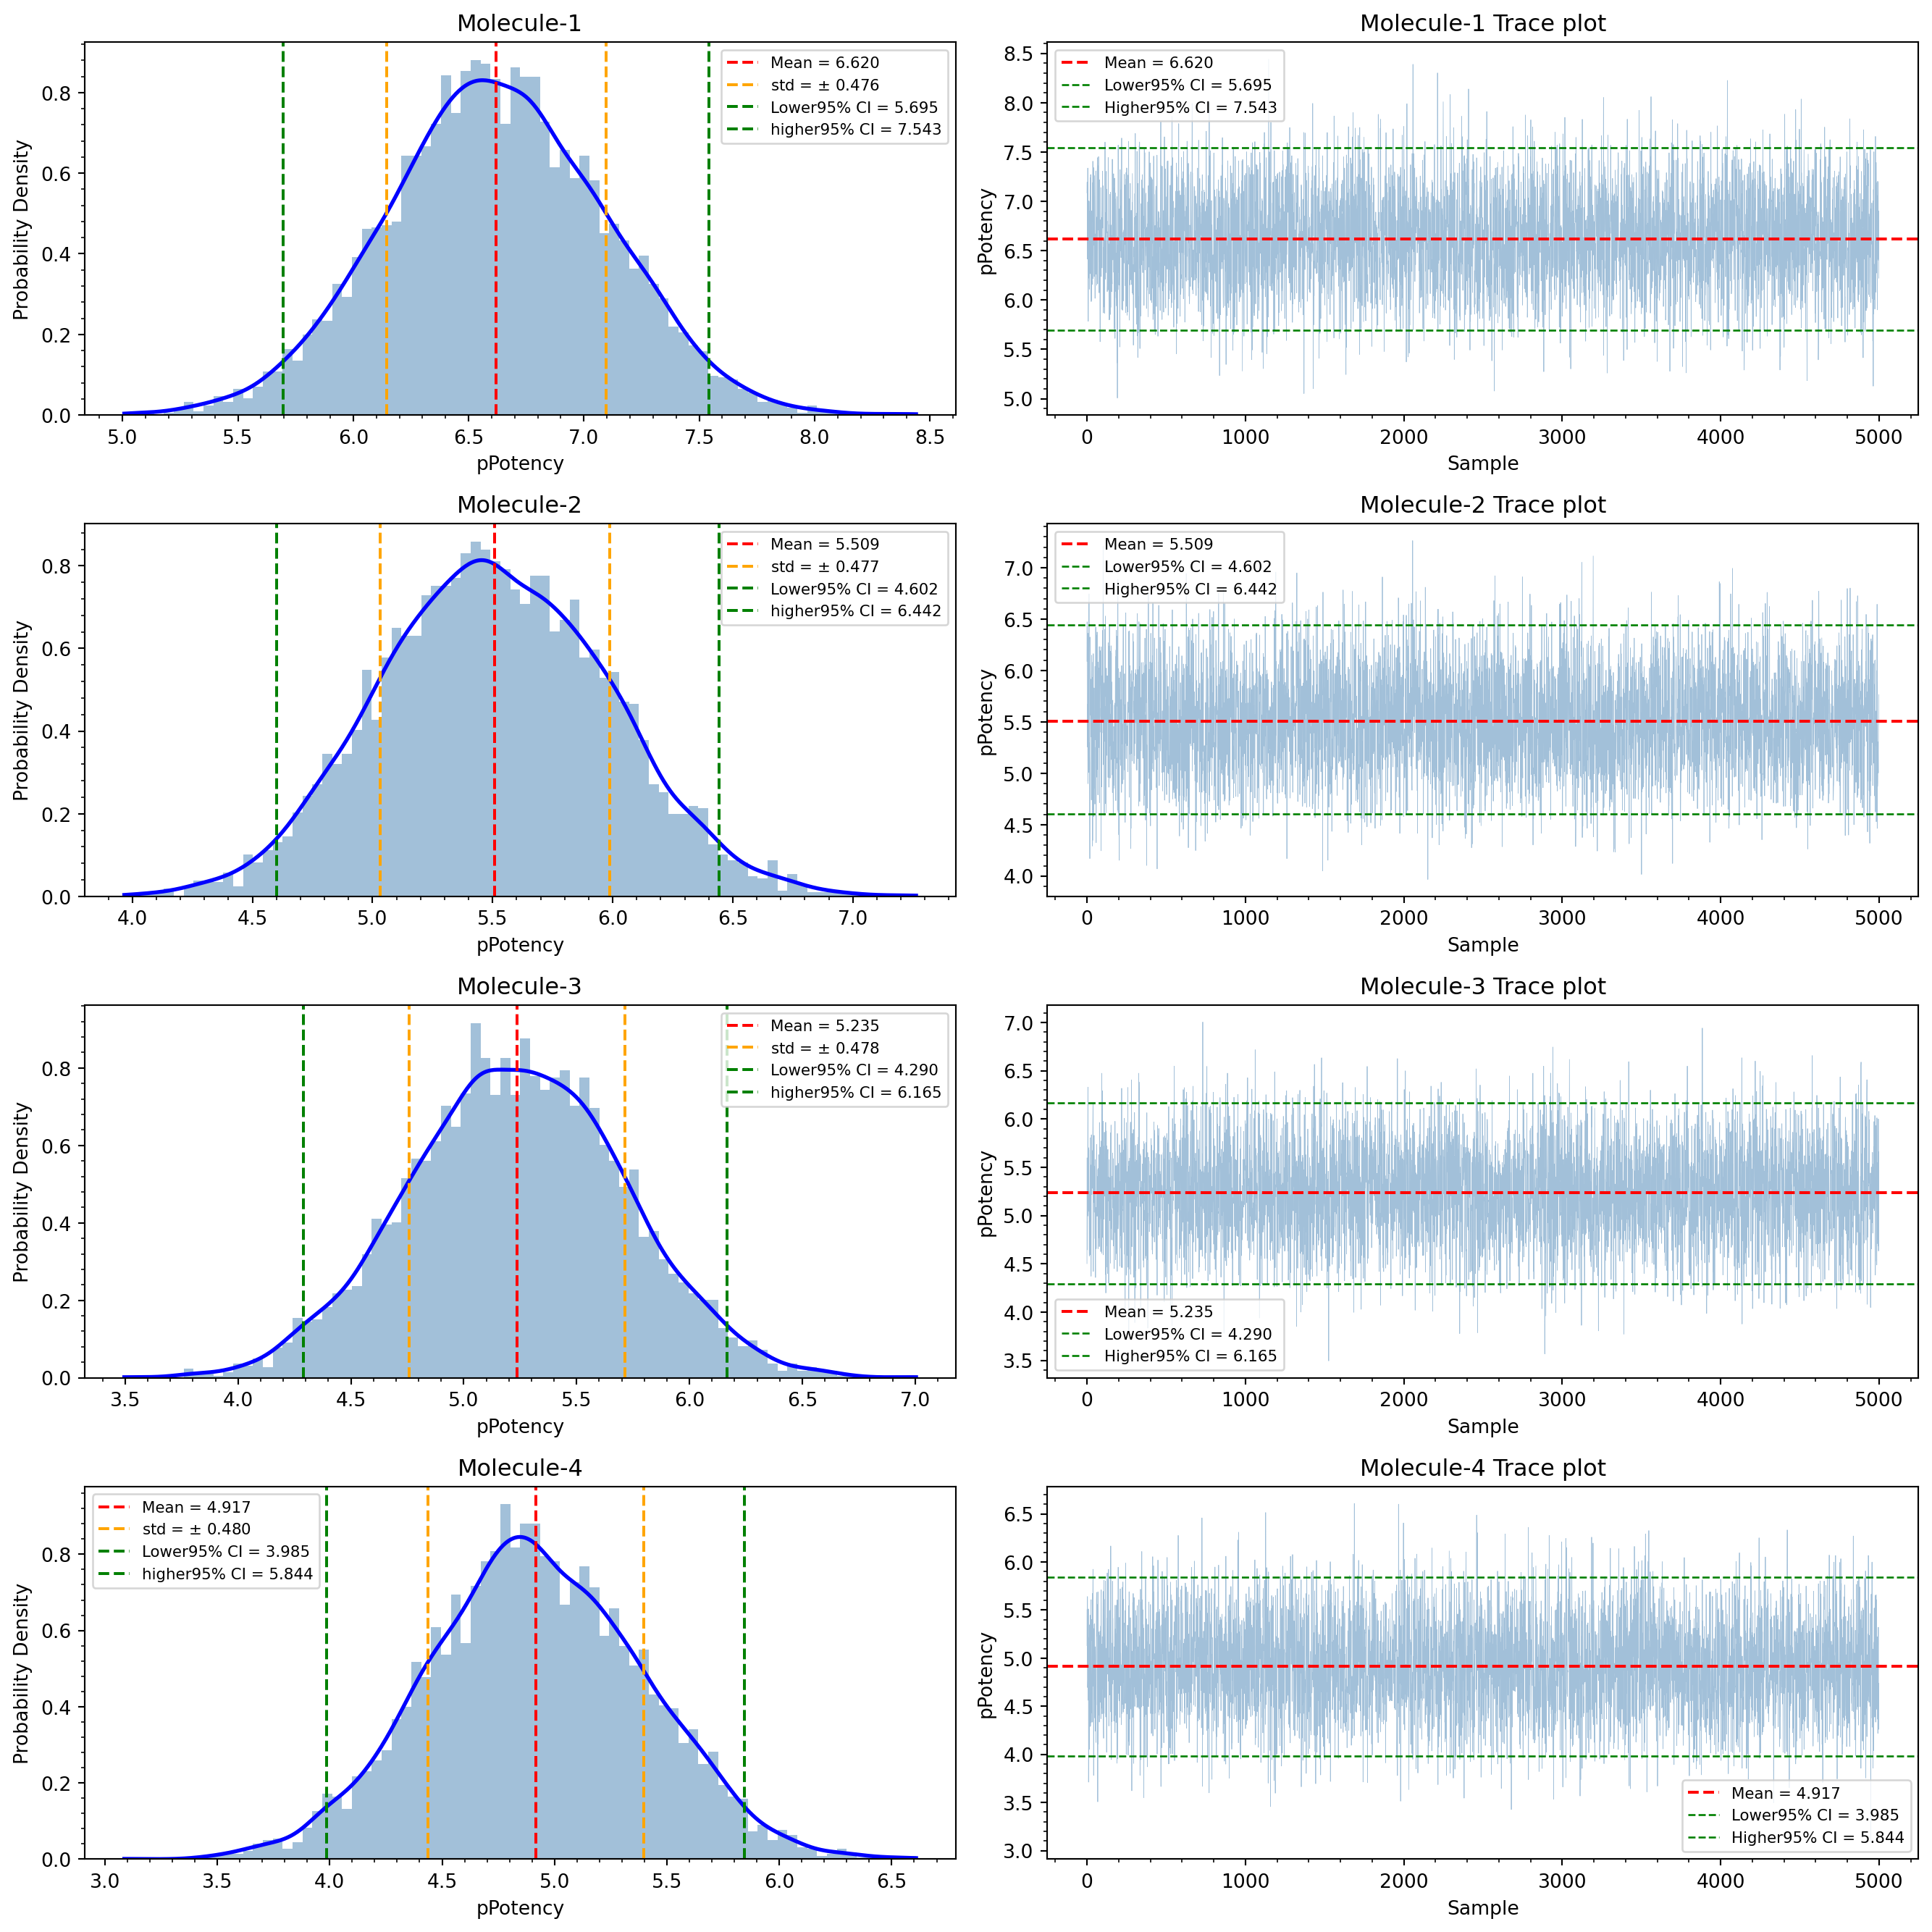

In [49]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=queryAntiviralsDF_ARTprediction,
    feat_df=queryAntiviralsDF_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Show compounds

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/queryAntiviralsDF_wARTprediction_all_Compounds.png
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/queryAntiviralsDF_wARTprediction_all_Compounds.svg


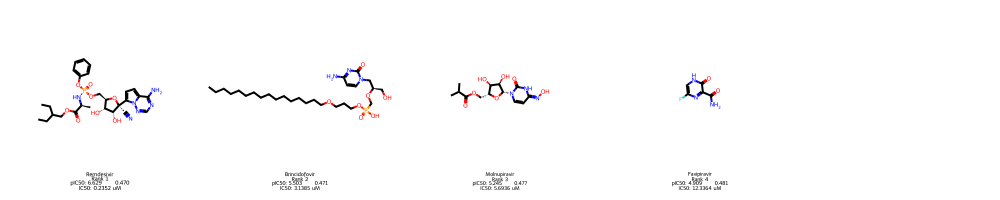

In [50]:
df = queryAntiviralsDF_ARTprediction.sort_values("pPotency_prediction", ascending=False).reset_index(drop=True)

p = df["pPotency_prediction"].to_numpy()
df["Rank"] = np.arange(1, len(df) + 1)
df["pPotency_prediction"] = np.round(p, 3)
df["IC50 (µM)"] = (10 ** (-p)) * 1e6

std_arr = df["pPotency_std"].to_numpy() if "pPotency_std" in df.columns else None
ic50_arr = df["IC50 (µM)"].to_numpy()
p_arr = df["pPotency_prediction"].to_numpy()
drug_arr = df["drugName"].to_numpy()
smi_arr = df["Canonical_SMILES"].to_numpy()

legends = []
for drug, pp, ic, ss in zip(drug_arr, p_arr, ic50_arr, std_arr if std_arr is not None else [None]*len(df)):
    if ss is not None and pd.notna(ss):
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f} ± {ss:.3f}\nIC50: {ic:.4f} uM")
    else:
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f}\nIC50: {ic:.4f} uM")

molecules = []
legends_ok = []
for smi, leg in zip(smi_arr, legends):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        molecules.append(mol)
        legends_ok.append(leg)

output_png = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.png")
png = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(png.data if hasattr(png, "data") else png)

output_svg = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.svg")
svg = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=True)
with open(output_svg, "w") as f:
    f.write(svg.data if hasattr(svg, "data") else svg)

print("Saved:", output_png)
print("Saved:", output_svg)
display(png)

### Compute their ADMET profile

In [51]:
model = ADMETModel()
pred = model.predict(smiles=queryAntiviralsDF_ARTprediction["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
queryAntiviralsDF_wART_wADMET = queryAntiviralsDF_ARTprediction.merge(pred, on="Canonical_SMILES", how="left")
queryAntiviralsDF_wART_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,602.585,...,17.855888,32.548330,87.381371,56.028120,15.536028,96.731107,79.578207,70.298770,48.189807,68.646749
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026,561.701,...,25.448155,77.188049,84.358524,73.251318,30.509666,56.274165,77.680141,70.615114,23.585237,94.411248
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049,329.309,...,16.414763,45.272408,33.321617,5.166960,11.528998,10.474517,18.242531,27.873462,64.815466,42.003515
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108,157.104,...,72.091388,34.657293,15.395431,20.949033,51.001757,44.288225,30.439367,18.664323,76.766257,9.525483


## 4.3.1.1 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

DORAnet starter: `Inosine + Guanosine + Xanthosine + Adenosine`

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals` 
- *with substructure match*

In [168]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Inosine_Pubchem/InosineOnly_gen3/InosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated['source_DataBase'] = 'InosineOnly_gen3'
InosineOnly_DORAnetGenerated

Loaded 4122 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,3,0.5231,NaN,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,3,0.5556,NaN,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,3,0.5556,NaN,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,3,0.5231,NaN,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,3,0.5469,NaN,InosineOnly_gen3
...,...,...,...,...,...,...
4117,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O,3,0.0208,NaN,InosineOnly_gen3
4118,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)=O,3,0.0426,NaN,InosineOnly_gen3
4119,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,N#CC=O,3,0.0204,NaN,InosineOnly_gen3
4120,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CCO,3,0.0682,NaN,InosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [169]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Adenosine_Pubchem/AdenosineOnly_gen3/AdenosineOnly_generated_compounds.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['source_DataBase'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

Loaded 4045 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)[...,3,0.3939,NaN,AdenosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CCC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)...,3,0.5965,NaN,AdenosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...,3,0.4062,NaN,AdenosineOnly_gen3
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,COC[C@H]1O[C@@H](n2cnc3c(N(C(C)=O)C(N)=O)ncnc3...,3,0.4839,NaN,AdenosineOnly_gen3
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@]1(C)O[C@H](CO...,3,0.3382,NaN,AdenosineOnly_gen3
...,...,...,...,...,...,...
4040,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=CCO,3,0.0667,NaN,AdenosineOnly_gen3
4041,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(N)=O,3,0.0444,NaN,AdenosineOnly_gen3
4042,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,N#CC=O,3,0.0,NaN,AdenosineOnly_gen3
4043,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CCO,3,0.0714,NaN,AdenosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [170]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Guanosine_Pubchem/GuanosineOnly_gen3/GuanosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated['source_DataBase'] = 'GuanosineOnly_gen3'
GuanosineOnly_DORAnetGenerated

Loaded 3962 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@H]1[C@@H](O)[C@H](n2c[n+](C)c3c(=O)[nH]c(...,3,0.3973,NaN,GuanosineOnly_gen3
1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@@H]1[C@H](OS(=O)(=O)O)[C@@H](CO)O[C@H]1n1...,3,0.4028,NaN,GuanosineOnly_gen3
2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CNc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@H](CO...,3,0.3333,NaN,GuanosineOnly_gen3
3,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CNc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@H](CO...,3,0.3467,NaN,GuanosineOnly_gen3
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2c[n+](C)c3c...,3,0.4028,NaN,GuanosineOnly_gen3
...,...,...,...,...,...,...
3957,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=CCO,3,0.0816,NaN,GuanosineOnly_gen3
3958,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(N)=O,3,0.0612,NaN,GuanosineOnly_gen3
3959,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,N#CC=O,3,0.0192,NaN,GuanosineOnly_gen3
3960,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CCO,3,0.0638,NaN,GuanosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [171]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Xanthosine_Pubchem/XanthosineOnly_gen3/XanthosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated['source_DataBase'] = 'XanthosineOnly_gen3'
XanthosineOnly_DORAnetGenerated

Loaded 3398 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)...,3,0.6333,NaN,XanthosineOnly_gen3
1,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(...,3,0.6271,NaN,XanthosineOnly_gen3
2,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1...,3,0.6333,NaN,XanthosineOnly_gen3
3,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2c[n+](C)c3c...,3,0.3623,NaN,XanthosineOnly_gen3
4,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,Cn1c(=O)[nH]c2c(c1=O)[n+](C)cn2[C@@H]1O[C@H](C...,3,0.3194,NaN,XanthosineOnly_gen3
...,...,...,...,...,...,...
3393,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CC(N)O,3,0.0208,NaN,XanthosineOnly_gen3
3394,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CC(N)=O,3,0.0426,NaN,XanthosineOnly_gen3
3395,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,N#CC=O,3,0.0204,NaN,XanthosineOnly_gen3
3396,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CCO,3,0.0682,NaN,XanthosineOnly_gen3


### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [172]:
%%time

dfList = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

combinedEbola_allDORAnetGenerated_Antivirals = pd.concat(dfList, ignore_index=True)

del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

combinedEbola_allDORAnetGenerated_Antivirals = (
    combinedEbola_allDORAnetGenerated_Antivirals
    .dropna(subset=["Canonical_SMILES"])
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .filter(items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase"])
    .reset_index(drop=True)
)
gc.collect()

print(f"Total molecules after deduplication: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

output_path = DORANETmoleculesDataDir + "combinedEbola_allDORAnetGenerated_Antivirals.csv"
combinedEbola_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

combinedEbola_allDORAnetGenerated_Antivirals

Total molecules before deduplication: 15527
Total molecules after deduplication: 15477
Saved to /users/sghosh6/DTRA_project/MACAW/doranet/scriptscombinedEbola_allDORAnetGenerated_Antivirals.csv
CPU times: user 1.22 s, sys: 56.1 ms, total: 1.28 s
Wall time: 1.28 s


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3
...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3


### Remove common `SMILES` presents in training data (if any)

In [173]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    combinedEbola_allDORAnetGenerated_Antivirals["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(combinedEbola_allDORAnetGenerated_Antivirals)
combinedEbola_allDORAnetGenerated_Antivirals = combinedEbola_allDORAnetGenerated_Antivirals[
    ~combinedEbola_allDORAnetGenerated_Antivirals["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(combinedEbola_allDORAnetGenerated_Antivirals)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

combinedEbola_allDORAnetGenerated_Antivirals

Number of canonical SMILES common to training & external: 0
Training set molecules found and removed (unique canonical overlap): 0
Total buyable antiviral molecules for external validation after removing training set molecules: 15477


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3
...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [174]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbola_allDORAnetGenerated_Antivirals['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbola_allDORAnetGenerated_Antivirals.index)

combinedEbola_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([combinedEbola_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbola_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (15477, 60)

Original dataframe shape: (15477, 3)
New dataframe shape: (15477, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 

,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3,-0.0648,-0.0163,-0.1786,0.1044,-0.0196,-0.0022,-0.0265,...,0.0072,-0.0200,-0.0019,0.0258,0.0619,-0.0517,0.0303,-0.0100,-0.0007,-0.0201
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3,-0.0667,-0.0036,-0.1568,0.1018,-0.0310,-0.0091,-0.0222,...,0.0313,-0.0054,-0.0031,0.0278,0.0548,-0.0158,0.0243,-0.0002,0.0144,-0.0111
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3,-0.0675,-0.0022,-0.1797,0.1140,-0.0295,-0.0068,-0.0191,...,0.0182,-0.0081,0.0037,0.0324,0.0470,-0.0177,0.0202,-0.0092,0.0211,-0.0123
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3,-0.0659,-0.0211,-0.1825,0.1172,-0.0152,-0.0007,-0.0265,...,0.0253,-0.0142,-0.0081,0.0192,0.0418,-0.0358,0.0351,-0.0062,0.0067,-0.0199
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3,-0.0638,-0.0163,-0.1647,0.1135,-0.0202,-0.0210,-0.0287,...,0.0086,-0.0204,-0.0051,0.0005,0.0711,-0.0308,0.0107,-0.0042,0.0029,-0.0143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3,-0.1172,0.0348,-0.1674,0.1095,-0.0823,0.0307,-0.0289,...,0.0231,-0.0073,-0.0068,0.0083,0.0064,0.0166,0.0237,-0.0033,0.0192,-0.0010
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3,-0.1155,0.0376,-0.1660,0.1197,-0.0753,0.0215,-0.0416,...,0.0293,0.0056,0.0161,0.0193,0.0065,0.0152,0.0179,-0.0203,0.0154,-0.0129
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3,-0.1158,0.0320,-0.1709,0.1262,-0.0876,0.0215,-0.0425,...,0.0147,-0.0006,0.0170,0.0191,-0.0028,0.0401,-0.0031,-0.0148,0.0263,0.0041
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3,-0.1229,0.0388,-0.1545,0.1311,-0.0787,0.0098,-0.0463,...,0.0191,0.0070,0.0103,0.0111,-0.0087,0.0244,0.0217,-0.0263,0.0100,0.0032


In [175]:
macawFeatureCols = [col for col in combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbola_allDORAnetGenerated_Antivirals_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [176]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = combinedEbola_allDORAnetGenerated_Antivirals_wMACAW[['starter_Canonical_SMILES', 'Canonical_SMILES', 'source_DataBase']].copy()

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'] = mean
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'])
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.filter(
    items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = (
    combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.to_csv(os.path.join(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction

Predicted potency range: 4.359 ± 0.47 - 5.758 ± 0.48


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.7577,0.4796,4.8177,6.6976,0.0000,0.0000,0.0000
1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,GuanosineOnly_gen3,5.6932,0.4789,4.7545,6.6319,0.0000,0.0000,0.0000
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,AdenosineOnly_gen3,5.6924,0.4733,4.7648,6.6199,0.0000,0.0000,0.0000
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,AdenosineOnly_gen3,5.6830,0.4711,4.7597,6.6063,0.0000,0.0000,0.0000
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,GuanosineOnly_gen3,5.6790,0.4760,4.7460,6.6120,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...
15472,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@]1(n2cnc3c(N)ncnc32)O[C@H](CO)[C@@H](O)[C@...,AdenosineOnly_gen3,5.0531,0.4801,4.1122,5.9941,0.0000,0.0000,0.0001
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,N#C[C@]1(n2cnc3c(=O)[nH]c(=O)[nH]c32)O[C@H](CO...,XanthosineOnly_gen3,5.0492,0.4771,4.1141,5.9844,0.0000,0.0000,0.0001
15474,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,N#C[C@]1(n2cnc3c(=O)[nH]c(N)nc32)O[C@H](CO)[C@...,GuanosineOnly_gen3,4.9951,0.4771,4.0600,5.9302,0.0000,0.0000,0.0001
15475,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,N#C[C@]1(n2cnc3c(=O)[nH]cnc32)O[C@H](CO)[C@@H]...,InosineOnly_gen3,4.9450,0.4772,4.0097,5.8803,0.0000,0.0000,0.0001


### `Out-of-fold` SVR performance on the labeled Ebola training data

In [177]:
from sklearn.model_selection import KFold, GroupKFold
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Aligned, cleaned labeled data
svrSmiles = EbolaVirusData_allDB["Canonical_SMILES"]
svrTarget = pd.to_numeric(EbolaVirusData_allDB["pPotency"], errors="coerce")
validMask = svrTarget.notna()
svrSmiles = svrSmiles[validMask].reset_index(drop=True)
svrTarget = svrTarget[validMask].reset_index(drop=True)

nSplits = 10
if "param_grid" not in globals():
    param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

def getScaffoldGroups(smilesSeries):
    # Bemis Murcko scaffold per molecule; acyclic or unparseable molecules become their own group
    groups = []
    for idx, smi in enumerate(smilesSeries):
        try:
            core = MurckoScaffold.MurckoScaffoldSmiles(smiles=str(smi), includeChirality=False)
        except Exception:
            core = ""
        groups.append(core if core else f"singleton_{idx}")
    return np.array(groups)

def runSvrFold(trainIdx, testIdx):
    smiTrain = svrSmiles.iloc[trainIdx].tolist()
    smiTest  = svrSmiles.iloc[testIdx].tolist()
    yTrain   = svrTarget.iloc[trainIdx].values.astype(float)
    yTest    = svrTarget.iloc[testIdx].values.astype(float)

    mcwFold = MACAW(type_fp="atompairs", metric="sokal",
                    n_components=macawNComponents, n_landmarks=macawNLandmarks,
                    random_state=42)
    mcwFold.fit(smiTrain, yTrain)

    xTrain = np.asarray(mcwFold.transform(smiTrain), dtype=np.float32)
    xTest  = np.asarray(mcwFold.transform(smiTest),  dtype=np.float32)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=1)
    grid.fit(xTrain, yTrain)
    return testIdx, grid.predict(xTest), yTest

def runSvrCrossValidation(splitName, foldSplits):
    foldResults = Parallel(n_jobs=4)(
        delayed(runSvrFold)(trainIdx, testIdx) for trainIdx, testIdx in foldSplits
    )
    oofPrediction = np.full(len(svrTarget), np.nan, dtype=float)
    for testIdx, predTest, _ in foldResults:
        oofPrediction[testIdx] = predTest
    oofObserved = svrTarget.values.astype(float)

    scored   = ~np.isnan(oofPrediction)
    cvR2     = r2_score(oofObserved[scored], oofPrediction[scored])
    cvRmse   = np.sqrt(mean_squared_error(oofObserved[scored], oofPrediction[scored]))
    cvMae    = mean_absolute_error(oofObserved[scored], oofPrediction[scored])

    print(f"{splitName}: R2 {cvR2:.3f} | RMSE {cvRmse:.3f} | MAE {cvMae:.3f} | scored {scored.sum()}")
    return {"Split": splitName, "R2": cvR2, "RMSE": cvRmse, "MAE": cvMae}

# Random split (interpolation estimate)
randomSplits = list(KFold(n_splits=nSplits, shuffle=True, random_state=42).split(svrSmiles))

# Scaffold grouped split (extrapolation estimate)
scaffoldGroups = getScaffoldGroups(svrSmiles)
scaffoldSplits = list(GroupKFold(n_splits=nSplits).split(svrSmiles, groups=scaffoldGroups))

print(f"SVR {nSplits} fold cross validation on {len(svrTarget)} labeled molecules")
print(f"Unique Bemis Murcko scaffolds: {len(set(scaffoldGroups))}")

cvComparison = [
    runSvrCrossValidation("Random KFold", randomSplits),
    runSvrCrossValidation("Scaffold GroupKFold", scaffoldSplits),
]
outOfFoldComparisonDF = pd.DataFrame(cvComparison)
outOfFoldComparisonDF

SVR 10 fold cross validation on 2704 labeled molecules
Unique Bemis Murcko scaffolds: 344
Random KFold: R2 0.756 | RMSE 0.502 | MAE 0.317 | scored 2704
Scaffold GroupKFold: R2 0.456 | RMSE 0.750 | MAE 0.571 | scored 2704


,Split,R2,RMSE,MAE
0,Random KFold,0.7562,0.5022,0.3172
1,Scaffold GroupKFold,0.4561,0.7501,0.5711


### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [178]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.iloc[top_20_idx].copy()
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

#combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv"), index=False)
#combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20

Top 20 Compounds with Highest Predicted pPotency:

Cutoff (20th): pPotency=5.615 | IC50=2.4278 µM
Best   (1st):  pPotency=5.758 | IC50=1.7472 µM

Top20 ranges: pPotency 5.615–5.758 | IC50 2.4278–1.7472 µM


,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.7580,0.4796,1.7472
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.6930,0.4789,2.0268
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.6920,0.4733,2.0306
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.6830,0.4711,2.0748
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.6790,0.4760,2.0941
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.6770,0.4714,2.1041
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.6700,0.4720,2.1367
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.6690,0.4704,2.1409
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.6670,0.4701,2.1551
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.6640,0.4789,2.1660


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg


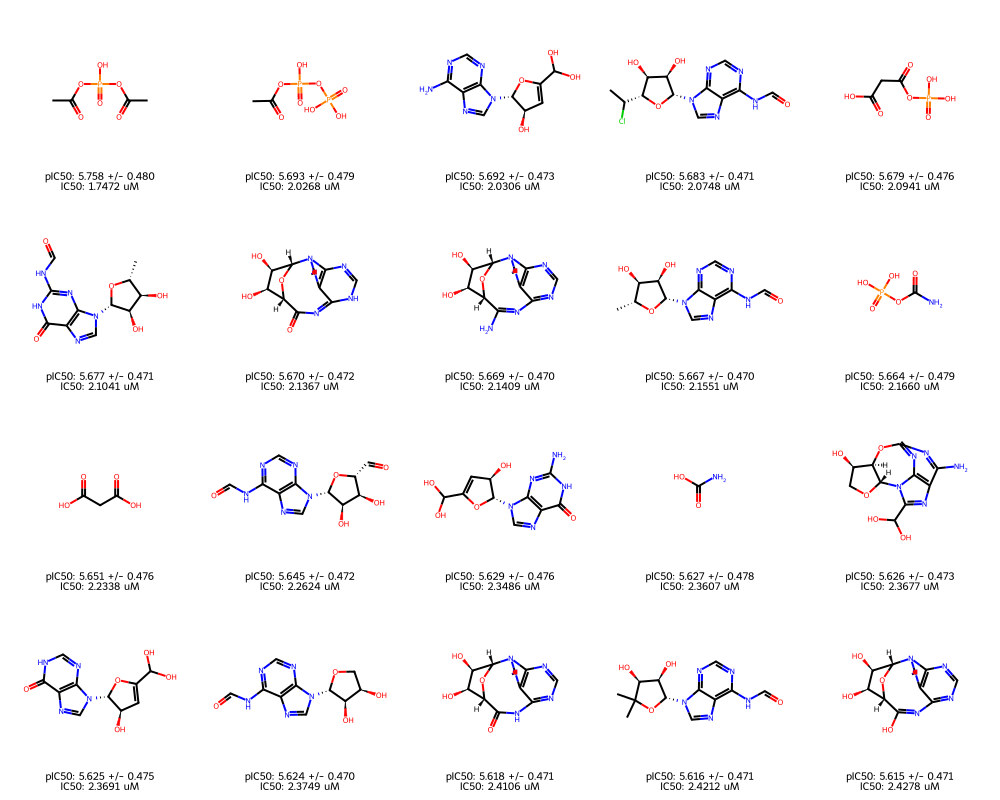

In [179]:
top20 = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [180]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = combinedEbola_allDORAnetGenerated_Antivirals[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = (
    combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.7580,0.4796,1.7472,AdenosineOnly_gen3
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.6930,0.4789,2.0268,GuanosineOnly_gen3
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.6920,0.4733,2.0306,AdenosineOnly_gen3
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.6830,0.4711,2.0748,AdenosineOnly_gen3
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.6790,0.4760,2.0941,GuanosineOnly_gen3
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.6770,0.4714,2.1041,GuanosineOnly_gen3
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.6700,0.4720,2.1367,InosineOnly_gen3
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.6690,0.4704,2.1409,AdenosineOnly_gen3
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.6670,0.4701,2.1551,AdenosineOnly_gen3
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.6640,0.4789,2.1660,AdenosineOnly_gen3


### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction_wADMET.csv')
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.columns
]

combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET = combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.shape)
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.to_csv(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.csv", index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.head()

## 4.3.1.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span> from high potency compounds

DORAnet starter: `top 20 high potency` candidates from Inosine + Guanosine + Xanthosine + Adenosine

### Import all compounds generated by `DORAnet` from `InoAdeGuoXan` with (gen=1,2,3) --> Possible `Antivirals`

In [ ]:
Top20_InoAdeGuoXan_DORAnetGenerated = pd.read_csv(resultsDir + "/DORAnet/InoAdeGuoXan/EbolaTop20_InoAdeGuoXan_DORAnet_generatedCompounds.csv", dtype=str)
print(f"Loaded {len(Top20_InoAdeGuoXan_DORAnetGenerated)} molecules")
Top20_InoAdeGuoXan_DORAnetGenerated['source_DataBase'] = 'Top20_InoAdeGuoXan'
Top20_InoAdeGuoXan_DORAnetGenerated = Top20_InoAdeGuoXan_DORAnetGenerated.rename(columns={'Generated_Compound_SMILES': 'Canonical_SMILES'})
print("Generated_Compound_SMILES columns has been renamed to Canonical_SMILES")
Top20_InoAdeGuoXan_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

# ---- training SMILES from EbolaVirusData_allDB ----
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# ---- ALSO exclude smiles already present in generated top20 set ----
generated_top20_smiles_set = set(
    combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["Canonical_SMILES"]
    .dropna().astype(str)
)

# Final exclusion set = union of both
exclusion_smiles_set = training_smiles_set | generated_top20_smiles_set

# ---- overlap check with external ----
external_canon_set = set(
    Top20_InoAdeGuoXan_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)

common_with_training = external_canon_set & training_smiles_set
common_with_generated_top20 = external_canon_set & generated_top20_smiles_set
common_with_either = common_with_training | common_with_generated_top20

print(f"Overlap (external ∩ EbolaVirusData_allDB): {len(common_with_training)}")
print(f"Overlap (external ∩ combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20): "
      f"{len(common_with_generated_top20)}")
print(f"Total overlap to remove (either set): {len(common_with_either)}")

# ---- remove rows from external that overlap with either exclusion set ----
before = len(Top20_InoAdeGuoXan_DORAnetGenerated)
Top20_InoAdeGuoXan_DORAnetGenerated = Top20_InoAdeGuoXan_DORAnetGenerated[
    ~Top20_InoAdeGuoXan_DORAnetGenerated["Canonical_SMILES"].isin(exclusion_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(Top20_InoAdeGuoXan_DORAnetGenerated)
print(f"Training/generation overlap rows removed from external: {removed_external_rows}")
print(f"Total buyable antiviral molecules for external validation after removal: "
      f"{len(Top20_InoAdeGuoXan_DORAnetGenerated)}")

Top20_InoAdeGuoXan_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Top20_InoAdeGuoXan_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Top20_InoAdeGuoXan_DORAnetGenerated.index)

Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW = pd.concat([Top20_InoAdeGuoXan_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Top20_InoAdeGuoXan_DORAnetGenerated.shape}")
print(f"New dataframe shape: {Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.csv"), index=False)
Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.copy()

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.filter(
    items=["Starter_Compound_SMILES", "Canonical_SMILES", "DORAnet_gen", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = (
    Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.csv"), index=False)
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.loc[Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.loc[Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction

### Compare the performance of newly generated compounds with starter molecules

In [ ]:
newlyGeneratedDF = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.copy()
baseDF = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.copy()

# --- ensure numeric ---
for d in (baseDF, newlyGeneratedDF):
    d["pPotency_prediction"] = pd.to_numeric(d["pPotency_prediction"], errors="coerce")
    d["pPotency_std"] = pd.to_numeric(d["pPotency_std"], errors="coerce")

# Use top 20 by pPotency_prediction (safe even if already top20)
baseDF20 = baseDF.sort_values("pPotency_prediction", ascending=False).head(20)
newlyGeneratedDF20 = newlyGeneratedDF.sort_values("pPotency_prediction", ascending=False).head(20)

# --- compare potency range (min/max) ---
potency_min_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmin()]
potency_max_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmax()]

potency_min_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmin()]
potency_max_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmax()]

min_base, min_other = potency_min_base["pPotency_prediction"], potency_min_other["pPotency_prediction"]
max_base, max_other = potency_max_base["pPotency_prediction"], potency_max_other["pPotency_prediction"]

def pct_change(new, old):
    old = float(old)
    if old == 0:
        return np.nan
    return (float(new) - old) / old * 100.0

print("Potency range comparison")
print(f"DORAnet starterDF top20:  {min_base:.3f} ± {potency_min_base['pPotency_std']:.2f} - {max_base:.3f} ± {potency_max_base['pPotency_std']:.2f}")

print(f"DORAnet newlyGeneratedDF top20: {min_other:.3f} ± {potency_min_other['pPotency_std']:.2f} - {max_other:.3f} ± {potency_max_other['pPotency_std']:.2f}")

print(f"Percent change in Min potency : {pct_change(min_other, min_base):.2f}%")
print(f"Percent change in Max potency: {pct_change(max_other, max_base):.2f}%")

# --- optional: compound-by-compound percent change (match by Canonical_SMILES) ---
if "Canonical_SMILES" in baseDF20.columns and "Canonical_SMILES" in newlyGeneratedDF20.columns:
    merged = baseDF20[["Canonical_SMILES", "pPotency_prediction"]].merge(
        newlyGeneratedDF20[["Canonical_SMILES", "pPotency_prediction"]],
        on="Canonical_SMILES",
        how="inner",
        suffixes=("_base", "_other")
    )

    # element-wise % change in log-space score (pPotency)
    merged["pct_change_pPotency_prediction"] = merged.apply(
        lambda r: pct_change(r["pPotency_prediction_other"], r["pPotency_prediction_base"]),
        axis=1
    )

    print("\nMatched compounds")
    print(f"Matched top20 compounds: {len(merged)} / 20")
    if len(merged) > 0:
        print(f"Mean % change:   {merged['pct_change_pPotency_prediction'].mean():.2f}%")
        print(f"Median % change: {merged['pct_change_pPotency_prediction'].median():.2f}%")
        print(f"Min % change:    {merged['pct_change_pPotency_prediction'].min():.2f}%")
        print(f"Max % change:    {merged['pct_change_pPotency_prediction'].max():.2f}%")

newlyGeneratedDF20 = newlyGeneratedDF20.drop(columns = ['IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI'])
newlyGeneratedDF20

## 4.3.2 Predict potency of DORAnet generated Antivirals from `Remdesivir` using ART

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) --> Possible `Antivirals`

In [ ]:
RemdesivirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Remdesivir_Pubchem/RemdesivirOnly_gen2/RemdesivirOnly_gen2.csv", dtype=str)
print(f"Loaded {len(RemdesivirOnly_DORAnetGenerated)} molecules")
RemdesivirOnly_DORAnetGenerated['source_DataBase'] = 'RemdesivirOnly_gen2'
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated.drop(columns='SourceDirectories')
RemdesivirOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) + `DORA-XGB` --> Possible `Antivirals`

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(RemdesivirOnly_DORAnetGenerated)
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated[
    ~RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(RemdesivirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(RemdesivirOnly_DORAnetGenerated)}")

RemdesivirOnly_DORAnetGenerated

### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(RemdesivirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=RemdesivirOnly_DORAnetGenerated.index)

RemdesivirOnly_DORAnetGenerated_wMACAW = pd.concat([RemdesivirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {RemdesivirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {RemdesivirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
RemdesivirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "RemdesivirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in RemdesivirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = RemdesivirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

RemdesivirOnly_DORAnetGenerated_ARTprediction = (
    RemdesivirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

RemdesivirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

RemdesivirOnly_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20 = RemdesivirOnly_DORAnetGenerated_ARTprediction.iloc[top_20_idx].copy()
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20 = RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.to_csv(os.path.join(resultsDir + "RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "RemdesivirOnly_DORAnetGenerated_wARTprediction_top20_SMILESonly.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/RemdesivirOnly_DORAnetGenerated_ARTprediction_wADMET.csv')
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.columns
]

RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.shape)
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.to_csv(resultsDir + "RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.csv", index=False)
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.head()

## 4.3.2.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span> from high potency compounds

DORAnet starter: `top 20 high potency` candidates from `Remdesivir`

### Import all compounds generated by `DORAnet` from `Remdesivir` with (gen=1,2,3) --> Possible `Antivirals`

In [ ]:
Top20_Remdesivir_DORAnetGenerated = pd.read_csv(resultsDir + "/DORAnet/Remdesivir/EbolaTop20_Remdesivir_DORAnet_generatedCompounds.csv", dtype=str)
print(f"Loaded {len(Top20_Remdesivir_DORAnetGenerated)} molecules")
Top20_Remdesivir_DORAnetGenerated['source_DataBase'] = 'Top20_Remdesivir'
Top20_Remdesivir_DORAnetGenerated = Top20_Remdesivir_DORAnetGenerated.rename(columns={'Generated_Compound_SMILES': 'Canonical_SMILES'})
print("Generated_Compound_SMILES columns has been renamed to Canonical_SMILES")
Top20_Remdesivir_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

# ---- training SMILES from EbolaVirusData_allDB ----
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# ---- ALSO exclude smiles already present in generated top20 set ----
generated_top20_smiles_set = set(
    RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["Canonical_SMILES"]
    .dropna().astype(str)
)

# Final exclusion set = union of both
exclusion_smiles_set = training_smiles_set | generated_top20_smiles_set

# ---- overlap check with external ----
external_canon_set = set(
    Top20_Remdesivir_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)

common_with_training = external_canon_set & training_smiles_set
common_with_generated_top20 = external_canon_set & generated_top20_smiles_set
common_with_either = common_with_training | common_with_generated_top20

print(f"Overlap (external ∩ EbolaVirusData_allDB): {len(common_with_training)}")
print(f"Overlap (external ∩ combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20): "
      f"{len(common_with_generated_top20)}")
print(f"Total overlap to remove (either set): {len(common_with_either)}")

# ---- remove rows from external that overlap with either exclusion set ----
before = len(Top20_Remdesivir_DORAnetGenerated)
Top20_Remdesivir_DORAnetGenerated = Top20_Remdesivir_DORAnetGenerated[
    ~Top20_Remdesivir_DORAnetGenerated["Canonical_SMILES"].isin(exclusion_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(Top20_Remdesivir_DORAnetGenerated)
print(f"Training/generation overlap rows removed from external: {removed_external_rows}")
print(f"Total buyable antiviral molecules for external validation after removal: "
      f"{len(Top20_Remdesivir_DORAnetGenerated)}")

Top20_Remdesivir_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Top20_Remdesivir_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Top20_Remdesivir_DORAnetGenerated.index)

Top20_Remdesivir_DORAnetGenerated_wMACAW = pd.concat([Top20_Remdesivir_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Top20_Remdesivir_DORAnetGenerated.shape}")
print(f"New dataframe shape: {Top20_Remdesivir_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Top20_Remdesivir_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "Top20_Remdesivir_DORAnetGenerated_wMACAW.csv"), index=False)
Top20_Remdesivir_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in Top20_Remdesivir_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Top20_Remdesivir_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
Top20_Remdesivir_DORAnetGenerated_ARTprediction = Top20_Remdesivir_DORAnetGenerated_wMACAW.copy()

Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
Top20_Remdesivir_DORAnetGenerated_ARTprediction = Top20_Remdesivir_DORAnetGenerated_ARTprediction.filter(
    items=["Starter_Compound_SMILES", "Canonical_SMILES", "DORAnet_gen", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

Top20_Remdesivir_DORAnetGenerated_ARTprediction = (
    Top20_Remdesivir_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

Top20_Remdesivir_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/Top20_Remdesivir_DORAnetGenerated_ARTprediction.csv"), index=False)
Top20_Remdesivir_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/Top20_Remdesivir_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = Top20_Remdesivir_DORAnetGenerated_ARTprediction.loc[Top20_Remdesivir_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = Top20_Remdesivir_DORAnetGenerated_ARTprediction.loc[Top20_Remdesivir_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

Top20_Remdesivir_DORAnetGenerated_ARTprediction

### Compare the performance of newly generated compounds with starter molecules

In [ ]:
newlyGeneratedDF = Top20_Remdesivir_DORAnetGenerated_ARTprediction.copy()
baseDF = RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.copy()

# --- ensure numeric ---
for d in (baseDF, newlyGeneratedDF):
    d["pPotency_prediction"] = pd.to_numeric(d["pPotency_prediction"], errors="coerce")
    d["pPotency_std"] = pd.to_numeric(d["pPotency_std"], errors="coerce")

# Use top 20 by pPotency_prediction (safe even if already top20)
baseDF20 = baseDF.sort_values("pPotency_prediction", ascending=False).head(20)
newlyGeneratedDF20 = newlyGeneratedDF.sort_values("pPotency_prediction", ascending=False).head(20)

# --- compare potency range (min/max) ---
potency_min_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmin()]
potency_max_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmax()]

potency_min_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmin()]
potency_max_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmax()]

min_base, min_other = potency_min_base["pPotency_prediction"], potency_min_other["pPotency_prediction"]
max_base, max_other = potency_max_base["pPotency_prediction"], potency_max_other["pPotency_prediction"]

def pct_change(new, old):
    old = float(old)
    if old == 0:
        return np.nan
    return (float(new) - old) / old * 100.0

print("Potency range comparison")
print(f"DORAnet starterDF top20:  {min_base:.3f} ± {potency_min_base['pPotency_std']:.2f} - {max_base:.3f} ± {potency_max_base['pPotency_std']:.2f}")

print(f"DORAnet newlyGeneratedDF top20: {min_other:.3f} ± {potency_min_other['pPotency_std']:.2f} - {max_other:.3f} ± {potency_max_other['pPotency_std']:.2f}")

print(f"Percent change in Min potency : {pct_change(min_other, min_base):.2f}%")
print(f"Percent change in Max potency: {pct_change(max_other, max_base):.2f}%")

# --- optional: compound-by-compound percent change (match by Canonical_SMILES) ---
if "Canonical_SMILES" in baseDF20.columns and "Canonical_SMILES" in newlyGeneratedDF20.columns:
    merged = baseDF20[["Canonical_SMILES", "pPotency_prediction"]].merge(
        newlyGeneratedDF20[["Canonical_SMILES", "pPotency_prediction"]],
        on="Canonical_SMILES",
        how="inner",
        suffixes=("_base", "_other")
    )

    # element-wise % change in log-space score (pPotency)
    merged["pct_change_pPotency_prediction"] = merged.apply(
        lambda r: pct_change(r["pPotency_prediction_other"], r["pPotency_prediction_base"]),
        axis=1
    )

    print("\nMatched compounds")
    print(f"Matched top20 compounds: {len(merged)} / 20")
    if len(merged) > 0:
        print(f"Mean % change:   {merged['pct_change_pPotency_prediction'].mean():.2f}%")
        print(f"Median % change: {merged['pct_change_pPotency_prediction'].median():.2f}%")
        print(f"Min % change:    {merged['pct_change_pPotency_prediction'].min():.2f}%")
        print(f"Max % change:    {merged['pct_change_pPotency_prediction'].max():.2f}%")

newlyGeneratedDF20 = newlyGeneratedDF20.drop(columns = ['IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI'])
#newlyGeneratedDF20.to_csv(os.path.join(resultsDir, "Top20_Remdesivir_DORAnetGenerated_.csv"), index=False)
newlyGeneratedDF20

## 4.3.3 Predict potency of DORAnet generated Antivirals from `Brincidofovir` using ART

### Import all compounds generated by `DORAnet` from `Brincidofovir` only (gen=2) --> Possible `Antivirals`

In [ ]:
BrincidofovirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Brincidofovir_Pubchem/BrincidofovirOnly_gen2/BrincidofovirOnly_gen2.csv", dtype=str)
print(f"Loaded {len(BrincidofovirOnly_DORAnetGenerated)} molecules")
BrincidofovirOnly_DORAnetGenerated['source_DataBase'] = 'BrincidofovirOnly_gen2'
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated.drop(columns='SourceDirectories')
BrincidofovirOnly_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(BrincidofovirOnly_DORAnetGenerated)
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated[
    ~BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(BrincidofovirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(BrincidofovirOnly_DORAnetGenerated)}")

BrincidofovirOnly_DORAnetGenerated

### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BrincidofovirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BrincidofovirOnly_DORAnetGenerated.index)

BrincidofovirOnly_DORAnetGenerated_wMACAW = pd.concat([BrincidofovirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BrincidofovirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {BrincidofovirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BrincidofovirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "BrincidofovirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in BrincidofovirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BrincidofovirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction = (
    BrincidofovirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

BrincidofovirOnly_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/BrincidofovirOnly_DORAnetGenerated_ARTprediction_wADMET.csv')
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.columns
]

BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.shape)
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.to_csv(resultsDir + "BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.csv", index=False)
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.head()

## Plot potency-toxicity panel
**All compounds generated by DORAnet**
- Inosine (DORAnet gen=3)
- Adenosine (DORAnet gen=3)
- Xanthosine (DORAnet gen=3)
- Guanosine (DORAnet gen=3)
- Remdesivir (DORAnet gen=2)
- Brincidofovir (DORAnet gen=2)

**Experimental data**
- Remdesivir
- Brincidofovir
- Favipiravir

### Split `combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET` to four individual data frames

In [ ]:
# Original dataframe:
# combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET

# Mapping: source_DataBase value -> new dataframe variable name + new label
source_map = {
    "XanthosineOnly_gen3": ("combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET", "Xanthosine"),
    "AdenosineOnly_gen3":  ("combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET", "Adenosine"),
    "InosineOnly_gen3":    ("combinedEbola_allInosineGenerated_Antivirals_wART_wADMET", "Inosine"),
    "GuanosineOnly_gen3":  ("combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET", "Guanosine"),
}

# Create split dataframes dynamically
for src_value, (df_name, renamed_label) in source_map.items():
    tmp_df = combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET[
        combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET["source_DataBase"] == src_value
    ].copy()

    # Rename source_DataBase entries
    tmp_df["source_DataBase"] = renamed_label

    # Create variable in global namespace
    globals()[df_name] = tmp_df

# check
print("Created dataframes:")
for _, (df_name, _) in source_map.items():
    print(df_name, globals()[df_name].shape)

### Get `potency` prediction from `ART`

In [ ]:
InoAdeGuoXan_SMILES_Dict = {
    "Inosine":  'C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O',
    "Adenosine": 'C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N',
    "Guanosine": 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N=C(NC2=O)N',
    "Xanthosine": 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)NC(=O)NC2=O'
}

InoAdeGuoXan_dF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": canonicalizeSmiles(smi)}
     for name, smi in InoAdeGuoXan_SMILES_Dict.items()])

# 1) Load MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, "rb") as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# 2) Transform SMILES to MACAW embeddings
macaw_embeddings = mcw.transform(InoAdeGuoXan_dF["Canonical_SMILES"])
print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# 3) Build embeddings dataframe and combine
embedding_columns = [f"MACAW_{i+1}" for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InoAdeGuoXan_dF.index)

InoAdeGuoXan_wMACAW = pd.concat([InoAdeGuoXan_dF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InoAdeGuoXan_dF.shape}")
print(f"New dataframe shape: {InoAdeGuoXan_wMACAW.shape}")
print(f"New columns added: {list(macaw_df.columns)}")

# 4) ART prediction
macawFeatureCols = [col for col in InoAdeGuoXan_wMACAW.columns if col.startswith('MACAW_')]
smiLib = InoAdeGuoXan_wMACAW[macawFeatureCols].values
mean, std = art_macaw.post_pred_stats(smiLib)

# 5) Assemble final result table
InoAdeGuoXan_wART = InoAdeGuoXan_wMACAW[["drugName", "Canonical_SMILES"]].copy()
InoAdeGuoXan_wART["pPotency_prediction"] = mean
InoAdeGuoXan_wART["pPotency_std"] = std

# 95% confidence intervals
InoAdeGuoXan_wART["pPotency_lower_95CI"] = InoAdeGuoXan_wART["pPotency_prediction"] - 1.96 * InoAdeGuoXan_wART["pPotency_std"]
InoAdeGuoXan_wART["pPotency_upper_95CI"] = InoAdeGuoXan_wART["pPotency_prediction"] + 1.96 * InoAdeGuoXan_wART["pPotency_std"]

# Convert pPotency to IC50(M)
InoAdeGuoXan_wART["IC50(M)_prediction"] = 10 ** (-InoAdeGuoXan_wART["pPotency_prediction"])
InoAdeGuoXan_wART["IC50(M)_lower_95CI"] = 10 ** (-InoAdeGuoXan_wART["pPotency_upper_95CI"])
InoAdeGuoXan_wART["IC50(M)_upper_95CI"] = 10 ** (-InoAdeGuoXan_wART["pPotency_lower_95CI"])

# sort by predicted potency
InoAdeGuoXan_wART = (
    InoAdeGuoXan_wART.sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True))

# Final dataframe
InoAdeGuoXan_wART

### Compute their ADMET profile

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=InoAdeGuoXan_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
InoAdeGuoXan_wART_wADMET = InoAdeGuoXan_wART.merge(pred, on="Canonical_SMILES", how="left")
InoAdeGuoXan_wART_wADMET

### Read experimental `potency` data of `Remdesivir, Favipiravir, Brincidofovir`

In [ ]:
ExperimentalDataDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryPotencyDict_expt = {
    "Remdesivir": [
        7.07,  # Warren et al. 2016, EBOV, primary macrophages
        6.85,  # Warren et al. 2016, EBOV, HeLa
        6.89,  # Warren et al. 2016, EBOV, HFF-1
        7.22,  # Warren et al. 2016, EBOV, HMVEC-TERT
        7.15,  # Warren et al. 2016, EBOV, Huh-7
        7.18,  # Lo et al. 2017, EBOV Mayinga-GFP reporter assay
        7.68,  # Lo et al. 2017, EBOV Mayinga-Gluc reporter assay
        7.85,  # Lo et al. 2017, EBOV Makona-ZSG reporter assay
        8.52,  # Lo et al. 2017, EBOV Makona virus titer reduction assay
        7.11,  # Radoshitzky et al. 2023, EBOV Makona, HeLa
        6.87,  # Radoshitzky et al. 2023, EBOV Mayinga, HeLa
        7.15,  # Radoshitzky et al. 2023, EBOV Kikwit, HeLa
    ],
    "Favipiravir": [4.17, 3.96],
    "Brincidofovir": [6.10, 6.18, 6.06],
}

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

queryData_expt = []
for drugName, smiles in ExperimentalDataDict.items():
    potencyValues = pd.Series(queryPotencyDict_expt[drugName], dtype="float64")
    queryData_expt.append({
        "drugName": drugName,
        "SMILES": canonicalizeSmiles(smiles),
        "pPotency_min": potencyValues.min(),
        "pPotency_max": potencyValues.max(),
        "meanpPotency": potencyValues.mean(),
        "potency_std": potencyValues.std(ddof=1),  # standard deviation
    })

ExperimentalDataDF = pd.DataFrame(queryData_expt)
ExperimentalDataDF = ExperimentalDataDF.rename (columns={'meanpPotency' :'pPotency_prediction', 'potency_std' : 'pPotency_std'})
ExperimentalDataDF = ExperimentalDataDF.drop(columns=["pPotency_min", "pPotency_max"])
ExperimentalDataDF = ExperimentalDataDF.rename(columns={'SMILES' : 'Canonical_SMILES'})
ExperimentalDataDF

### Compute their ADMET profile

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=ExperimentalDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
ExperimentalDataDF_wADMET = ExperimentalDataDF.merge(pred, on="Canonical_SMILES", how="left")
ExperimentalDataDF_wADMET

In [ ]:
InoAdeGuoXan_queryAntivirals_dF = pd.concat([queryAntiviralsDF_wART_wADMET, InoAdeGuoXan_wART_wADMET], ignore_index=True)
InoAdeGuoXan_queryAntivirals_dF = InoAdeGuoXan_queryAntivirals_dF.drop_duplicates(subset=["Canonical_SMILES"]).reset_index(drop=True)
InoAdeGuoXan_queryAntivirals_dF

### Plot potency of all the compounds

- x-axis: pPotency_prediction
- y-axis: drug candidate names
- Individual predicted as larger circles
- Experimental as stars (*) with pPotency_std
- Top-20 overlays as cross marks
- thinning ONLY for Remdesivir-generated

In [ ]:
# Shared config
potencyCols = ["pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI"]
toxicityMeta = [
    ("AMES", "lowerBetter"), ("Carcinogens_Lagunin", "lowerBetter"), ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"), ("Skin_Reaction", "lowerBetter"), ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"), ("NR-AR-LBD", "lowerBetter"), ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"), ("NR-Aromatase", "lowerBetter"), ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"), ("NR-PPAR-gamma", "lowerBetter"), ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"), ("SR-HSE", "lowerBetter"), ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]
toxicityCols = [x for x, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols
toxDesCols = [f"{ep}_des" for ep, _ in toxicityMeta]



# Utilitiy functions
def prepareDF(df, datasetLabel):
    df = df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"Canonical_SMILES": "SMILES"})
    elif "smiles" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"smiles": "SMILES"})

    if "drugName" not in df.columns:
        df["drugName"] = df["Drug_Type"] if "Drug_Type" in df.columns else df.get("SMILES", np.nan)

    df["datasetLabel"] = datasetLabel
    return df


def ensureCols(df, colList):
    df = df.copy()
    for c in colList:
        if c not in df.columns:
            df[c] = np.nan
    return df[colList].copy()


def robustIQR(series):
    arr = pd.to_numeric(series, errors="coerce").dropna()
    if len(arr) < 5:
        return np.nan
    q25, q75 = np.percentile(arr, [25, 75])
    return q75 - q25


def getSortedRefArray(series):
    arr = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    return np.sort(arr)


def higherBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def lowerBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(1.0 - pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def weightedGeoMeanSeries(df, valueCols, weightSeries):
    val = df[valueCols].to_numpy(dtype=float)
    w = np.asarray(weightSeries, dtype=float)
    out = np.full(val.shape[0], np.nan)
    for i in range(val.shape[0]):
        row = val[i]
        m = np.isfinite(row)
        if m.sum() == 0:
            continue
        rowVal = np.clip(row[m], 1e-6, 1.0)
        rowW = w[m]
        out[i] = np.exp(np.sum(rowW * np.log(rowVal)) / np.sum(rowW))
    return pd.Series(out, index=df.index)


def thinForDisplay(df, xCol, yCol, nXBins=100, nYBins=100, denseThreshold=4, keepFraction=0.20, randomState=42):
    plotDF = df[[xCol, yCol]].dropna().copy()
    if len(plotDF) == 0:
        return df.iloc[0:0].copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()
    if xMin == xMax: xMax += 1e-9
    if yMin == yMax: yMax += 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)
    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    kept = []
    for _, g in plotDF.groupby(["xBin", "yBin"], dropna=False):
        n = len(g)
        if n <= denseThreshold:
            kept.extend(g.index.tolist())
        else:
            nk = max(1, int(np.ceil(n * keepFraction)))
            kept.extend(rng.choice(g.index.to_numpy(), size=nk, replace=False).tolist())

    return df.loc[sorted(set(kept))].copy()


def select_top20_group(df_group):
    df2 = df_group.dropna(subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]).copy()
    if len(df2) == 0:
        return df2.iloc[0:0].copy(), np.nan, np.nan

    x_cut = df2["pPotency_prediction"].quantile(0.75)
    y_cut = df2["coreToxicityScore"].quantile(0.25)

    opt = df2[(df2["pPotency_prediction"] >= x_cut) & (df2["coreToxicityScore"] <= y_cut)].copy()
    if len(opt) == 0:
        return opt, x_cut, y_cut

    opt["OverallPriority2D"] = np.sqrt(opt["PotencyDesRaw"] * opt["ToxicitySafety"])
    top20 = opt.sort_values(
        by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
        ascending=[False, False, True]
    ).head(20).copy()
    return top20, x_cut, y_cut


def build_scored_data(ref_raw, generated_raw, expt_raw):
    ref = prepareDF(ref_raw, "Reference")
    expt = prepareDF(expt_raw, "Expt")
    generated = {}
    for source_name, source_df in generated_raw.items():
        t = prepareDF(source_df, "Generated")
        t["candidateSource"] = source_name
        generated[source_name] = t

    refScoreDF = ensureCols(ref, keepCols)
    candScoreMap = {k: ensureCols(v, keepCols) for k, v in generated.items()}
    exptScoreDF = ensureCols(expt, keepCols)

    for c in potencyCols + toxicityCols:
        refScoreDF[c] = pd.to_numeric(refScoreDF[c], errors="coerce")
        for k in candScoreMap:
            candScoreMap[k][c] = pd.to_numeric(candScoreMap[k][c], errors="coerce")
        exptScoreDF[c] = pd.to_numeric(exptScoreDF[c], errors="coerce")

    refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
    toxCorrDF = refToxDF.corr().abs()

    weightRows = []
    for endpointName, directionName in toxicityMeta:
        iqrVal = robustIQR(refToxDF[endpointName])
        informativeness = 1.0 / (iqrVal + 1e-6) if pd.notna(iqrVal) else 1.0
        others = [x for x in toxicityCols if x != endpointName]
        meanAbsCorr = toxCorrDF.loc[endpointName, others].dropna().mean() if (endpointName in toxCorrDF.index and len(others) > 0) else np.nan
        uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        weightRows.append({"endpoint": endpointName, "direction": directionName, "rawWeight": informativeness * uniqueness})

    toxWeightDF = pd.DataFrame(weightRows)
    toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

    def scoreCandidateDF(df):
        df = df.copy()
        for endpointName, directionName in toxicityMeta:
            desCol = f"{endpointName}_des"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) if directionName == "higherBetter" else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        df["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], df["pPotency_prediction"])
        df["ToxicitySafety"] = weightedGeoMeanSeries(df, toxDesCols, toxWeightDF["finalWeight"])
        df["coreToxicityScore"] = 1.0 - df["ToxicitySafety"]
        return df

    scoredCandMap = {k: scoreCandidateDF(v) for k, v in candScoreMap.items()}
    exptScoreDF = scoreCandidateDF(exptScoreDF)
    return refScoreDF, scoredCandMap, exptScoreDF

In [ ]:
#----------------------
# Potency only plot
#----------------------
refDrugbankDF = drugBankDrug_FDAapproved_Antiviral_wART_wADMET.copy()
generated_dict_raw_1 = {
    "Xanthosine-generated": combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET.copy(),
    "Adenosine-generated":  combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET.copy(),
    "Inosine-generated":    combinedEbola_allInosineGenerated_Antivirals_wART_wADMET.copy(),
    "Guanosine-generated":  combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET.copy(),
    "Remdesivir-generated": RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.copy(),
    "Brincidofovir-generated": BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.copy(),
    "Individual": InoAdeGuoXan_queryAntivirals_dF.copy(),
}
Expt_Candidate = ExperimentalDataDF_wADMET.copy()

_, scoredCandMap1, exptScoreDF1 = build_scored_data(refDrugbankDF, generated_dict_raw_1, Expt_Candidate)

top20_remdesivir, xCut_rem, yCut_rem = select_top20_group(scoredCandMap1["Remdesivir-generated"])
xaig_pool_1 = pd.concat([
    scoredCandMap1["Xanthosine-generated"],
    scoredCandMap1["Adenosine-generated"],
    scoredCandMap1["Inosine-generated"],
    scoredCandMap1["Guanosine-generated"],
], ignore_index=True)
top20_xaig, xCut_xaig, yCut_xaig = select_top20_group(xaig_pool_1)

fig, ax = plt.subplots(figsize=(10.5, 6.8))

# KEEP EXACTLY AS PROVIDED
base_color_map = {
    "Xanthosine": "#E41A1C",
    "Adenosine": "#377EB8",
    "Guanosine": "#4DAF4A",
    "Inosine": "#984EA3",
    "Remdesivir": "#FF7F00",
    "Favipiravir": "#A65628",
    "Brincidofovir": "#F781BF",
    "Molnupiravir": "#17BECF",
}
source_to_base = {
    "Xanthosine-generated": "Xanthosine",
    "Adenosine-generated": "Adenosine",
    "Inosine-generated": "Inosine",
    "Guanosine-generated": "Guanosine",
    "Remdesivir-generated": "Remdesivir",
    "Brincidofovir-generated": "Brincidofovir",
}
candidate_order = ["Xanthosine", "Adenosine", "Guanosine", "Inosine", "Remdesivir", "Favipiravir", "Brincidofovir", "Molnupiravir"]
legend_name_map = {
    "Xanthosine-generated": "Xanthosine-generated (gen=3)",
    "Adenosine-generated":  "Adenosine-generated (gen=3)",
    "Guanosine-generated":  "Guanosine-generated (gen=3)",
    "Inosine-generated":    "Inosine-generated (gen=3)",
    "Remdesivir-generated": "Remdesivir-generated (gen=2)",
    "Brincidofovir-generated": "Brincidofovir-generated (gen=2)",
}

ypos = {name: i for i, name in enumerate(candidate_order)}
rng = np.random.default_rng(123)

for source_name, source_df in scoredCandMap1.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    if source_name == "Remdesivir-generated":
        src_plot_df = thinForDisplay(src_plot_df, "pPotency_prediction", "coreToxicityScore",
                                     nXBins=100, nYBins=100, denseThreshold=4, keepFraction=0.20, randomState=42)

    base_name = source_to_base[source_name]
    y0 = ypos.get(base_name, None)
    if y0 is None:
        continue
    yj = y0 + rng.normal(0, 0.06, len(src_plot_df))
    c = base_color_map.get(base_name, "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], yj, s=14, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap1:
    individualDF = scoredCandMap1["Individual"].dropna(subset=["drugName", "pPotency_prediction"])\
                                               .drop_duplicates(subset=["drugName", "SMILES"]).copy()
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        if dname not in ypos:
            continue
        c = base_color_map.get(dname, "black")
        ax.scatter(row["pPotency_prediction"], ypos[dname], marker="o", s=150, color=c,
                   edgecolors="black", linewidths=0.95, alpha=0.98, label=f"{dname} (predicted)", zorder=6)

exptPlotDF1 = exptScoreDF1.dropna(subset=["drugName", "pPotency_prediction"])\
                          .drop_duplicates(subset=["drugName", "SMILES"]).copy()
for _, row in exptPlotDF1.iterrows():
    dname = row["drugName"]
    if dname not in ypos:
        continue
    c = base_color_map.get(dname, "black")
    yy = ypos[dname] + 0.12
    ax.scatter(row["pPotency_prediction"], yy, marker="*", s=190, color=c, edgecolors="black",
               linewidths=0.9, alpha=0.98, label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], yy, xerr=float(row["pPotency_std"]), fmt="none",
                    ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Drug candidates")
ax.set_yticks(range(len(candidate_order)))
ax.set_yticklabels(candidate_order)
ax.invert_yaxis()
ax.yaxis.grid(False)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=1)

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotencyOnly.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotencyOnly.png"), format="png", dpi=600)
plt.show()

### Plot potency-toxicity together for all the generated compounds

In [ ]:
generated_dict_raw_2 = {
    "Xanthosine-generated": combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET.copy(),
    "Adenosine-generated":  combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET.copy(),
    "Inosine-generated":    combinedEbola_allInosineGenerated_Antivirals_wART_wADMET.copy(),
    "Guanosine-generated":  combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET.copy(),
    "Individual": InoAdeGuoXan_queryAntivirals_dF.copy(),
}

_, scoredCandMap2, exptScoreDF2 = build_scored_data(refDrugbankDF, generated_dict_raw_2, Expt_Candidate)

xaig_pool_2 = pd.concat([
    scoredCandMap2["Xanthosine-generated"],
    scoredCandMap2["Adenosine-generated"],
    scoredCandMap2["Inosine-generated"],
    scoredCandMap2["Guanosine-generated"],
], ignore_index=True)
top20_xaig, xCut_xaig, yCut_xaig = select_top20_group(xaig_pool_2)

fig, ax = plt.subplots(figsize=(9.5, 6.8))

# KEEP EXACTLY AS PROVIDED
base_color_map = {
    "Xanthosine":    "magenta",
    "Adenosine":    "orange",
    "Guanosine":    "purple",
    "Inosine":      "red",
    "Remdesivir":   "#F781BF",
    "Favipiravir":  "#999999",
    "Brincidofovir":"#BCBD22",
    "Molnupiravir": "gray",
}
source_to_base = {
    "Xanthosine-generated": "Xanthosine",
    "Adenosine-generated": "Adenosine",
    "Inosine-generated": "Inosine",
    "Guanosine-generated": "Guanosine",
}
legend_name_map = {
    "Xanthosine-generated": "Xanthosine-generated (gen=3)",
    "Adenosine-generated": "Adenosine-generated (gen=3)",
    "Guanosine-generated": "Guanosine-generated (gen=3)",
    "Inosine-generated": "Inosine-generated (gen=3)",
    "Xanthosine (predicted)": "Xanthosine (pred.)",
    "Adenosine (predicted)": "Adenosine (pred.)",
    "Guanosine (predicted)": "Guanosine (pred.)",
    "Inosine (predicted)": "Inosine (pred.)",
    "Remdesivir (predicted)": "Remdesivir (pred.)",
    "Favipiravir (predicted)": "Favipiravir (pred.)",
    "Brincidofovir (predicted)": "Brincidofovir (pred.)",
    "Molnupiravir (predicted)": "Molnupiravir (pred.)",
    "Remdesivir (expt.)": "Remdesivir (expt.)",
    "Favipiravir (expt.)": "Favipiravir (expt.)",
    "Brincidofovir (expt.)": "Brincidofovir (expt.)",
    "Top 20 XAIG-generated": "Top 20 XAIG-generated",
}

for source_name, source_df in scoredCandMap2.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    c = base_color_map.get(source_to_base.get(source_name, "gray"), "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], src_plot_df["coreToxicityScore"],
               s=14, alpha=0.35, color=c, label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap2:
    individualDF = scoredCandMap2["Individual"].dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])\
                                               .drop_duplicates(subset=["drugName", "SMILES"]).copy()
    skip_pred_names = {"Remdesivir", "Favipiravir", "Brincidofovir", "Molnupiravir"}
    individualDF = individualDF[~individualDF["drugName"].isin(skip_pred_names)].copy()
    ind_order = ["Xanthosine", "Adenosine", "Guanosine", "Inosine"]
    individualDF["order"] = individualDF["drugName"].map({n: i for i, n in enumerate(ind_order)})
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")

    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        c = base_color_map.get(dname, "black")
        raw_label = f"{dname} (predicted)"
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"], marker="o", s=150, color=c,
                   edgecolors="black", linewidths=0.95, alpha=0.98,
                   label=legend_name_map.get(raw_label, raw_label), zorder=6)

exptPlotDF2 = exptScoreDF2.dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])\
                          .drop_duplicates(subset=["drugName", "SMILES"]).copy()
for _, row in exptPlotDF2.iterrows():
    dname = row["drugName"]
    c = base_color_map.get(dname, "black")
    raw_label = f"{dname} (expt.)"
    ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"], marker="*", s=190, color=c,
               edgecolors="black", linewidths=0.9, alpha=0.98,
               label=legend_name_map.get(raw_label, raw_label), zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"], xerr=float(row["pPotency_std"]),
                    fmt="none", ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

if len(top20_xaig) > 0:
    ax.errorbar(
        top20_xaig["pPotency_prediction"],
        top20_xaig["coreToxicityScore"],
        xerr=pd.to_numeric(top20_xaig["pPotency_std"], errors="coerce").fillna(0.0).values,
        fmt="x", color="green", ecolor="green", elinewidth=1.2, capsize=3, capthick=1.2,
        markersize=9, markeredgewidth=1.8, alpha=0.95,
        label=legend_name_map.get("Top 20 XAIG-generated", "Top 20 XAIG-generated")
    )

cutoff_report = pd.DataFrame([
    {"Group": "XAIG", "Metric": "pPotency cutoff", "Value": xCut_xaig},
    {"Group": "XAIG", "Metric": "toxicity cutoff", "Value": yCut_xaig},
])
print("\nCutoff limits:")
print(cutoff_report.to_string(index=False, float_format=lambda x: f"{x:.2f}" if pd.notna(x) else "NaN"))

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")
ax.set_ylim(0, 1.05)
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
ax.grid(axis="x", linestyle="--", linewidth=1, alpha=1)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity.png"), format="png", dpi=600)
plt.show()

## 4.3 Predict potency of `All buyable` Antivirals using ART

In [ ]:
# Load external buyable antivirals
combinedEbolaVirus_all_Buyable_AntiVirals = pd.read_csv(resultsDir + "/All_Buyable_AntiVirals.csv")
print(f"Total buyable antiviral molecules before removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals)}")
'''
# Canonicalize external SMILES
combinedEbolaVirus_all_Buyable_AntiVirals = combinedEbolaVirus_all_Buyable_AntiVirals.copy()
combinedEbolaVirus_all_Buyable_AntiVirals["Canonical_SMILES"] = combinedEbolaVirus_all_Buyable_AntiVirals["SMILES"].apply(canonicalizeSmiles)
combinedEbolaVirus_all_Buyable_AntiVirals = combinedEbolaVirus_all_Buyable_AntiVirals.filter(
    items=['Canonical_SMILES', 'source_DataBase']
)
combinedEbolaVirus_all_Buyable_AntiVirals.to_csv(resultsDir + "/All_Buyable_AntiVirals.csv", index=False)
'''


# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    combinedEbolaVirus_all_Buyable_AntiVirals["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(combinedEbolaVirus_all_Buyable_AntiVirals)
combinedEbolaVirus_all_Buyable_AntiVirals = combinedEbolaVirus_all_Buyable_AntiVirals[
    ~combinedEbolaVirus_all_Buyable_AntiVirals["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(combinedEbolaVirus_all_Buyable_AntiVirals)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals)}")

combinedEbolaVirus_all_Buyable_AntiVirals

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbolaVirus_all_Buyable_AntiVirals['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbolaVirus_all_Buyable_AntiVirals.index)

combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW = pd.concat([combinedEbolaVirus_all_Buyable_AntiVirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbolaVirus_all_Buyable_AntiVirals.shape}")
print(f"New dataframe shape: {combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.to_csv(os.path.join(resultsDir, "combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW

In [ ]:
macawFeatureCols = [col for col in combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'] = mean
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'])
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = (
    combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.to_csv(os.path.join(resultsDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.loc[combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.loc[combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction,
    feat_df=combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20 = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.iloc[top_20_idx].copy()
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20 = combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = combinedEbolaVirus_all_Buyable_AntiVirals[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20 = (
    combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

combinedEbolaVirus_all_Buyable_AntiVirals_wARTprediction_top20

## 4.5 Import all `Inosine Similarstructures` compounds generated by `DORAnet` --> Possible `Antivirals`

In [ ]:
InosineSimilarStructures_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Inosine_Pubchem/InosineSimilarstructures/InosineSimilarstructures_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(InosineSimilarStructures_DORAnetGenerated)} molecules")
InosineSimilarStructures_DORAnetGenerated['source_DataBase'] = 'InosineSimilarStructures_gen3'
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated.rename(columns={'SMILES':'Canonical_SMILES'})
InosineSimilarStructures_DORAnetGenerated.to_csv(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated

### Read predicted `ADMET profile` of all `InosineSimilarStructures_DORAnetGenerated` generated antibiotics

In [ ]:
InosineSimilarStructures_DORAnetGenerated_wADMET = pd.read_csv(resultsDir + '/ART_MACAW/ADMET_AI/InosineSimilarStructures_DORAnetGenerated_wADMET.csv')
InosineSimilarStructures_DORAnetGenerated_wADMET

### Check how many common `SMILES` are presents in training set

In [ ]:
# helper to validate SMILES
def is_valid_smiles(s):
    if pd.isna(s) or s is None:
        return False
    return Chem.MolFromSmiles(str(s)) is not None

# Training canonical SMILES set (keep only valid SMILES)
training_smiles = EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
training_smiles_set = set(s for s in training_smiles if is_valid_smiles(s))

# Remove invalid SMILES from external first
before_ext = len(InosineSimilarStructures_DORAnetGenerated)
valid_mask = InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].apply(is_valid_smiles)
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated[valid_mask].reset_index(drop=True)
print(f"Removed invalid external SMILES: {before_ext - len(InosineSimilarStructures_DORAnetGenerated)}")

# Overlap check (now only valid)
external_canon_set = set(InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str))
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove external rows that are present in training
before = len(InosineSimilarStructures_DORAnetGenerated)
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated[
    ~InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(InosineSimilarStructures_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {removed_external_rows}")
print(f"Total external molecules after removing training overlap: {len(InosineSimilarStructures_DORAnetGenerated)}")

InosineSimilarStructures_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(InosineSimilarStructures_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InosineSimilarStructures_DORAnetGenerated.index)

InosineSimilarStructures_DORAnetGenerated_wMACAW = pd.concat([InosineSimilarStructures_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InosineSimilarStructures_DORAnetGenerated.shape}")
print(f"New dataframe shape: {InosineSimilarStructures_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
InosineSimilarStructures_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_wMACAW.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in InosineSimilarStructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = InosineSimilarStructures_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# --- Batched post_pred_stats for huge datasets ---
batch_size = 100000
n = len(smiLib)

means, stds = [], []
for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    mean_b, std_b = art_macaw.post_pred_stats(smiLib[start:end])
    means.append(np.asarray(mean_b))
    stds.append(np.asarray(std_b))
    print(f"Processed {end}/{n}")

mean = np.concatenate(means, axis=0)
std  = np.concatenate(stds, axis=0)

assert len(mean) == len(InosineSimilarStructures_DORAnetGenerated_wMACAW), "Mean/std length mismatch"

# --- Build results ---
InosineSimilarStructures_DORAnetGenerated_ARTprediction = (
    InosineSimilarStructures_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()
)

InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"] = mean
InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_std"] = std

InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_lower_95CI"] = mean - 1.96 * std
InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_upper_95CI"] = mean + 1.96 * std

InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_prediction"] = 10 ** (-mean)
InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_lower_95CI"] = 10 ** (
    -InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_upper_95CI"]
)
InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_upper_95CI"] = 10 ** (
    -InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_lower_95CI"]
)

# Select columns
InosineSimilarStructures_DORAnetGenerated_ARTprediction = InosineSimilarStructures_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase",
           "pPotency_prediction", "pPotency_std",
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

# Save
csv_path = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprediction.csv")
InosineSimilarStructures_DORAnetGenerated_ARTprediction.to_csv(csv_path, index=False)

smiles_path = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprediction_SMILES.csv")
InosineSimilarStructures_DORAnetGenerated_ARTprediction[["Canonical_SMILES"]].to_csv(smiles_path, index=False)

# Print potency range (prediction ± std at min/max rows)
row_min = InosineSimilarStructures_DORAnetGenerated_ARTprediction.loc[
    InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()
]
row_max = InosineSimilarStructures_DORAnetGenerated_ARTprediction.loc[
    InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()
]

print(
    f"Predicted potency range: {row_min['pPotency_prediction']:.3f} ± {row_min['pPotency_std']:.2f} - "
    f"{row_max['pPotency_prediction']:.3f} ± {row_max['pPotency_std']:.2f}"
)

InosineSimilarStructures_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = InosineSimilarStructures_DORAnetGenerated_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20 = InosineSimilarStructures_DORAnetGenerated_ARTprediction.iloc[top_20_idx].copy()
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20 = InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.to_csv(os.path.join(resultsDir + "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20_SMILESonly.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

# How structurally close are the `DORAnet generated` validation compounds with the model `training` compounds?

In [ ]:
%%time

# -----------------------------
# User settings
# -----------------------------
smilesCol = "Canonical_SMILES"
randomSeed = 42
fpRadius = 2
fpBits = 2048

# Training selection
nTrainingToUse = None
trainingSortCol = "pPotency"
trainingSortAscending = False

# External selection
nExternalToUse = 5000   # selected from EACH external dataframe; reduce if MDS is slow

# Options:
#   "topPotency"        = top predicted-potency candidates
#   "random"            = random candidates
#   "diverse"           = chemically diverse candidates
#   "topPotencyDiverse" = top predicted-potency pool, then diverse subset
externalSelectionMode = "diverse"

externalSortCol = "pPotency_prediction"
externalSortAscending = False
topPotencyPoolSize = 10000

# Plot settings
savePlots = True

# -----------------------------
# External datasets to compare
# -----------------------------
externalDatasetDict = {
    "DORAnet generated antivirals": {
        "DF": combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.copy(),
        "color": "blue",
        "marker": "+",
    },
    "Remdesivir-only DORAnet": {
        "DF": RemdesivirOnly_DORAnetGenerated_ARTprediction.copy(),
        "color": "red",
        "marker": "+",
    },
    "Buyable antivirals": {
        "DF": combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.copy(),
        "color": "green",
        "marker": "+",
    },
}

# -----------------------------
# Helper: select all, top-N, or random-N molecules
# -----------------------------
def selectMolecules(DF, nToUse=None, sortCol=None, ascending=False, randomSeed=42):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if sortCol is not None and sortCol in DF.columns:
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    return DF.sample(n=nToUse, random_state=randomSeed).copy()


# -----------------------------
# Helper: diversity-aware MaxMin selection
# -----------------------------
def selectDiverseMoleculesByMaxMin(DF, fpCol="fp", nToUse=1000, randomSeed=42):
    """
    Selects a chemically diverse subset using RDKit MaxMinPicker.
    This spreads molecules across Morgan/Tanimoto chemical space.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    fps = list(DF[fpCol])
    picker = MaxMinPicker()

    selectedIdx = list(
        picker.LazyBitVectorPick(
            fps,
            len(fps),
            nToUse,
            seed=randomSeed
        )
    )

    return DF.iloc[selectedIdx].copy()


def selectExternalCandidates(
    DF,
    mode="diverse",
    nToUse=1000,
    sortCol="pPotency_prediction",
    ascending=False,
    topPotencyPoolSize=10000,
    randomSeed=42
):
    """
    Select external candidates using topPotency, random, diverse, or topPotencyDiverse.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if mode == "topPotency":
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    if mode == "random":
        return DF.sample(n=nToUse, random_state=randomSeed).copy()

    if mode == "diverse":
        return selectDiverseMoleculesByMaxMin(
            DF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    if mode == "topPotencyDiverse":
        if sortCol not in DF.columns:
            raise ValueError(f"{sortCol} not found in external dataframe.")

        poolSize = min(topPotencyPoolSize, len(DF))
        potencyPoolDF = DF.sort_values(sortCol, ascending=ascending).head(poolSize).copy()

        return selectDiverseMoleculesByMaxMin(
            potencyPoolDF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    raise ValueError(f"Unknown externalSelectionMode: {mode}")


# -----------------------------
# Prepare training dataset
# -----------------------------
trainingDF = EbolaVirusData_allDB.copy()
trainingDF["dataSet"] = "Training"

# Use Canonical_SMILES directly; only check RDKit validity
trainingDF["mol"] = trainingDF[smilesCol].apply(
    lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
)

trainingDF = trainingDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

# Morgan fingerprint generator
morganGenerator = rdFingerprintGenerator.GetMorganGenerator(
    radius=fpRadius,
    fpSize=fpBits
)

trainingDF["fp"] = trainingDF["mol"].apply(morganGenerator.GetFingerprint)

trainingDF = selectMolecules(
    trainingDF,
    nToUse=nTrainingToUse,
    sortCol=trainingSortCol,
    ascending=trainingSortAscending,
    randomSeed=randomSeed
)

print(f"Selected training molecules: {len(trainingDF)}")

# -----------------------------
# Prepare and select all external datasets
# -----------------------------
selectedExternalDFList = []

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = externalInfo["DF"].copy()
    tmpDF["dataSet"] = externalName

    tmpDF["mol"] = tmpDF[smilesCol].apply(
        lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
    )

    tmpDF = tmpDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()
    tmpDF["fp"] = tmpDF["mol"].apply(morganGenerator.GetFingerprint)

    tmpDF = selectExternalCandidates(
        tmpDF,
        mode=externalSelectionMode,
        nToUse=nExternalToUse,
        sortCol=externalSortCol,
        ascending=externalSortAscending,
        topPotencyPoolSize=topPotencyPoolSize,
        randomSeed=randomSeed
    )

    overlapSmiles = set(trainingDF[smilesCol]).intersection(set(tmpDF[smilesCol]))

    print(f"{externalName}: selected molecules = {len(tmpDF)}")
    print(f"{externalName}: exact overlap with training = {len(overlapSmiles)}")

    selectedExternalDFList.append(tmpDF)

externalAllDF = pd.concat(selectedExternalDFList, ignore_index=True).copy()

print(f"Total selected external molecules: {len(externalAllDF)}")
print(f"External selection mode: {externalSelectionMode}")

# -----------------------------
# Potency distribution plot
# -----------------------------
trainingPotencyCol = "pPotency"
externalPotencyCol = "pPotency_prediction"

trainingPotency = pd.to_numeric(trainingDF[trainingPotencyCol], errors="coerce").dropna()

allPotencyList = [trainingPotency]

for externalName in externalDatasetDict.keys():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()
    allPotencyList.append(tmpPotency)

allPotency = pd.concat(allPotencyList, ignore_index=True)
potencyBins = np.linspace(allPotency.min(), allPotency.max(), 25)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    trainingPotency,
    bins=potencyBins,
    alpha=0.8,
    color="orange",
    label=f"Training set, n={len(trainingPotency)}"
)

for externalName, externalInfo in externalDatasetDict.items():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()

    ax.hist(
        tmpPotency,
        bins=potencyBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpPotency)}"
    )

ax.set_xlabel("Potency / predicted potency")
ax.set_ylabel("Number of molecules")
ax.set_title("Potency distribution: training vs external validation datasets")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + "potency_distribution_all_external_sets.png", dpi=600)

plt.show()

# -----------------------------
# Quantify distance: each external molecule -> nearest training molecule
# -----------------------------
trainingFps = list(trainingDF["fp"])
nearestRows = []

for _, externalRow in externalAllDF.iterrows():
    similarities = np.array(DataStructs.BulkTanimotoSimilarity(externalRow["fp"], trainingFps))
    bestIdx = int(np.argmax(similarities))
    bestSimilarity = float(similarities[bestIdx])
    nearestTrainingRow = trainingDF.iloc[bestIdx]

    nearestRows.append({
        "External_Source": externalRow["dataSet"],
        "External_Rank": externalRow.get("Rank", np.nan),
        "External_SMILES": externalRow[smilesCol],
        "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
        "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
        "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

        "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
        "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
        "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
        "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

        "Max_Tanimoto_to_training": bestSimilarity,
        "Tanimoto_distance_to_training": 1.0 - bestSimilarity
    })

nearestNeighborDF = pd.DataFrame(nearestRows).sort_values(
    ["External_Source", "Max_Tanimoto_to_training"],
    ascending=[True, False]
)

nearestNeighborDF["Chemical_space_category"] = pd.cut(
    nearestNeighborDF["Max_Tanimoto_to_training"],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=["Far from training set", "Moderately close", "Close to training set"]
)

print("Nearest-neighbor summary by external source:")
display(
    nearestNeighborDF
    .groupby(["External_Source", "Chemical_space_category"], observed=False)
    .size()
    .reset_index(name="Number_of_molecules")
)

# -----------------------------
# Build MDS embedding using training + all selected external datasets
# Warning: all-vs-all MDS can become slow if total selected molecules is large
# -----------------------------
plotDF = pd.concat([trainingDF, externalAllDF], ignore_index=True).copy()
plotFps = list(plotDF["fp"])

print(f"Total molecules used in MDS plot: {len(plotDF)}")

distanceMatrix = np.zeros((len(plotFps), len(plotFps)), dtype=np.float32)

for i, fp in enumerate(plotFps):
    distanceMatrix[i, :] = 1.0 - np.array(DataStructs.BulkTanimotoSimilarity(fp, plotFps))

mdsModel = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=randomSeed,
    n_init=4,
    max_iter=500
)

embedding = mdsModel.fit_transform(distanceMatrix)

plotDF["MDS1"] = embedding[:, 0]
plotDF["MDS2"] = embedding[:, 1]

# -----------------------------
# Plot chemical embedding space with requested colors/symbols
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 7))

trainingMask = plotDF["dataSet"] == "Training"

# Training: red dot
ax.scatter(
    plotDF.loc[trainingMask, "MDS1"],
    plotDF.loc[trainingMask, "MDS2"],
    s=22,
    alpha=0.8,
    color="orange",
    marker="o",
    label=f"Training set (n={trainingMask.sum()})"
)

# External datasets: + marker with specified colors
for externalName, externalInfo in externalDatasetDict.items():
    externalMask = plotDF["dataSet"] == externalName

    ax.scatter(
        plotDF.loc[externalMask, "MDS1"],
        plotDF.loc[externalMask, "MDS2"],
        s=70,
        alpha=0.85,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={externalMask.sum()})"
    )

ax.set_xlabel("MDS1 from Morgan/Tanimoto distance")
ax.set_ylabel("MDS2 from Morgan/Tanimoto distance")
ax.set_title("Training vs multiple external validation datasets in chemical embedding space")
ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])

if savePlots:
    plt.savefig(resultsDir + "structural_similarity_embeddings.png", dpi=600)

plt.show()

# -----------------------------
# Plot nearest-neighbor similarity distribution by external source
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

similarityBins = np.linspace(0, 1, 21)

for externalName, externalInfo in externalDatasetDict.items():
    tmpSimilarity = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName,
        "Max_Tanimoto_to_training"
    ]

    ax.hist(
        tmpSimilarity,
        bins=similarityBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpSimilarity)}"
    )

ax.axvline(0.50, linestyle="--", linewidth=1, c='k')

ax.set_xlabel("Maximum Tanimoto similarity to selected training set")
ax.set_ylabel("Number of external molecules")
ax.set_title("Nearest training-set similarity by external dataset")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + "nearest_neighbor_similarity_distribution.png", dpi=600)

plt.show()


# -----------------------------
# Plot predicted potency vs maximum Tanimoto similarity to training set
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName
    ].copy()

    tmpDF["External_pPotency_prediction"] = pd.to_numeric(
        tmpDF["External_pPotency_prediction"],
        errors="coerce"
    )

    tmpDF["Max_Tanimoto_to_training"] = pd.to_numeric(
        tmpDF["Max_Tanimoto_to_training"],
        errors="coerce"
    )

    tmpDF = tmpDF.dropna(
        subset=["External_pPotency_prediction", "Max_Tanimoto_to_training"]
    )

    ax.scatter(
        tmpDF["External_pPotency_prediction"],
        tmpDF["Max_Tanimoto_to_training"],
        s=45,
        alpha=0.70,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={len(tmpDF)})"
    )


ax.set_ylim(0,1)
ax.set_xlabel("Predicted pPotency")
ax.set_ylabel("Tanimoto similarity with training set")
ax.set_title("Predicted potency vs chemical-space support")
ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1, 0.5),borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])
if savePlots:
    plt.savefig(resultsDir + "pPotency_vs_tanimoto.png",dpi=600,bbox_inches="tight")
plt.show()

### USing Atom pair similairty inspired by Tyler's previous work `eiR`

https://github.com/girke-lab/eiR

In [ ]:
%%time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from sklearn.neighbors import NearestNeighbors

# -----------------------------
# User settings
# -----------------------------
smilesCol = "Canonical_SMILES"
randomSeed = 42

# Atom-pair fingerprint settings
fpBits = 2048

# eiR-style embedding/indexing settings
nReferenceCompounds = 128       # reference / exemplar compounds
embeddingDim = 16               # low-dimensional EI-MDS space
indexTopK = 50                  # retrieve top-K embedded neighbors, then exact re-rank
nJobs = 16

# Optional validation against exact brute-force search
runExactValidation = True
nValidationQueries = 500

# Training selection
nTrainingToUse = None
trainingSortCol = "pPotency"
trainingSortAscending = False

# External selection
nExternalToUse = None           # selected from EACH external dataframe

# Options:
#   "topPotency"        = top predicted-potency candidates
#   "random"            = random candidates
#   "diverse"           = diversity-aware candidates
#   "topPotencyDiverse" = first take top potency pool, then diverse subset
externalSelectionMode = "diverse"

externalSortCol = "pPotency_prediction"
externalSortAscending = False
topPotencyPoolSize = 10000

# Plot settings
savePlots = False

if "resultsDir" not in globals():
    resultsDir = "./"

fpLabel = "atom-pair/Tanimoto"
outputSuffix = "eiR_atomPair"

# -----------------------------
# External datasets to compare
# -----------------------------
externalDatasetDict = {
    "DORAnet generated antivirals": {
        "DF": combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.copy(),
        "color": "blue",
        "marker": "+",
    },
    "Remdesivir-only DORAnet": {
        "DF": RemdesivirOnly_DORAnetGenerated_ARTprediction.copy(),
        "color": "red",
        "marker": "+",
    },
    "Buyable antivirals": {
        "DF": combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.copy(),
        "color": "green",
        "marker": "+",
    },
}

# -----------------------------
# Fingerprint function: atom-pair descriptors
# -----------------------------
def getAtomPairFingerprint(mol, nBits=2048):
    return rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
        mol,
        nBits=nBits
    )

# -----------------------------
# Helper: select all, top-N, or random-N molecules
# -----------------------------
def selectMolecules(DF, nToUse=None, sortCol=None, ascending=False, randomSeed=42):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if sortCol is not None and sortCol in DF.columns:
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    return DF.sample(n=nToUse, random_state=randomSeed).copy()

# -----------------------------
# Helper: diversity-aware MaxMin selection
# -----------------------------
def selectDiverseMoleculesByMaxMin(DF, fpCol="fp", nToUse=1000, randomSeed=42):
    """
    Selects a chemically diverse subset using RDKit MaxMinPicker.
    Here diversity is based on atom-pair fingerprints.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    fps = list(DF[fpCol])
    picker = MaxMinPicker()

    selectedIdx = list(
        picker.LazyBitVectorPick(
            fps,
            len(fps),
            int(nToUse),
            seed=int(randomSeed)
        )
    )

    return DF.iloc[selectedIdx].copy()

def selectExternalCandidates(
    DF,
    mode="diverse",
    nToUse=1000,
    sortCol="pPotency_prediction",
    ascending=False,
    topPotencyPoolSize=10000,
    randomSeed=42
):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if mode == "topPotency":
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    if mode == "random":
        return DF.sample(n=nToUse, random_state=randomSeed).copy()

    if mode == "diverse":
        return selectDiverseMoleculesByMaxMin(
            DF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    if mode == "topPotencyDiverse":
        if sortCol not in DF.columns:
            raise ValueError(f"{sortCol} not found in external dataframe.")

        poolSize = min(topPotencyPoolSize, len(DF))
        potencyPoolDF = DF.sort_values(sortCol, ascending=ascending).head(poolSize).copy()

        return selectDiverseMoleculesByMaxMin(
            potencyPoolDF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    raise ValueError(f"Unknown externalSelectionMode: {mode}")

# -----------------------------
# eiR-style landmark MDS functions
# -----------------------------
def buildLandmarkMdsModel(referenceFps, embeddingDim=16):
    """
    Build landmark-MDS model from reference compounds.

    Reference distance matrix:
        D_ref = 1 - atom-pair Tanimoto

    Classical MDS is fit only on references.
    New compounds are projected using their distances to references.
    """
    nRef = len(referenceFps)
    refDistanceMatrix = np.zeros((nRef, nRef), dtype=np.float64)

    for i, fp in enumerate(referenceFps):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, referenceFps), dtype=np.float64)
        refDistanceMatrix[i, :] = 1.0 - sims

    refD2 = refDistanceMatrix ** 2

    rowMean = refD2.mean(axis=1)
    grandMean = refD2.mean()

    centeredB = -0.5 * (
        refD2
        - rowMean[:, None]
        - rowMean[None, :]
        + grandMean
    )

    eigVals, eigVecs = np.linalg.eigh(centeredB)
    order = np.argsort(eigVals)[::-1]

    eigVals = eigVals[order]
    eigVecs = eigVecs[:, order]

    positiveMask = eigVals > 1e-12
    eigVals = eigVals[positiveMask]
    eigVecs = eigVecs[:, positiveMask]

    k = min(embeddingDim, len(eigVals))
    eigVals = eigVals[:k]
    eigVecs = eigVecs[:, :k]

    model = {
        "referenceFps": referenceFps,
        "refD2RowMean": rowMean,
        "refD2GrandMean": grandMean,
        "eigVals": eigVals,
        "eigVecs": eigVecs,
        "embeddingDimActual": k,
    }

    return model

def transformFpsWithLandmarkMds(fps, landmarkModel):
    """
    Project molecules into landmark-MDS space using distances to reference compounds.
    """
    referenceFps = landmarkModel["referenceFps"]
    refD2RowMean = landmarkModel["refD2RowMean"]
    refD2GrandMean = landmarkModel["refD2GrandMean"]
    eigVals = landmarkModel["eigVals"]
    eigVecs = landmarkModel["eigVecs"]

    coords = np.zeros((len(fps), len(eigVals)), dtype=np.float64)

    for i, fp in enumerate(fps):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, referenceFps), dtype=np.float64)
        dist = 1.0 - sims
        dist2 = dist ** 2
        dist2Mean = dist2.mean()

        # Out-of-sample classical MDS projection
        b = -0.5 * (
            dist2
            - dist2Mean
            - refD2RowMean
            + refD2GrandMean
        )

        coords[i, :] = b @ eigVecs / np.sqrt(eigVals)

    return coords

def indexedNearestTrainingSearch(
    trainingDF,
    externalAllDF,
    trainingCoords,
    externalCoords,
    smilesCol,
    indexTopK=50,
    nJobs=16
):
    """
    eiR-style search:
      1. Search nearest training molecules in embedded/indexed space.
      2. Re-rank retrieved top-K candidates using exact atom-pair Tanimoto.
      3. Keep best exact Tanimoto among retrieved candidates.
    """
    trainingFps = list(trainingDF["fp"])
    externalFps = list(externalAllDF["fp"])

    topK = min(indexTopK, len(trainingDF))

    nnIndex = NearestNeighbors(
        n_neighbors=topK,
        algorithm="auto",
        metric="euclidean",
        n_jobs=nJobs
    )

    nnIndex.fit(trainingCoords)

    embeddedDistances, embeddedNeighborIdx = nnIndex.kneighbors(
        externalCoords,
        return_distance=True
    )

    nearestRows = []

    for i, (_, externalRow) in enumerate(externalAllDF.iterrows()):
        candidateIdx = embeddedNeighborIdx[i]
        candidateFps = [trainingFps[j] for j in candidateIdx]

        exactSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], candidateFps),
            dtype=np.float64
        )

        localBest = int(np.argmax(exactSims))
        bestTrainingIdx = int(candidateIdx[localBest])
        bestSimilarity = float(exactSims[localBest])
        nearestTrainingRow = trainingDF.iloc[bestTrainingIdx]

        nearestRows.append({
            "External_Source": externalRow["dataSet"],
            "External_Rank": externalRow.get("Rank", np.nan),
            "External_SMILES": externalRow[smilesCol],
            "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
            "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
            "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

            "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
            "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
            "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
            "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

            "Max_Tanimoto_to_training": bestSimilarity,
            "Tanimoto_distance_to_training": 1.0 - bestSimilarity,

            "EI_index_topK": topK,
            "EI_embedding_distance": float(embeddedDistances[i][localBest]),
            "Search_method": "eiR_style_landmarkMDS_index_exactRerank",
            "Fingerprint_type": "atomPair"
        })

        if (i + 1) % 10000 == 0:
            print(f"Indexed nearest-neighbor search completed for {i + 1:,} external molecules")

    return pd.DataFrame(nearestRows)

def validateIndexedSearch(trainingDF, externalAllDF, embeddedNeighborIdx, nValidationQueries=500, randomSeed=42):
    """
    Optional validation:
    Compare EI-style indexed top-K retrieval against exact brute-force atom-pair Tanimoto
    on a sample of external queries.
    """
    nQueries = min(nValidationQueries, len(externalAllDF))
    rng = np.random.default_rng(randomSeed)
    sampledIdx = rng.choice(len(externalAllDF), size=nQueries, replace=False)

    trainingFps = list(trainingDF["fp"])
    externalFps = list(externalAllDF["fp"])

    exactBestInTopK = []
    similarityLoss = []

    for i in sampledIdx:
        fullSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], trainingFps),
            dtype=np.float64
        )
        exactBestIdx = int(np.argmax(fullSims))
        exactBestSim = float(fullSims[exactBestIdx])

        topKIdx = embeddedNeighborIdx[i]
        topKFps = [trainingFps[j] for j in topKIdx]
        topKSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], topKFps),
            dtype=np.float64
        )

        approxBestSim = float(np.max(topKSims))
        exactBestInTopK.append(exactBestIdx in set(topKIdx))
        similarityLoss.append(exactBestSim - approxBestSim)

    validationSummary = {
        "nValidationQueries": nQueries,
        "recallExactBestAtTopK": float(np.mean(exactBestInTopK)),
        "meanSimilarityLoss": float(np.mean(similarityLoss)),
        "medianSimilarityLoss": float(np.median(similarityLoss)),
        "maxSimilarityLoss": float(np.max(similarityLoss)),
    }

    return validationSummary

# -----------------------------
# Prepare training dataset
# -----------------------------
trainingDF = EbolaVirusData_allDB.copy()
trainingDF["dataSet"] = "Training"

trainingDF["mol"] = trainingDF[smilesCol].apply(
    lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
)

trainingDF = trainingDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

trainingDF["fp"] = trainingDF["mol"].apply(
    lambda mol: getAtomPairFingerprint(mol, nBits=fpBits)
)

trainingDF = selectMolecules(
    trainingDF,
    nToUse=nTrainingToUse,
    sortCol=trainingSortCol,
    ascending=trainingSortAscending,
    randomSeed=randomSeed
)

print(f"Selected training molecules: {len(trainingDF)}")
print(f"Atom-pair fingerprint bits: {fpBits}")

# -----------------------------
# Prepare and select all external datasets
# -----------------------------
selectedExternalDFList = []

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = externalInfo["DF"].copy()
    tmpDF["dataSet"] = externalName

    tmpDF["mol"] = tmpDF[smilesCol].apply(
        lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
    )

    tmpDF = tmpDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

    tmpDF["fp"] = tmpDF["mol"].apply(
        lambda mol: getAtomPairFingerprint(mol, nBits=fpBits)
    )

    tmpDF = selectExternalCandidates(
        tmpDF,
        mode=externalSelectionMode,
        nToUse=nExternalToUse,
        sortCol=externalSortCol,
        ascending=externalSortAscending,
        topPotencyPoolSize=topPotencyPoolSize,
        randomSeed=randomSeed
    )

    overlapSmiles = set(trainingDF[smilesCol]).intersection(set(tmpDF[smilesCol]))

    print(f"{externalName}: selected molecules = {len(tmpDF)}")
    print(f"{externalName}: exact overlap with training = {len(overlapSmiles)}")

    selectedExternalDFList.append(tmpDF)

externalAllDF = pd.concat(selectedExternalDFList, ignore_index=True).copy()

print(f"Total selected external molecules: {len(externalAllDF)}")
print(f"External selection mode: {externalSelectionMode}")

# -----------------------------
# Potency distribution plot
# -----------------------------
trainingPotencyCol = "pPotency"
externalPotencyCol = "pPotency_prediction"

trainingPotency = pd.to_numeric(trainingDF[trainingPotencyCol], errors="coerce").dropna()

allPotencyList = [trainingPotency]

for externalName in externalDatasetDict.keys():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()
    allPotencyList.append(tmpPotency)

allPotency = pd.concat(allPotencyList, ignore_index=True)
potencyBins = np.linspace(allPotency.min(), allPotency.max(), 25)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    trainingPotency,
    bins=potencyBins,
    alpha=0.8,
    color="orange",
    label=f"Training set, n={len(trainingPotency)}"
)

for externalName, externalInfo in externalDatasetDict.items():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()

    ax.hist(
        tmpPotency,
        bins=potencyBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpPotency)}"
    )

ax.set_xlabel("Potency / predicted potency")
ax.set_ylabel("Number of molecules")
ax.set_title("Potency distribution: training vs external validation datasets")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + f"potency_distribution_all_external_sets_{outputSuffix}.png", dpi=600)

plt.show()

# -----------------------------
# eiR-style accelerated embedding/indexing
# -----------------------------
nReferenceCompounds = min(nReferenceCompounds, len(trainingDF))

referenceDF = selectDiverseMoleculesByMaxMin(
    trainingDF,
    fpCol="fp",
    nToUse=nReferenceCompounds,
    randomSeed=randomSeed
)

referenceFps = list(referenceDF["fp"])

print(f"Reference compounds used for EI embedding: {len(referenceFps)}")

landmarkModel = buildLandmarkMdsModel(
    referenceFps=referenceFps,
    embeddingDim=embeddingDim
)

print(f"Actual embedding dimension: {landmarkModel['embeddingDimActual']}")

trainingCoords = transformFpsWithLandmarkMds(
    list(trainingDF["fp"]),
    landmarkModel
)

externalCoords = transformFpsWithLandmarkMds(
    list(externalAllDF["fp"]),
    landmarkModel
)

# Build index and query external molecules
topK = min(indexTopK, len(trainingDF))

nnIndex = NearestNeighbors(
    n_neighbors=topK,
    algorithm="auto",
    metric="euclidean",
    n_jobs=nJobs
)

nnIndex.fit(trainingCoords)

embeddedDistances, embeddedNeighborIdx = nnIndex.kneighbors(
    externalCoords,
    return_distance=True
)

# Optional validation of indexed retrieval against brute-force exact search
if runExactValidation:
    validationSummary = validateIndexedSearch(
        trainingDF=trainingDF,
        externalAllDF=externalAllDF,
        embeddedNeighborIdx=embeddedNeighborIdx,
        nValidationQueries=nValidationQueries,
        randomSeed=randomSeed
    )
    print("EI-style indexed search validation:")
    for key, value in validationSummary.items():
        print(f"  {key}: {value}")

# Exact re-ranking of indexed top-K hits
trainingFps = list(trainingDF["fp"])
externalFps = list(externalAllDF["fp"])

nearestRows = []

for i, (_, externalRow) in enumerate(externalAllDF.iterrows()):
    candidateIdx = embeddedNeighborIdx[i]
    candidateFps = [trainingFps[j] for j in candidateIdx]

    exactSims = np.array(
        DataStructs.BulkTanimotoSimilarity(externalFps[i], candidateFps),
        dtype=np.float64
    )

    localBest = int(np.argmax(exactSims))
    bestTrainingIdx = int(candidateIdx[localBest])
    bestSimilarity = float(exactSims[localBest])
    nearestTrainingRow = trainingDF.iloc[bestTrainingIdx]

    nearestRows.append({
        "External_Source": externalRow["dataSet"],
        "External_Rank": externalRow.get("Rank", np.nan),
        "External_SMILES": externalRow[smilesCol],
        "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
        "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
        "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

        "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
        "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
        "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
        "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

        "Max_Tanimoto_to_training": bestSimilarity,
        "Tanimoto_distance_to_training": 1.0 - bestSimilarity,

        "EI_index_topK": topK,
        "EI_embedding_distance": float(embeddedDistances[i][localBest]),
        "Search_method": "eiR_style_landmarkMDS_index_exactRerank",
        "Fingerprint_type": "atomPair"
    })

    if (i + 1) % 10000 == 0:
        print(f"Indexed nearest-neighbor search completed for {i + 1:,} external molecules")

nearestNeighborDF = pd.DataFrame(nearestRows).sort_values(
    ["External_Source", "Max_Tanimoto_to_training"],
    ascending=[True, False]
)

nearestNeighborDF["Chemical_space_category"] = pd.cut(
    nearestNeighborDF["Max_Tanimoto_to_training"],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=["Far from training set", "Moderately close", "Close to training set"]
)

print("Nearest-neighbor summary by external source:")
display(
    nearestNeighborDF
    .groupby(["External_Source", "Chemical_space_category"], observed=False)
    .size()
    .reset_index(name="Number_of_molecules")
)

if savePlots:
    nearestNeighborDF.to_csv(
        resultsDir + f"nearest_neighbor_table_{outputSuffix}.csv",
        index=False
    )

# -----------------------------
# Plot EI landmark-MDS embedding using subplots
# One subplot per external dataset, same x/y scale for fair comparison
# -----------------------------
plotDF = pd.concat([trainingDF, externalAllDF], ignore_index=True).copy()
plotCoords = np.vstack([trainingCoords, externalCoords])

plotDF["MDS1"] = plotCoords[:, 0]
plotDF["MDS2"] = plotCoords[:, 1]

if savePlots:
    plotDF.drop(columns=["mol", "fp"]).to_csv(
        resultsDir + f"structural_similarity_embedding_coordinates_{outputSuffix}.csv",
        index=False
    )

# Global axis limits across all molecules
xMin, xMax = plotDF["MDS1"].min(), plotDF["MDS1"].max()
yMin, yMax = plotDF["MDS2"].min(), plotDF["MDS2"].max()

xPad = 0.05 * (xMax - xMin)
yPad = 0.05 * (yMax - yMin)

xLim = (xMin - xPad, xMax + xPad)
yLim = (yMin - yPad, yMax + yPad)

trainingMask = plotDF["dataSet"] == "Training"

nExternalSets = len(externalDatasetDict)
nCols = min(3, nExternalSets)
nRows = int(np.ceil(nExternalSets / nCols))

fig, axes = plt.subplots(
    nRows,
    nCols,
    figsize=(6 * nCols, 5 * nRows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one subplot exists
axes = np.array(axes).reshape(-1)

for ax, (externalName, externalInfo) in zip(axes, externalDatasetDict.items()):
    externalMask = plotDF["dataSet"] == externalName

    # 1. Plot external dataset FIRST so it stays in the background
    ax.scatter(
        plotDF.loc[externalMask, "MDS1"],
        plotDF.loc[externalMask, "MDS2"],
        s=70,
        alpha=0.55,   # slightly lower alpha helps training points remain visible
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={externalMask.sum()})",
        zorder=1
    )

    # 2. Plot training set SECOND so it appears on top
    ax.scatter(
        plotDF.loc[trainingMask, "MDS1"],
        plotDF.loc[trainingMask, "MDS2"],
        s=28,
        alpha=0.95,
        color="orange",
        marker="o",
        edgecolors="black",
        linewidths=0.4,
        label=f"Training set (n={trainingMask.sum()})",
        zorder=2
    )

    ax.set_xlim(xLim)
    ax.set_ylim(yLim)
    ax.set_title(externalName)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=9)

# Hide unused subplot panels
for ax in axes[nExternalSets:]:
    ax.axis("off")

# Shared axis labels and title
fig.supxlabel("EI-MDS1 from atom-pair reference embedding")
fig.supylabel("EI-MDS2 from atom-pair reference embedding")
fig.suptitle(
    "Training vs external validation datasets in eiR-style atom-pair embedding space",
    y=1.02,
    fontsize=14
)

plt.tight_layout()

if savePlots:
    plt.savefig(
        resultsDir + f"structural_similarity_embeddings_subplots_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()

# -----------------------------
# Plot nearest-neighbor similarity distribution by external source
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

similarityBins = np.linspace(0, 1, 21)

for externalName, externalInfo in externalDatasetDict.items():
    tmpSimilarity = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName,
        "Max_Tanimoto_to_training"
    ]

    ax.hist(
        tmpSimilarity,
        bins=similarityBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpSimilarity)}"
    )

ax.axvline(0.50, linestyle="--", linewidth=1, c="k")

ax.set_xlabel("Maximum atom-pair Tanimoto similarity to selected training set")
ax.set_ylabel("Number of external molecules")
ax.set_title("Nearest training-set similarity by external dataset")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(
        resultsDir + f"nearest_neighbor_similarity_distribution_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()

# -----------------------------
# Plot predicted potency vs maximum Tanimoto similarity to training set
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName
    ].copy()

    tmpDF["External_pPotency_prediction"] = pd.to_numeric(
        tmpDF["External_pPotency_prediction"],
        errors="coerce"
    )

    tmpDF["Max_Tanimoto_to_training"] = pd.to_numeric(
        tmpDF["Max_Tanimoto_to_training"],
        errors="coerce"
    )

    tmpDF = tmpDF.dropna(
        subset=["External_pPotency_prediction", "Max_Tanimoto_to_training"]
    )

    ax.scatter(
        tmpDF["External_pPotency_prediction"],
        tmpDF["Max_Tanimoto_to_training"],
        s=45,
        alpha=0.70,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={len(tmpDF)})"
    )

ax.set_ylim(0, 1)
ax.set_xlabel("Predicted pPotency")
ax.set_ylabel("Atom-pair Tanimoto similarity with training set")
ax.set_title("Predicted potency vs chemical-space support")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1, 0.5), borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])

if savePlots:
    plt.savefig(
        resultsDir + f"pPotency_vs_tanimoto_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()